# Diabetic Retinopathy Stage Detection

| Dataset | Role | Size | Source |
|---|---|---|---|
| DDR | train / val / internal test | 12,522 | [kaggle.com/datasets/mariaherrerot/ddrdataset](https://www.kaggle.com/datasets/mariaherrerot/ddrdataset) |
| IDRiD | external test only | 455 | [kaggle.com/datasets/mariaherrerot/idrid-dataset](https://www.kaggle.com/datasets/mariaherrerot/idrid-dataset) |

In [ ]:
hits = sorted(pathlib.Path('/kaggle/input').rglob('final_manifest.json'))
print('final_manifest.json found at:')
for h in hits:
    print('  ', h)
assert hits, 'final_manifest.json not found anywhere under /kaggle/input - check the dataset is attached'

SRC_CACHE = hits[0].parent.parent
print('\nsource cache root:', SRC_CACHE)
for p in sorted(SRC_CACHE.rglob('*')):
    if p.is_file():
        print('  ', p.relative_to(SRC_CACHE), f'{p.stat().st_size / 1e6:.1f} MB')

CACHE.mkdir(parents=True, exist_ok=True)
shutil.copytree(SRC_CACHE, CACHE, dirs_exist_ok=True)
print('\ncopied ->', CACHE)
print('files now in CACHE:', sum(p.is_file() for p in CACHE.rglob('*')))
for p in sorted(CACHE.rglob('*')):
    if p.is_file():
        print('  ', p.relative_to(CACHE))

final_manifest.json found at:
   /kaggle/input/datasets/pubuduperera5/notebook-state/cache/models/final_manifest.json

source cache root: /kaggle/input/datasets/pubuduperera5/notebook-state/cache
   ddr_splits.csv 0.6 MB
   ddr_splits_manifest.json 0.0 MB
   models/effnetv2b0_clahe_lab_best.weights.h5 61.4 MB
   models/effnetv2b0_none_best.weights.h5 61.4 MB
   models/final_history.json 0.0 MB
   models/final_manifest.json 0.0 MB
   models/val_probs_effnetv2b0_clahe_lab.npy 0.0 MB
   models/val_probs_effnetv2b0_none.npy 0.0 MB
   pilots/finetune_history_none.json 0.0 MB
   pilots/head_effnetv2b0_clahe_lab.weights.h5 24.5 MB
   pilots/head_effnetv2b0_none.weights.h5 24.5 MB
   pilots/head_resnet50_none.weights.h5 95.0 MB
   pilots/pilot_history_none.json 0.0 MB

copied -> /kaggle/working/cv_cw
files now in CACHE: 13
   ddr_splits.csv
   ddr_splits_manifest.json
   models/effnetv2b0_clahe_lab_best.weights.h5
   models/effnetv2b0_none_best.weights.h5
   models/final_history.json
   models

In [7]:
# 0.1 Imports
!pip -q install imagehash

import os, re, shutil, pathlib, zipfile, time, json
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imagehash
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from concurrent.futures import ProcessPoolExecutor
from PIL import Image

LABELS = {0: 'No_DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative_DR'}
pd.set_option('display.width', 140)


In [8]:
KAGGLE_INPUT = pathlib.Path('/kaggle/input')
WORK         = pathlib.Path('/kaggle/working')
CACHE        = WORK / 'cv_cw'
CACHE.mkdir(parents=True, exist_ok=True)

print('input:', KAGGLE_INPUT)
print('working:', WORK)

input: /kaggle/input
working: /kaggle/working


In [9]:
def find_input_file(filename):
    hits = list(KAGGLE_INPUT.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f'{filename} not found under /kaggle/input. Add the required Kaggle dataset to this notebook.'
        )
    return hits[0]

DDR_CSV   = find_input_file('DR_grading.csv')
IDRID_CSV = find_input_file('idrid_labels.csv')

ddr_dir   = DDR_CSV.parent
idrid_dir = IDRID_CSV.parent

DDR_IMG   = ddr_dir / 'DR_grading' / 'DR_grading'
IDRID_IMG = idrid_dir / 'Imagenes' / 'Imagenes'

for p in (DDR_CSV, DDR_IMG, IDRID_CSV, IDRID_IMG):
    assert p.exists(), f'missing: {p}'

print('DDR:', ddr_dir)
print('IDRiD:', idrid_dir)
print('all paths resolved')


DDR: /kaggle/input/datasets/mariaherrerot/ddrdataset
IDRiD: /kaggle/input/datasets/mariaherrerot/idrid-dataset
all paths resolved


In [ ]:
OFFICIAL = {
    'train': find_input_file('a__IDRiD_Disease_Grading_Training_Labels.csv'),
    'test':  find_input_file('b__IDRiD_Disease_Grading_Testing_Labels.csv')
}

official = pd.concat(
    [pd.read_csv(OFFICIAL[k]).iloc[:, :2].set_axis(['name', 'official'], axis=1).assign(split=k)
     for k in ('train', 'test')], ignore_index=True)

print('official rows:', len(official), '|', official['split'].value_counts().to_dict())

official rows: 516 | {'train': 413, 'test': 103}


---
# 1. Dataset Analysis

Each check below is chosen to settle one later decision.

| Check | Decision it settles |
|---|---|
| Label integrity | Whether the pipeline can be trusted at all |
| Class distribution | Class weighting, minority augmentation, choice of metric |
| Image properties | Resize target, whether padding is needed |
| Source cohorts | Whether a shortcut to the label exists |
| Colour and illumination | Whether normalisation is justified |
| Focus quality | Whether denoising is justified |
| Near-duplicates | Whether splits can leak |
| Cross-dataset overlap | Whether IDRiD is a valid external test

In [ ]:
# 1.1 DDR - label integrity

import pandas as pd

import matplotlib.pyplot as plt

DDR_CSV = ddr_dir / 'DR_grading.csv'
DDR_IMG = ddr_dir / 'DR_grading' / 'DR_grading'

df = pd.read_csv(DDR_CSV)

print('columns:', df.columns.tolist())
print('rows:', len(df))
print('dtypes:\n', df.dtypes, '\n')

print('duplicate id_code rows:', df['id_code'].duplicated().sum())
print('null values:\n', df.isnull().sum(), '\n')

files_on_disk = {p.name for p in DDR_IMG.iterdir() if p.is_file()}
names_in_csv  = set(df['id_code'])

missing = names_in_csv - files_on_disk
orphan  = files_on_disk - names_in_csv

print('labelled but not on disk:', len(missing), list(missing)[:5])
print('on disk but unlabelled  :', len(orphan),  list(orphan)[:5])

assert len(missing) == 0, 'labelled images are missing from disk'

columns: ['id_code', 'diagnosis']
rows: 12522
dtypes:
 id_code      object
diagnosis     int64
dtype: object 

duplicate id_code rows: 0
null values:
 id_code      0
diagnosis    0
dtype: int64 

labelled but not on disk: 0 []
on disk but unlabelled  : 2 ['007-7447-601.jpg', '007-7449-601.jpg']


In [ ]:
# 1.2 DDR - class distribution

print('unique labels:', sorted(df['diagnosis'].unique()))
assert set(df['diagnosis'].unique()) == set(LABELS), 'label set does not match expected classes'

df['label'] = df['diagnosis'].map(LABELS)
dist = df['diagnosis'].value_counts().sort_index()
pct  = (dist / len(df) * 100).round(2)

summary = pd.DataFrame({'class': [LABELS[i] for i in dist.index],
                        'count': dist.values,
                        'percent': pct.values})

print(summary.to_string(index=False))
print('\nimbalance ratio (largest:smallest) = 'f'{dist.max() / dist.min():.1f} : 1')

plt.figure(figsize=(7, 4))
plt.bar(summary['class'], summary['count'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('images'); plt.title('DDR - class distribution')
plt.tight_layout(); plt.show()

**Result.**

| Class | Count | % |
|---|---:|---:|
| No_DR | 6,266 | 50.04 |
| Mild | 630 | 5.03 |
| Moderate | 4,477 | 35.75 |
| Severe | 236 | 1.88 |
| PDR | 913 | 7.29 |

Imbalance **26.6 : 1**, matching published DDR figures.

The shape matters more than the ratio: two classes hold 86% of the data, so a model predicting only
No_DR and Moderate would already score about 86% accuracy. Severe, at 1.88%, is the class most likely to
collapse during training. **Accuracy alone is not a usable metric here.**

In [ ]:
# 1.3 DDR - image properties
import re, numpy as np
from PIL import Image

rows = []
for name, grade in zip(df['id_code'], df['diagnosis']):
    p = DDR_IMG / name
    with Image.open(p) as im:
        w, h = im.size
        mode = im.mode
    rows.append({'id_code': name, 'diagnosis': grade, 'w': w, 'h': h,
                 'mode': mode, 'kb': p.stat().st_size // 1024,
                 'source': 'hyphen' if re.match(r'^\d{3}-\d{4}-\d{3}', name) else 'timestamp'})

props = pd.DataFrame(rows)
props['aspect'] = (props['w'] / props['h']).round(3)
props['megapixels'] = (props['w'] * props['h'] / 1e6).round(2)
props.to_csv(WORK / 'ddr_props.csv', index=False)

print('colour modes:', props['mode'].value_counts().to_dict())
print('\ntop 10 resolutions:')
print(props.groupby(['w', 'h']).size().sort_values(ascending=False).head(10))
print('\naspect ratios:')
print(props['aspect'].value_counts().head(8))
print('\nmegapixels - min %.2f  median %.2f  max %.2f'
      % (props['megapixels'].min(), props['megapixels'].median(), props['megapixels'].max()))
print('file size KB - min %d  median %d  max %d'
      % (props['kb'].min(), props['kb'].median(), props['kb'].max()))

colour modes: {'RGB': 12522}

top 10 resolutions:
w     h   
512   512     10422
2584  2000      323
1536  1152      218
1380  1382      189
2992  2000      164
2960  2935      125
2592  1944       99
2736  1824       97
1956  1934       84
3504  2336       69
dtype: int64

aspect ratios:
aspect
1.000    10516
1.333      459
1.292      424
0.999      191
1.500      179
1.496      164
1.009      125
1.011       84
Name: count, dtype: int64

megapixels - min 0.26  median 0.26  max 17.92
file size KB - min 28  median 64  max 4225


**Result** All RGB. 10,422 (83%) are exactly 512×512; the rest are native resolutions up to 17.9 MP with aspect ratios 1.29-1.50.

Two decisions follow. Resize target at or below 512, since 83% is already 512×512 and anything larger would upsample and invent detail. Pad to square before resizing, because stretching a 1.50-aspect image into a square distorts lesion geometry, and microaneurysm shape helps separate Mild from Moderate.

In [ ]:
# 1.4 DDR - groups within the dataset (cohorts)

ct = pd.crosstab(props['source'], props['diagnosis'], normalize='index') * 100

print('class distribution within each filename convention (%):')
print(ct.round(1).to_string())
print('\nimages per convention:', props['source'].value_counts().to_dict())

print('\nabsolute counts:')
print(pd.crosstab(props['source'], props['diagnosis']).to_string())

print('\nshare of each class contributed by the hyphen cohort:')

tot = props['diagnosis'].value_counts().sort_index()
hy  = props[props['source'] == 'hyphen']['diagnosis'].value_counts().sort_index()

for g in range(5):
    print(f'  grade {g}: {hy[g]}/{tot[g]} = {hy[g]/tot[g]*100:.1f}%')

print('\nmedian resolution per convention:')
print(props.groupby('source')[['w', 'h', 'kb']].median().to_string())

**Result**

| Cohort | No_DR | Mild | Moderate | Severe | PDR | n |
|---|---:|---:|---:|---:|---:|---:|
| hyphen | 26.4% | 8.4% | 49.6% | 2.7% | 12.8% | 7,099 |
| timestamp | 81.0% | 0.6% | 17.6% | 0.8% | 0.0% | 5,423 |

Hyphen supplies **99.9% of all PDR** (912 of 913), 94.8% of Mild and 82.6% of Severe. Timestamp holds one
PDR image in 5,423.

These are two different patient populations - a screening population against a referral population. For
the three minority classes, "which cohort" and "which grade" are nearly the same variable. Splits must
therefore be stratified by cohort as well as by class, and the confound must be reported rather than
claimed to be solved.

In [ ]:
# 1.5 DDR - visual inspection
show = ['20170413102628830.jpg',                      # timestamp cohort, grade 0
        '007-0004-000.jpg',                           # hyphen cohort, grade 0
        '007-6961-400.jpg',                           # hyphen cohort, grade 4
        props[props['w'] > 2000]['id_code'].iloc[0]]  # native resolution

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, name in zip(axes, show):
    with Image.open(DDR_IMG / name) as im:
        ax.imshow(im.convert('RGB'))
        ax.set_title(f"{name}\n{im.size[0]}x{im.size[1]}  grade "
                     f"{int(df.loc[df.id_code == name, 'diagnosis'].iloc[0])}", fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
sampled = (df.groupby('diagnosis', group_keys=False).
           apply(lambda g: g.sample(n=min(5, len(g)), random_state=0)))

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for grade in range(5):
    grade_rows = sampled[sampled['diagnosis'] == grade]

    for col, (_, row) in enumerate(grade_rows.iterrows()):
        name = row['id_code']

        with Image.open(DDR_IMG / name) as im:
            axes[grade, col].imshow(im.convert('RGB'))

        axes[grade, col].axis('off')
        axes[grade, col].set_title(name, fontsize=8)

    axes[grade, 0].set_ylabel(f'Grade {grade}\n{LABELS[grade]}',fontsize=10)

plt.tight_layout()
plt.show()

**Result - three properties the numbers missed.**

1. **The black background was not removed.** Dark pixels are still 20-35% of each frame.
2. **Camera fiducial marks.** A small bright notch sits on the field-of-view boundary in hyphen images.
3. **Flattened field of view.** In the larger images the circle is cut flat top and bottom, which is why
   non-square aspect ratios appear.

A circular mask taken slightly inside the FOV radius removes all three in one operation.

In [ ]:
# 1.6 DDR - colour and illumination

def retina_stats(path, thumb=256):

    with Image.open(path) as im:
        im = im.convert('RGB'); im.thumbnail((thumb, thumb))
        a = np.asarray(im).astype(np.float32)

    mask = a.max(2) > 20

    if mask.sum() < 100: return None

    px = a[mask]
    ys, xs = np.where(mask)

    return dict(dark_frac=1 - mask.mean(),
                R=px[:,0].mean(), G=px[:,1].mean(), 
                B=px[:,2].mean(),G_std=px[:,1].std(),
                fov_h=(ys.max()-ys.min())/a.shape[0], 
                fov_w=(xs.max()-xs.min())/a.shape[1])

In [14]:
samp = props.groupby(['source','diagnosis'], group_keys=False).apply(
    lambda g: g.sample(min(len(g), 150), random_state=0))

recs = []

for _, r in samp.iterrows():
    s = retina_stats(DDR_IMG / r['id_code'])
    if s: recs.append({**s, 'source': r['source'], 'diagnosis': r['diagnosis']})

stats = pd.DataFrame(recs)

print('by cohort:')
print(stats.groupby('source')[['R','G','B','G_std','dark_frac','fov_w','fov_h']].mean().round(1).to_string())

print('\nby grade (pooled across cohorts):')
print(stats.groupby('diagnosis')[['R','G','B','G_std']].mean().round(1).to_string())

/tmp/ipykernel_58/1359802923.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samp = props.groupby(['source','diagnosis'], group_keys=False).apply(


by cohort:
                    R          G          B  G_std  dark_frac  fov_w  fov_h
source                                                                     
hyphen     134.800003  84.500000  41.000000   25.1        0.3    1.0    1.0
timestamp  153.399994  91.900002  45.700001   25.4        0.2    1.0    1.0

by grade (pooled across cohorts):
                    R          G          B      G_std
diagnosis                                             
0          140.600006  80.300003  37.900002  24.900000
1          142.000000  88.599998  43.299999  24.299999
2          143.699997  89.400002  44.799999  24.700001
3          144.800003  92.800003  45.599998  25.299999
4          130.300003  86.199997  42.799999  27.700001


**Findings**

**1. Brightness offset.** Timestamp is roughly 12% brighter on all three channels - camera and exposure, not
anatomy. Therefore Illumination normalisation is required.

**2. Field of view.** `fov_w` and `fov_h` are 1.0 throughout, so the retina touches all four frame edges.


In [ ]:
# 1.7 DDR - separating cohort effect from grade effect
piv = stats.groupby(['source','diagnosis'])[['R','G','B','G_std']].mean().round(1)
print(piv.to_string())

print('\nsample sizes:')
print(stats.groupby(['source','diagnosis']).size().to_string())

**Finding 1** The pooled brightness trend was a misleading factor. No ordered relationship was displayed.

**Finding 2** Green-channel standard deviation rises with severity in both
cohorts independently

In [ ]:
# 1.8 DDR - focus quality and eye side
def extra_stats(path, thumb=512):

    with Image.open(path) as im:
        im = im.convert('RGB'); im.thumbnail((thumb, thumb))
        a = np.asarray(im)

    g = a[:, :, 1].astype(np.float32)
    mask = a.max(2) > 20
    blur = cv2.Laplacian(g, cv2.CV_32F).var()
    h, w = g.shape
    left, right = g[:, :w//2][mask[:, :w//2]], g[:, w//2:][mask[:, w//2:]]

    return dict(blur=blur, disc_side='left' if left.mean() > right.mean() else 'right')

recs = []

for _, r in samp.iterrows():
    s = extra_stats(DDR_IMG / r['id_code'])
    recs.append({**s, 'source': r['source'], 'diagnosis': r['diagnosis']})

q = pd.DataFrame(recs)

print(q['blur'].describe().round(1).to_string())

print('\nblur by cohort (median):'); 
print(q.groupby('source')['blur'].median().round(1).to_string())

print('\nlowest 10 blur scores:');
print(q.nsmallest(10, 'blur')[['blur','source','diagnosis']].to_string(index=False))

print('\ndisc side split:'); 
print(q['disc_side'].value_counts(normalize=True).round(2).to_dict())

**Result.** Blur 6.5 to 1196.4, median 103.1 (hyphen 89.7, timestamp 132.5). Disc side **54% right /
46% left**.

**Finding 1** Both left and right eye orientations are found here.

In [ ]:
# 1.9 DDR - blur versus resolution
q['w'] = samp['w'].values
q['h'] = samp['h'].values
q['group'] = np.where((q['w'] == 512) & (q['h'] == 512), '512px', 'native')

print(q.groupby('group')['blur'].describe().round(1).to_string())

print('\nmedian blur by group and cohort:')
print(q.groupby(['group','source'])['blur'].median().round(1).to_string())

print('\nhow the two groups split across cohorts:')
print(pd.crosstab(q['group'], q['source']).to_string())

print('\nsoftest 20 - which group are they in:')
print(q.nsmallest(20, 'blur')['group'].value_counts().to_dict())

**Result.** Full-size (native) images scored *lower* on sharpness (median 53.4) than the 512px images
(113.8). This might be due to the downsampling during the measuring operation.

**Conclusion** - Most of the images have fine focus quality and therefore doesnt require additional preprocessing on this.

In [ ]:
# 1.10 IDRiD - label integrity
IDRID_CSV = idrid_dir / 'idrid_labels.csv'
IDRID_IMG = idrid_dir / 'Imagenes' / 'Imagenes'

idf = pd.read_csv(IDRID_CSV)

print('columns:', idf.columns.tolist())

print('rows:', len(idf))
print(idf.head().to_string(index=False))
print('\ndtypes:\n', idf.dtypes)
print('\nduplicate id_code:', idf['id_code'].duplicated().sum())
print('null values:\n', idf.isnull().sum())

files_on_disk = {p.name for p in IDRID_IMG.iterdir() if p.is_file()}
print('\nfiles on disk:', len(files_on_disk))

print('sample filenames:', sorted(files_on_disk)[:3])

stems_on_disk = {pathlib.Path(f).stem for f in files_on_disk}
stems_in_csv  = set(idf['id_code'].astype(str))
missing = stems_in_csv - stems_on_disk
orphan  = stems_on_disk - stems_in_csv

print('\nlabelled but not on disk:', len(missing), sorted(missing)[:5])
print('on disk but unlabelled  :', len(orphan),  sorted(orphan)[:5])

assert len(missing) == 0, 'labelled images are missing from disk'

columns: ['id_code', 'diagnosis', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
rows: 455
  id_code  diagnosis  Risk of macular edema   Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10 Unnamed: 11
IDRiD_001          3                       2         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN         NaN
IDRiD_002          3                       2         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN         NaN
IDRiD_003          2                       2         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN         NaN
IDRiD_004          3                       2         NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN         NaN
IDRiD_005          4            

In [ ]:
# 1.11 IDRiD - columns, splits and distribution
idf = (pd.read_csv(IDRID_CSV)                                   
         .pipe(lambda d: d.loc[:, ~d.columns.str.startswith('Unnamed')])   
         .set_axis(['id_code', 'dr_grade', 'dme_risk'], axis=1))
idf['split'] = np.where(idf['id_code'].str.endswith('test'), 'test', 'train')
print('split sizes:', idf['split'].value_counts().to_dict(), '(official: 413 train / 103 test)')

for split_name in ['train', 'test']:                            
    nums = (idf.loc[idf['split'] == split_name, 'id_code']
              .str.extract(r'IDRiD_(\d+)')[0].astype(int).sort_values())
    gaps = sorted(set(range(nums.min(), nums.max() + 1)) - set(nums))
    print(f'{split_name}: n={len(nums)}, range {nums.min()}-{nums.max()}, '
          f'gaps={len(gaps)} {gaps[:12]}')

print('\nDR grade distribution (rehost labels, before correction):')
print(pd.crosstab(idf['dr_grade'], idf['split'], margins=True).to_string())

print('\nDME risk (excluded):', idf['dme_risk'].value_counts().sort_index().to_dict())

split sizes: {'train': 375, 'test': 80} (official: 413 train / 103 test)
train: n=375, range 1-413, gaps=38 [21, 36, 110, 120, 138, 141, 142, 145, 146, 147, 148, 149]
test: n=80, range 1-103, gaps=23 [2, 3, 39, 41, 43, 45, 46, 47, 50, 52, 54, 56]

DR grade distribution (rehost labels, before correction):
split     test  train  All
dr_grade                  
0           15    114  129
1            5     17   22
2           31    125  156
3           20     64   84
4            9     55   64
All         80    375  455

DME risk (excluded): {0: 168, 1: 48, 2: 239}


In [ ]:
# 1.12 IDRiD - validate and correct labels against the primary source
chk = idf.assign(name=idf['id_code'].str.replace('test', '', regex=False))
m = chk.merge(official, on=['name', 'split'], how='left')
assert m['official'].notna().all(), 'rows with no official match'

bad = m[m['dr_grade'] != m['official']]
print(f'label mismatches: {len(bad)} ({len(bad) / len(m) * 100:.1f}% of the set)')
print(bad[['id_code', 'split', 'dr_grade', 'official']].to_string(index=False))
print('\ndirection of error:', (bad['official'] - bad['dr_grade']).value_counts().to_dict())
print('diseased graded as healthy:', ((bad['dr_grade'] == 0) & (bad['official'] > 0)).sum())

idf['dr_grade'] = m['official'].astype(int).values
print('\ncorrected distribution:')
print(pd.crosstab(idf['dr_grade'], idf['split'], margins=True).to_string())

label mismatches: 27 (5.9% of the set)
      id_code split  dr_grade  official
    IDRiD_098 train         4         3
    IDRiD_099 train         4         3
    IDRiD_192 train         4         3
    IDRiD_194 train         0         1
    IDRiD_198 train         0         1
    IDRiD_201 train         0         2
    IDRiD_208 train         0         2
    IDRiD_215 train         0         2
    IDRiD_256 train         0         1
    IDRiD_260 train         1         2
    IDRiD_263 train         0         2
    IDRiD_266 train         0         1
    IDRiD_270 train         0         2
    IDRiD_278 train         4         3
    IDRiD_282 train         1         2
    IDRiD_290 train         0         1
    IDRiD_299 train         4         3
    IDRiD_311 train         1         2
    IDRiD_324 train         4         3
    IDRiD_349 train         2         3
    IDRiD_412 train         1         2
IDRiD_062test  test         2         4
IDRiD_063test  test         0         1
I

**Result - 27 labels wrong and now corrected.**

In [ ]:
# 1.13 IDRiD - image properties and dataset difference between DDR vs IDRiD
irows = []

for name, grade in zip(idf['id_code'], idf['dr_grade']):
    p = IDRID_IMG / f'{name}.jpg'
    with Image.open(p) as im:
        w, h = im.size; mode = im.mode
        
    irows.append({'id_code': name, 'diagnosis': grade, 'w': w, 'h': h,
                  'mode': mode, 'kb': p.stat().st_size // 1024})

iprops = pd.DataFrame(irows)
iprops['aspect'] = (iprops['w'] / iprops['h']).round(3)

print('colour modes:', iprops['mode'].value_counts().to_dict())
print('\nresolutions:'); print(iprops.groupby(['w','h']).size().sort_values(ascending=False).head())
print('\naspect ratios:'); print(iprops['aspect'].value_counts().head())
print('file size KB - min %d  median %d  max %d'
      % (iprops['kb'].min(), iprops['kb'].median(), iprops['kb'].max()))

irecs = []

for _, r in iprops.iterrows():
    s = retina_stats(IDRID_IMG / f"{r['id_code']}.jpg")
    if s: irecs.append({**s, 'diagnosis': r['diagnosis']})

istats = pd.DataFrame(irecs)

cols = ['R','G','B','G_std','dark_frac','fov_w','fov_h']
cmp = pd.concat([stats.groupby('source')[cols].mean(),
                 istats[cols].mean().to_frame('idrid').T]).round(1)

print('\nIDRiD vs the two DDR cohorts:'); print(cmp.to_string())

colour modes: {'RGB': 455}

resolutions:
w     h   
4288  2848    455
dtype: int64

aspect ratios:
aspect
1.506    455
Name: count, dtype: int64
file size KB — min 228  median 390  max 826

IDRiD vs the two DDR cohorts:
               R     G     B  G_std  dark_frac  fov_w  fov_h
hyphen     134.8  84.5  41.0   25.1        0.3    1.0    1.0
timestamp  153.4  91.9  45.7   25.4        0.2    1.0    1.0
idrid      160.1  77.8  24.6   20.3        0.3    0.8    1.0


**Result - IDRiD is perfectly uniform, the opposite of DDR.** One camera, one resolution, no mixed preprocessing history.

IDRiD's blue is about 40% lower than in either DDR source. **Prediction made before training:** the model
will do worse on IDRiD, and colour normalisation will matter more there than on DDR's own test split.

`fov_w = 0.8` means IDRiD images have black bars on the left and right. So DDR's assumption that the retina
fills the frame as an ellipse does not hold here, and the retina edge must be found separately for each
image.

In [ ]:
# 1.14 IDRiD - focus quality and eye side
irecs2 = []

for _, r in iprops.iterrows():
    s = extra_stats(IDRID_IMG / f"{r['id_code']}.jpg")
    irecs2.append({**s, 'diagnosis': r['diagnosis']})

iq = pd.DataFrame(irecs2)

print(iq['blur'].describe().round(1).to_string())
print('\ndisc side split:', iq['disc_side'].value_counts(normalize=True).round(2).to_dict())
print('\nblur by grade (within IDRiD only):')
print(iq.groupby('diagnosis')['blur'].median().round(1).to_string())

**Result.** Disc side **52% right / 48% left**, matching DDR's 54/46 - horizontal flip stays justified
and the external test is not restricted to one orientation.

**Blur falls with severity:** median 58.4, 52.0, 38.7, 43.8, 32.9 for grades 0-4 
long-standing diabetes might bring media opacity

In [ ]:
# 1.15 Cross-dataset class distribution
prev = pd.DataFrame({
    'DDR':   props['diagnosis'].value_counts(normalize=True).sort_index() * 100,
    'IDRiD': iprops['diagnosis'].value_counts(normalize=True).sort_index() * 100})
prev['ratio'] = (prev['IDRiD'] / prev['DDR']).round(1)
prev.index = [LABELS[i] for i in prev.index]
print(prev.round(1).to_string())

**Result.**

| Grade | DDR | IDRiD | Ratio |
|---|---:|---:|---:|
| No_DR | 50.0% | 25.9% | 0.5× |
| Mild | 5.0% | 5.1% | 1.0× |
| Moderate | 35.8% | 36.0% | 1.0× |
| **Severe** | **1.9%** | **19.8%** | **10.5×** |
| PDR | 7.3% | 13.2% | 1.8× |

In [ ]:
# 1.16 Near-duplicate detection (DDR)
def phash_bits(path, hash_size=16):
    with Image.open(path) as im:
        h = imagehash.phash(im.convert('RGB').resize((256, 256)), hash_size=hash_size)
    return np.array(h.hash).flatten()

H = pd.DataFrame([{'id_code': r['id_code'], 'diagnosis': r['diagnosis'],
                   'bits': phash_bits(DDR_IMG / r['id_code'])} for _, r in props.iterrows()])
H['cohort'] = props['source'].values

bits = np.stack(H['bits'].values).astype(np.uint8)          
s = bits.sum(1)
D = s[:, None] + s[None, :] - 2 * (bits @ bits.T)
np.fill_diagonal(D, 999)
print('hashed:', len(H))

print('\nthreshold sweep - a usable threshold is where the largest group stays small:')
for t in [0, 2, 4, 6, 8, 12, 16, 20, 24]:
    A = np.triu(D <= t, 1)
    i, j = np.where(A)
    if len(i) == 0:
        print(f'  d<={t:2d}: 0 pairs'); continue
    _, lab = connected_components(sp.csr_matrix(A), directed=False)
    print(f'  d<={t:2d}: {len(i):6d} pairs, {len(set(i) | set(j)):5d} images, '
          f'largest group {pd.Series(lab).value_counts().max():5d}')

hashed: 12522

threshold sweep - a usable threshold is where the largest group stays small:
  d<= 0: 0 pairs
  d<= 2:     14 pairs,    28 images, largest group     2
  d<= 4:     30 pairs,    52 images, largest group     4
  d<= 6:     34 pairs,    59 images, largest group     4
  d<= 8:     37 pairs,    65 images, largest group     4
  d<=12:     53 pairs,    94 images, largest group     4
  d<=16:     92 pairs,   148 images, largest group     8
  d<=20:    216 pairs,   259 images, largest group    38
  d<=24:    612 pairs,   529 images, largest group    97


**Result. Where the threshold levels off.**

From d≤4 to d≤12, the number of pairs goes from 30 to 53, but the largest group stays at 4.

So allowing 8
more bits of difference finds 23 more pairs without joining unrelated images together. 

At d≤16, groups
start to merge. At d≤20, most images clump into one big group again. We picked **T = 8**, the middle of
the stable range.

In [ ]:
T = 8

A = np.triu(D <= T, 1)
_, lab = connected_components(sp.csr_matrix(A), directed=False)

H['group'] = lab
g = H.groupby('group').agg(size=('id_code','size'),
                            ids=('id_code', list),
                            grades=('diagnosis', lambda x: sorted(set(x))),
                            cohorts=('cohort', lambda x: sorted(set(x))))

multi = g[g['size'] > 1]

print('groups:', len(multi), '| images:', multi['size'].sum(),
      f"({100*multi['size'].sum()/len(H):.2f}%)")
print('\nsize distribution:'); print(multi['size'].value_counts().sort_index())
print('\ncohort of members:')
print(H[H['group'].isin(multi.index)]['cohort'].value_counts())
print('\nper-class count and rate:')

d = H[H['group'].isin(multi.index)]['diagnosis'].value_counts()
print(pd.DataFrame({'dup': d, 'total': H['diagnosis'].value_counts(),
                    'pct': (d / H['diagnosis'].value_counts() * 100).round(2)}))

print('\nlabel disagreement inside a group:')

dis = multi[multi['grades'].str.len() > 1]
print(len(dis), 'groups'); print(dis[['size','grades','cohorts','ids']].to_string())

for probe in ['20170414102603948.jpg', '20170417105356987.jpg']:
    gid = H.loc[H['id_code'] == probe, 'group'].iloc[0]
    print(f'\n{probe} -> group {gid}, members {g.loc[gid, "ids"]}')

print('\nall groups (for the report figure):')
print(multi[['size','grades','cohorts','ids']].to_string())

groups: 30 | images: 65 (0.52%)

size distribution:
size
2    27
3     1
4     2
Name: count, dtype: int64

cohort of members:
cohort
hyphen       33
timestamp    32
Name: count, dtype: int64

per-class count and rate:
            dup  total   pct
diagnosis                   
0          46.0   6266  0.73
1           4.0    630  0.63
2           9.0   4477  0.20
3           NaN    236   NaN
4           6.0    913  0.66

label disagreement inside a group:
2 groups
       size  grades              cohorts                                        ids
group                                                                              
5037      2  [0, 1]  [hyphen, timestamp]  [007-2599-100.jpg, 20170217154756331.jpg]
9664      2  [1, 2]             [hyphen]       [007-2461-100.jpg, 007-2652-100.jpg]

20170414102603948.jpg -> group 51, members ['20170414102603948.jpg']

20170417105356987.jpg -> group 134, members ['20170417105356987.jpg']

all groups (for the report figure):
       size  grades

**Result. 30 groups, 65 images, 0.52% of DDR.**

| Grade | Duplicated | Total | Rate |
|---|---:|---:|---:|
| 0 No_DR | 46 | 6,266 | 0.73% |
| 1 Mild | 4 | 630 | 0.63% |
| 2 Moderate | 9 | 4,477 | 0.20% |
| 3 Severe | **0** | 236 | **0.00%** |
| 4 PDR | 6 | 913 | 0.66% |

**Severe has no duplicates.** This was the main worry. Severe has only 236 so losing images there
would have changed how much extra weight that class needs during training. 

The rates are all under 0.8%,
so removing duplicates does not change the class imbalance.

**Duplicates might be from the same patient from separate visits** 

**2 groups have conflicting labels:** group 5037 (grades 0 and 1) and group 9664 (grades 1 and 2). If two
near-identical images have different grades, at least one label is wrong.  It puts the error rate at about 0.03% at minimum.

In [21]:
# 1.17 Cross-dataset overlap
I = pd.DataFrame([{'id_code': f.name, 'bits': phash_bits(f)}
                  for f in sorted(IDRID_IMG.glob('*.jpg'))])
bi = np.stack(I['bits'].values).astype(np.uint8)

Dx = bits.sum(1)[:, None] + bi.sum(1)[None, :] - 2 * (bits @ bi.T)
print('idrid hashed:', len(I))
print('minimum DDR-to-IDRiD distance:', Dx.min(), f'(within-DDR threshold was T={T})')
for t in [8, 12, 16, 20]:
    print(f'  d<={t}: {(Dx <= t).sum()} cross pairs')

idrid hashed: 455
minimum DDR-to-IDRiD distance: 48 (within-DDR threshold was T=8)
  d<=8: 0 cross pairs
  d<=12: 0 cross pairs
  d<=16: 0 cross pairs
  d<=20: 0 cross pairs


**Result - disjoint.** Minimum distance **48 bits**, and zero cross pairs at any threshold up to 20.

In [22]:
# 1.18 Filename leakage
hy = H[H['cohort'] == 'hyphen'].copy()
hy['suffix'] = hy['id_code'].str.extract(r'-(\d+)\.jpg$')
ct = pd.crosstab(hy['suffix'], hy['diagnosis'])
print(ct.to_string())

diag = sum(ct.loc[sfx, int(sfx[0])] for sfx in ['000', '100', '200', '300', '400']
           if sfx in ct.index and int(sfx[0]) in ct.columns)
print(f'\nnaive suffix->grade agreement: {diag}/{len(hy)} = {diag / len(hy) * 100:.1f}%')
print('majority-class baseline:', f"{props['diagnosis'].value_counts(normalize=True).max() * 100:.1f}%")

diagnosis     0    1     2    3    4
suffix                              
000        1505   26    45    1    0
100         183  569   685    2    1
200           7    1  1381   55    8
300           2    1  1289  130    5
400           0    0    16    7  882
601         141    0    70    0    8
602           9    0     6    0    0
603           2    0    14    0    0
604          23    0     7    0    1
605           3    0     7    0    7

naive suffix->grade agreement: 4467/7099 = 62.9%
majority-class baseline: 50.0%


**Result - correlated, but too loose to audit labels.**

Two things it does establish. **Filename leakage is now quantified**: a model given only the filename
would reach ~62.9% on a five-class problem whose majority baseline is 50.0%, so "never use the filename as
a feature" is a measured decision rather than a precaution.

In [23]:
# 1.19 Export duplicate groups
dup_groups = H[['id_code', 'group']].copy()
dup_groups['group_size'] = dup_groups['group'].map(H['group'].value_counts())
dup_groups.to_csv(WORK / 'ddr_dup_groups.csv', index=False)

assert len(dup_groups) == len(props), 'group table must cover every DDR image'
print('rows:', len(dup_groups), '| distinct groups:', dup_groups['group'].nunique(),
      '| rows in groups >1:', (dup_groups['group_size'] > 1).sum())

rows: 12522 | distinct groups: 12487 | rows in groups >1: 65


**Artefact 1** ddr_dup_groups.csv is saved to under the working directory and can be loaded in the upcoming sections when required.

## 1.20 Section 1: Decisions and limitations

| Decision | Reason |
|---|---|
| Train on DDR, use IDRiD only as an outside test | Both use the same grading scale (ICDR). IDRiD's different colours and disease mix make it a real test of how well the model works on new data |
| Use all 455 IDRiD images as the test set | The model never trains on IDRiD, so every image is new to it (1.17) |
| Use the official IDRiD labels | 27 labels in the Kaggle copy were wrong when checked against the original source (1.12) |
| Find the retina area separately for each image | DDR images are full-frame (`fov_w = 1.0`), but IDRiD images have black bars on the sides (`fov_w = 0.8`) (1.6, 1.13) |
| Apply a circular mask inside the retina edge | 20-35% of each image is black, and the edge has notches and marks that could mislead the model (1.5) |
| Pad to a square, then resize to 512px or smaller | 83% of images are already 512×512. Stretching the other 17% would change the shape of lesions (1.3) |
| Even out brightness and colour | The two DDR sources differ by about 12% in brightness, and IDRiD's blue is 40% lower than both (1.6, 1.13) |
| Give rare grades more weight and add extra varied copies of their images | The biggest class has 26.6 times more images than the smallest, and three classes are very small (1.2) |
| Flip images left to right | Both datasets already have a mix of left and right (54/46 and 52/48) (1.8, 1.14) |
| **No denoising** | The blurry images were caused by resizing, not bad focus (1.9) |
| Split by both grade and image source | Image source can hint at the grade for the rare grades (1.4) |
| Keep duplicate groups together when splitting | We found 30 near-duplicate groups (1.16) |
| Judge with per-class recall, F1, confusion matrix and QWK, not accuracy | The classes are very uneven, the grades are ordered, and the two test sets have different disease mixes |


---
# 2. Preprocessing

| Step | Operation | Reason |
|---|---|---|
| 2.1 | Find the retina area separately for each image | DDR images fill the frame (`fov_w = 1.0`), but IDRiD images have black bars on the sides (0.8) |
| 2.2 | Pick how much of the retina edge to cut, based on measurements | The camera notches sit right at the retina edge |
| 2.3 | Mask, crop to a square and resize, all in one step | 20-35% of each image is black, and image shapes range from 1.00 to 1.51 (width ÷ height) |
| 2.4 | Try ways to even out brightness and colour | The two DDR sources differ by about 12% in brightness, and IDRiD's blue is 40% lower |
| 2.5 | Compare the options | Decide which versions to carry forward |
| 2.6 | Process all images and save them to disk | To save time in the later sections |

In [ ]:
# 2.1 Per-image field-of-view detection
def detect_fov(path, thresh=12, work=512):
    im = cv2.imread(str(path))
    if im is None:
        return None
    h0, w0 = im.shape[:2]
    s = work / max(h0, w0)
    sm = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)

    m = (sm.max(2) > thresh).astype(np.uint8)                            
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))   
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    cx_s, cy_s, r_s = x + w / 2, y + h / 2, max(w, h) / 2

    retina = np.zeros_like(m); cv2.drawContours(retina, [c], -1, 1, -1)
    disc   = np.zeros_like(m)
    cv2.circle(disc, (int(round(cx_s)), int(round(cy_s))), int(round(r_s)), 1, -1)

    return dict(cx=cx_s / s, cy=cy_s / s, r=r_s / s,
                fov_w=w / sm.shape[1], fov_h=h / sm.shape[0],
                spill=1 - (retina & disc).sum() / retina.sum(),   
                letterbox=min(w, h) / (2 * r_s),                  
                W=w0, H=h0)

fov_samp = props.groupby(['source', 'diagnosis'], group_keys=False).apply(
               lambda g: g.sample(min(len(g), 120), random_state=0))

fov = pd.DataFrame(
    [{'id_code': r['id_code'], 'dataset': 'DDR', 'source': r['source'],
      'diagnosis': r['diagnosis'], **(detect_fov(DDR_IMG / r['id_code']) or {})}
     for _, r in fov_samp.iterrows()] +
    [{'id_code': r['id_code'], 'dataset': 'IDRiD', 'source': 'idrid',
      'diagnosis': r['diagnosis'], **(detect_fov(IDRID_IMG / f"{r['id_code']}.jpg") or {})}
     for _, r in iprops.iterrows()])

fov['sq'] = np.where((fov['W'] == 512) & (fov['H'] == 512), '512px', 'native')

print('detection failures:', fov['r'].isna().sum())
print('\nby dataset and cohort:')
print(fov.groupby(['dataset', 'source'])[['fov_w', 'fov_h', 'spill', 'letterbox']]
         .mean().round(3).to_string())
print('\nspill and letterbox by frame type (DDR is two populations):')
print(fov.groupby(['dataset', 'sq'])[['spill', 'letterbox']].agg(['mean', 'max']).round(3).to_string())
print('\nspill percentiles:')
print(fov['spill'].describe(percentiles=[.5, .9, .99]).round(3).to_string())
print('\nfailures (spill > 0.25):', (fov['spill'] > 0.25).sum())

/tmp/ipykernel_58/3090907798.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fov_samp = props.groupby(['source', 'diagnosis'], group_keys=False).apply(


detection failures: 0

by dataset and cohort:
                   fov_w  fov_h  spill  letterbox
dataset source                                   
DDR     hyphen     0.955  0.980  0.013      0.973
        timestamp  0.964  0.978  0.005      0.983
IDRiD   idrid      0.803  1.000  0.003      0.827

spill and letterbox by frame type (DDR is two populations):
                spill        letterbox       
                 mean    max      mean    max
dataset sq                                   
DDR     512px   0.011  0.215     0.993  1.000
        native  0.009  0.112     0.890  1.000
IDRiD   native  0.003  0.017     0.827  0.835

spill percentiles:
count    1370.000
mean        0.008
std         0.026
min         0.000
50%         0.003
90%         0.009
99%         0.215
max         0.215

failures (spill > 0.25): 0


**Result.** 1,370 images tested (a sample of DDR plus all 455 IDRiD). Detection failures: **0**.

**Spill** is how much of the retina falls outside the circular mask. Lower is better.

**Letterbox** is how much of the square image is real retina, rather than black padding. Higher means more
retina, and it should be similar across images of the same dataset.

**Why per-image detection is justified:**
- No failures across all 1,370 images, and the median spill is only 0.003.
- The highest spill (0.215) is the maximum possible for a retina that fills its frame, so it is not an error.
- Letterbox is consistent within each dataset (DDR about 0.97-0.98, IDRiD 0.83).
- IDRiD needs this method. Its retina fills only 83% of the square, so a fixed mask would cut into the image.

In [ ]:
2.1.1 Visual check - the highest-spill detections
MASK_FRAC_CANDIDATE = 0.95

def draw_fov(path, f, out=320, mask_frac=MASK_FRAC_CANDIDATE):
    im = cv2.imread(str(path))
    vis = im.copy()
    lw = max(2, im.shape[1] // 300)
    cv2.circle(vis, (int(f['cx']), int(f['cy'])), int(f['r']), (0, 0, 255), lw)               # detected
    cv2.circle(vis, (int(f['cx']), int(f['cy'])), int(f['r'] * mask_frac), (0, 255, 0), lw)   # mask
    vis = cv2.resize(vis, (out, int(out * im.shape[0] / im.shape[1])))
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

worst = pd.concat([fov[fov['dataset'] == 'DDR'].nlargest(4, 'spill'),
                   fov[fov['dataset'] == 'IDRiD'].nlargest(4, 'spill')])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, r) in zip(axes.ravel(), worst.iterrows()):
    p = DDR_IMG / r['id_code'] if r['dataset'] == 'DDR' else IDRID_IMG / f"{r['id_code']}.jpg"
    ax.imshow(draw_fov(p, r))
    ax.set_title(f"{r['dataset']} g{int(r['diagnosis'])}  spill={r['spill']:.2f} "
                 f"lb={r['letterbox']:.2f}", fontsize=9)
    ax.axis('off')
plt.suptitle('Highest-spill detections. red = detected FOV radius, green = mask radius')
plt.tight_layout(); plt.show()

**Result. The worst eight cases still look correct.** The red circle (detected retina) follows the retina
edge in every image. The highest spill is 0.215, below the 0.25 failure line, so all other images should
be at least as good.

DDR's high spill comes from tight crops, where the retina fills the whole square and its corners fall
outside the circle. It is not a detection error.

**The camera notch shows why we mask.** In three DDR images, a small bright wedge sits between the red and
green circles. The smaller green circle (the mask) cuts it out.

In [ ]:
# 2.2 Choosing the mask fraction
def retina_retention(path, f, frac):
    im = cv2.imread(str(path))
    src = im.max(2) > 12
    yy, xx = np.ogrid[:im.shape[0], :im.shape[1]]
    keep = (xx - f['cx']) ** 2 + (yy - f['cy']) ** 2 <= (f['r'] * frac) ** 2
    return (src & keep).sum() / src.sum()

FRACS = [0.90, 0.95, 0.98, 1.00]
ret_rows = []
for ds, img_dir, ext in [('DDR', DDR_IMG, ''), ('IDRiD', IDRID_IMG, '.jpg')]:
    pool = fov[(fov['dataset'] == ds) & fov['r'].notna()]
    for _, r in pool.sample(min(60, len(pool)), random_state=0).iterrows():
        p = img_dir / f"{r['id_code']}{ext}"
        ret_rows.append({'dataset': ds, 'id_code': r['id_code'],
                         **{f'{fr:.2f}': retina_retention(p, r, fr) for fr in FRACS}})
ret = pd.DataFrame(ret_rows)

cols = [f'{fr:.2f}' for fr in FRACS]
print('mean retinal pixels retained (%):')
print((ret.groupby('dataset')[cols].mean() * 100).round(1).to_string())
print('\nworst case, 5th percentile (%):')
print((ret.groupby('dataset')[cols].quantile(0.05) * 100).round(1).to_string())

**Result. What each mask size costs.**

The mask fraction sets how big the circular mask is, compared with the detected retina radius. A smaller
mask hides more of the image.

| Fraction | DDR kept | IDRiD kept | Cost vs 1.00 |
|---|---:|---:|---:|
| 0.98 | 96.4% | 97.3% | −3.2 pts |
| 0.95 | 90.8% | 93.2% | −8.8 pts |
| 0.90 | 81.8% | 86.0% | −17.8 pts |

The share of retina kept follows the fraction squared (0.95² = 0.9025, and the measured value is 90.8%),
because shrinking the radius shrinks the area by the same square. IDRiD keeps slightly more because part of
the area cut off is black bar, not retina. DDR does not reach 100% even at 1.00, for the same corner reason
as spill.

Going from 0.98 to 0.95 loses 5.6 more points of the retina, about 15,000 edge pixels per image. This cost
is only worth paying if it gives something back.

In [ ]:
# 2.2.1 Where the retina actually ends
def edge_radius(path, f, work=512, nb=60, lo=0.50, hi=1.08):
    im = cv2.imread(str(path))
    s  = work / max(im.shape[:2])
    sm = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    g  = sm.mean(2).astype(np.float32)

    cx, cy, r = f['cx'] * s, f['cy'] * s, f['r'] * s
    yy, xx = np.ogrid[:sm.shape[0], :sm.shape[1]]
    rad = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2) / r

    edges = np.linspace(lo, hi, nb + 1)
    prof = np.array([np.percentile(g[(rad >= a) & (rad < b)], 90)
                     if ((rad >= a) & (rad < b)).sum() > 50 else np.nan
                     for a, b in zip(edges[:-1], edges[1:])])

    plateau = np.nanmedian(prof[edges[:-1] < 0.75])
    if not np.isfinite(plateau) or plateau < 10:
        return np.nan
    below = np.where(prof < 0.5 * plateau)[0]
    return edges[below[0]] if below.size else np.nan

edge = pd.DataFrame([
    {'dataset': ds, 'edge_at': edge_radius(d / f"{r['id_code']}{ext}", r)}
    for ds, d, ext in [('DDR', DDR_IMG, ''), ('IDRiD', IDRID_IMG, '.jpg')]
    for _, r in fov[(fov['dataset'] == ds) & fov['r'].notna()].sample(80, random_state=1).iterrows()])

print('retinal edge as a fraction of the detected radius:')
print(edge.groupby('dataset')['edge_at'].describe(percentiles=[.05, .25, .5, .95]).round(3).to_string())
print('\nretina still present at a given MASK_FRAC (i.e. mask would cut tissue):')
for fr in [0.90, 0.95, 0.98, 1.00]:
    print(f'  {fr:.2f}: ' + '  '.join(
        f'{ds} {(sub["edge_at"] > fr).mean() * 100:5.1f}%'
        for ds, sub in edge.groupby('dataset')))

**Result. The retina reaches the detected radius.** The retina edge sits at 1.003 of the detected radius in
both datasets (median). Even the lower cases are close: 0.983 for DDR and 0.993 for IDRiD (5th percentile).
Nothing fades out early, so a 0.95 mask cuts real retina in 92.5% of DDR and 100% of IDRiD images.

A mask of 1.00 is ruled out too. In about a quarter of images the retina edge sits slightly inside the
detected circle, so the circle is a little too big.

**On this evidence alone, 0.98 looks best.**

In [ ]:
# 2.2.2 Where the notch reaches
def unwrap_edge(path, f, lo=0.90, hi=1.05, nr=90, na=720):
    im = cv2.imread(str(path))
    rr = np.linspace(lo, hi, nr)[:, None] * f['r']
    th = np.linspace(0, 2 * np.pi, na)[None, :]
    xs = (f['cx'] + rr * np.cos(th)).astype(np.float32)
    ys = (f['cy'] + rr * np.sin(th)).astype(np.float32)
    return cv2.remap(im, xs, ys, cv2.INTER_LINEAR), rr[:, 0] / f['r']

probe = pd.concat([fov[fov['dataset'] == 'DDR'].nlargest(2, 'spill'),
                   fov[fov['dataset'] == 'IDRiD'].nlargest(2, 'spill')])

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
for ax, (_, r) in zip(axes, probe.iterrows()):
    p = DDR_IMG / r['id_code'] if r['dataset'] == 'DDR' else IDRID_IMG / f"{r['id_code']}.jpg"
    strip, radii = unwrap_edge(p, r)
    ax.imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB), aspect='auto',
              extent=[0, 360, radii[-1], radii[0]])
    for fr, c in [(0.95, 'lime'), (0.98, 'yellow')]:
        ax.axhline(fr, color=c, lw=1.2)
    ax.set_ylabel(f"{r['dataset']}\nr fraction", fontsize=8)
    ax.set_xlabel('angle (degrees)', fontsize=8)
plt.suptitle('Boundary ring unwrapped. lime = 0.95, yellow = 0.98')
plt.tight_layout(); plt.show()

**Result. The camera notch reaches about 0.985, so a 0.98 mask would keep it.**

Unwrapping the retina edge into a flat strip shows the notch at about 315° in DDR and 327°/333° in IDRiD.
A 0.98 mask leaves most of it in. A 0.95 mask cuts all of it.

The earlier check (2.2.1) missed this because it averaged the whole ring. It also showed a dim outer rim as
retina, so the cost of 0.95 looked bigger than it is. That rim carries almost no signal.

**Decision: `MASK_FRAC = 0.95`**

The notch shows which camera took the image, and the camera is linked to the grade (1.4). Leaving it in is
worse than losing a thin strip of the edge.

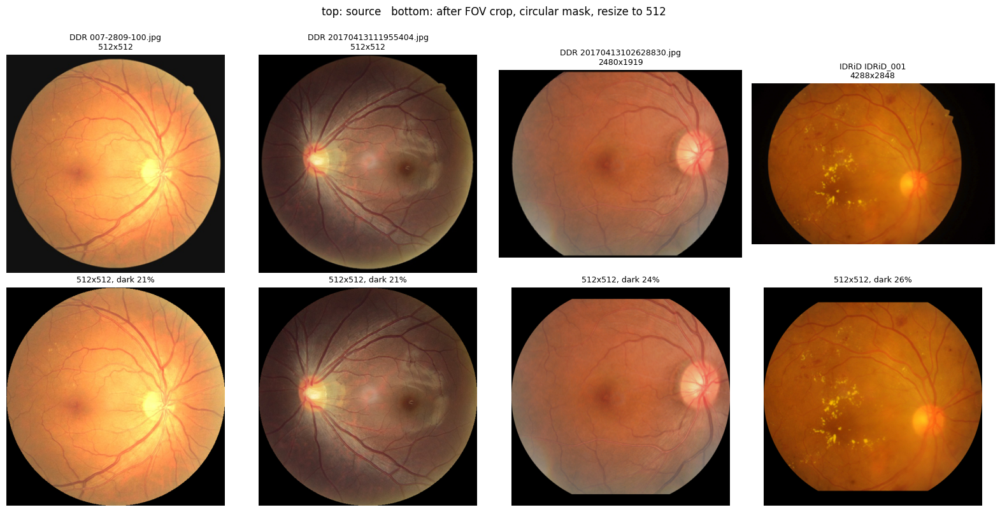

all preprocessing assertions passed


In [ ]:
# 2.3 Mask, square crop and resize as one resample
OUT_SIZE  = 512      
MASK_FRAC = 0.95    

def circ_mask(img):
    side = img.shape[0]
    yy, xx = np.ogrid[:side, :side]
    return (xx - side / 2) ** 2 + (yy - side / 2) ** 2 <= (side / 2) ** 2

def preprocess(path, out=OUT_SIZE, mask_frac=MASK_FRAC, f=None):
    im = cv2.imread(str(path))
    if im is None:
        return None
    f = f if f is not None else detect_fov(path)
    if f is None:
        return None

    r    = f['r'] * mask_frac
    side = int(round(2 * r))
    x0, y0 = int(round(f['cx'] - r)), int(round(f['cy'] - r))

    canvas = np.zeros((side, side, 3), np.uint8)
    sx0, sy0 = max(x0, 0), max(y0, 0)
    sx1, sy1 = min(x0 + side, im.shape[1]), min(y0 + side, im.shape[0])
    if sx1 <= sx0 or sy1 <= sy0:
        return None
    canvas[sy0 - y0:sy0 - y0 + (sy1 - sy0), sx0 - x0:sx0 - x0 + (sx1 - sx0)] = im[sy0:sy1, sx0:sx1]
    canvas[~circ_mask(canvas)] = 0

    interp = cv2.INTER_AREA if side > out else cv2.INTER_CUBIC   
    return cv2.resize(canvas, (out, out), interpolation=interp)

sq_ddr  = props[(props['w'] == 512) & (props['source'] == 'hyphen')]['id_code'].iloc[0]
nat_ddr = props[props['aspect'] > 1.2]['id_code'].iloc[0]
ts_ddr  = props[(props['source'] == 'timestamp') & (props['id_code'] != nat_ddr)]['id_code'].iloc[0]

checks = [('DDR', DDR_IMG, sq_ddr, ''), ('DDR', DDR_IMG, ts_ddr, ''),
          ('DDR', DDR_IMG, nat_ddr, ''), ('IDRiD', IDRID_IMG, iprops['id_code'].iloc[0], '.jpg')]
assert len({c[2] for c in checks}) == 4, 'duplicate image in checks'

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (ds, d, name, ext) in enumerate(checks):
    p = d / f'{name}{ext}'
    with Image.open(p) as im:
        axes[0, col].imshow(im.resize((320, int(320 * im.size[1] / im.size[0]))))
        axes[0, col].set_title(f'{ds} {name}\n{im.size[0]}x{im.size[1]}', fontsize=9)
    out = preprocess(p)
    axes[1, col].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'{out.shape[0]}x{out.shape[1]}, dark '
                           f'{(out.max(2) <= 12).mean():.0%}', fontsize=9)
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('top: source   bottom: after FOV crop, circular mask, resize to 512', y=1.0)
plt.tight_layout(); plt.show()

for ds, d, name, ext in checks:
    o = preprocess(d / f'{name}{ext}')
    assert o is not None,                      f'{name}: preprocessing returned None'
    assert o.shape == (OUT_SIZE, OUT_SIZE, 3), f'{name}: wrong shape {o.shape}'
    assert o.dtype == np.uint8,                f'{name}: wrong dtype {o.dtype}'
    assert o[:8, :8].max() <= 12,              f'{name}: corner not masked'
    assert (o.max(2) > 12).mean() > 0.5,       f'{name}: over half the output is black'
print('all preprocessing assertions passed')

**Result.** Dark fraction 21%, 21%, 24%, 26% across the four cases. A circle inscribed in a square
occupies `π/4 = 78.5%`, so ~21% dark is the correct floor; the higher figures are the letterboxed frames,
whose black bands add to it. All assertions pass.

In [ ]:
# 2.3.1 Confirming the notch is gone from the output
def unwrap_out(img, lo=0.80, hi=1.02, nr=70, na=720):
    c = img.shape[0] / 2
    rr = np.linspace(lo, hi, nr)[:, None] * c
    th = np.linspace(0, 2 * np.pi, na)[None, :]
    return cv2.remap(img, (c + rr * np.cos(th)).astype(np.float32),
                          (c + rr * np.sin(th)).astype(np.float32), cv2.INTER_LINEAR), rr[:, 0] / c

fig, axes = plt.subplots(len(checks), 1, figsize=(15, 9))
for ax, (ds, d, name, ext) in zip(axes, checks):
    o = preprocess(d / f'{name}{ext}')
    strip, radii = unwrap_out(o)
    ax.imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB), aspect='auto',
              extent=[0, 360, radii[-1], radii[0]])
    ax.axhline(1.0, color='yellow', lw=1.0)
    ax.set_ylabel(f'{ds}\nr fraction', fontsize=8)
axes[-1].set_xlabel('angle (degrees)', fontsize=8)
plt.suptitle('Output boundary unwrapped. yellow = mask edge; no bright column should cross it')
plt.tight_layout(); plt.show()

**Result. Clean.** No bright column crosses the mask edge in any of the four images, so the notch is gone.

The black domes at 90° and 270° are the flat top and bottom of wide images. They are the same size on both
sides, so the circle is centred correctly. The thin dark fringe in the square DDR images is the dim outer
rim, and the mask cuts at its outer edge, not into useful tissue.

/tmp/ipykernel_58/326460353.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=1))['id_code'].tolist())


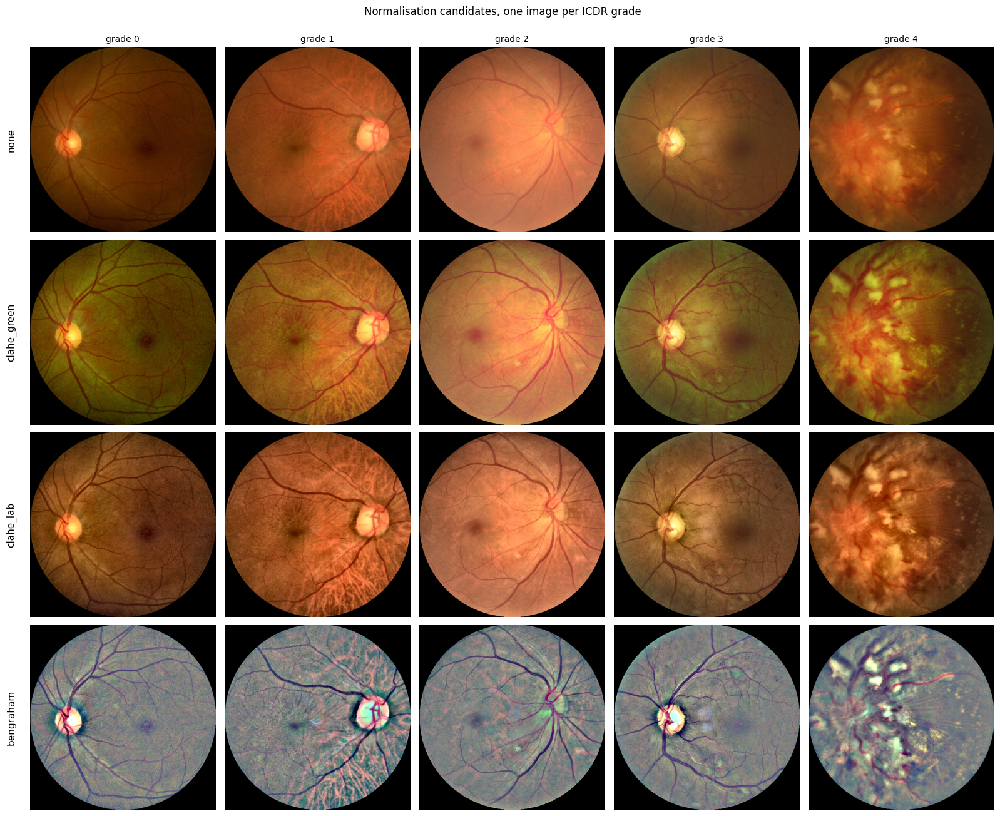

none         inner   51.0  rim   36.5  rim/inner 0.72
clahe_green  inner   73.2  rim   56.1  rim/inner 0.77
clahe_lab    inner   67.1  rim   51.0  rim/inner 0.76
bengraham    inner  128.1  rim  124.5  rim/inner 0.97
rim checks passed


In [ ]:
# 2.4 Normalisation candidates
def circ_mask(img):
    side = img.shape[0]
    yy, xx = np.ogrid[:side, :side]
    return (xx - side / 2) ** 2 + (yy - side / 2) ** 2 <= (side / 2) ** 2

def norm_none(img):
    return img

def norm_clahe_green(img, clip=2.0, tile=8):
    out = img.copy()
    cl = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    out[:, :, 1] = cl.apply(out[:, :, 1])
    out[~circ_mask(out)] = 0
    return out

def norm_clahe_lab(img, clip=2.0, tile=8):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(lab[:, :, 0])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    out[~circ_mask(out)] = 0
    return out

def norm_bengraham(img, sigma_frac=30, alpha=4, beta=-4, gamma=128):
    m     = circ_mask(img)
    mf    = m.astype(np.float32)
    sigma = img.shape[0] / sigma_frac
    num   = cv2.GaussianBlur(img.astype(np.float32) * mf[..., None], (0, 0), sigma)
    den   = cv2.GaussianBlur(mf, (0, 0), sigma)
    bg    = num / np.maximum(den, 1e-3)[..., None]

    out = np.clip(alpha * img.astype(np.float32) + beta * bg + gamma, 0, 255).astype(np.uint8)
    out[~m] = 0
    return out

NORMS = {'none': norm_none, 'clahe_green': norm_clahe_green,
         'clahe_lab': norm_clahe_lab, 'bengraham': norm_bengraham}

vis_ids = (props.groupby('diagnosis', group_keys=False)
                .apply(lambda g: g.sample(1, random_state=1))['id_code'].tolist())

fig, axes = plt.subplots(len(NORMS), 5, figsize=(16, 13))
for col, name in enumerate(vis_ids):
    base = preprocess(DDR_IMG / name)
    for row, (label, fn) in enumerate(NORMS.items()):
        axes[row, col].imshow(cv2.cvtColor(fn(base), cv2.COLOR_BGR2RGB))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'grade {int(props.loc[props.id_code == name, "diagnosis"].iloc[0])}',
                                     fontsize=10)
        if col == 0:
            axes[row, col].text(-0.1, 0.5, label, transform=axes[row, col].transAxes,
                                rotation=90, va='center', ha='center', fontsize=11)
plt.suptitle('Normalisation candidates, one image per ICDR grade', y=1.0)
plt.tight_layout(); plt.show()

c = OUT_SIZE / 2
yy, xx = np.ogrid[:OUT_SIZE, :OUT_SIZE]
rad = np.sqrt((xx - c) ** 2 + (yy - c) ** 2) / c
probe = preprocess(DDR_IMG / vis_ids[0])
m = circ_mask(probe)
for label, fn in NORMS.items():
    g = fn(probe)[:, :, 1].astype(np.float32)
    inner, rim = g[(rad < 0.70) & m].mean(), g[(rad > 0.90) & (rad < 0.99) & m].mean()
    print(f'{label:12s} inner {inner:6.1f}  rim {rim:6.1f}  rim/inner {rim / inner:.2f}')
    assert rim / inner < 1.15, f'{label}: bright boundary rim, background estimate is leaking surround'
print('rim checks passed')

**Result. The four methods do different jobs.**

Raw images are about 28% darker at the edge (vignetting). CLAHE barely changes this because it works in
small tiles. Only Ben Graham evens out the lighting across the whole image.

**CLAHE brings out small detail. Ben Graham removes uneven lighting.** This matters in 2.5, because the
brightness gap between the two DDR sources affects the whole image.

In [ ]:
# 2.5 Ablation - which variants go forward
ab_samp = (props.sample(frac=1, random_state=0)
                .groupby(['source', 'diagnosis'], group_keys=False).head(60))
print('sample sizes per cohort and grade:')
print(ab_samp.groupby(['source', 'diagnosis']).size().unstack().to_string())

ab_rows = []
for _, r in ab_samp.iterrows():
    base = preprocess(DDR_IMG / r['id_code'])
    if base is None:
        continue
    m = circ_mask(base)
    rec = {'source': r['source'], 'diagnosis': r['diagnosis']}
    for label, fn in NORMS.items():
        gch = fn(base)[:, :, 1].astype(np.float64)[m]     
        rec[f'{label}_Gstd'], rec[f'{label}_Gmean'] = gch.std(), gch.mean()
    ab_rows.append(rec)
ab = pd.DataFrame(ab_rows)

for label in NORMS:
    piv = ab.pivot_table(index='source', columns='diagnosis', values=f'{label}_Gstd')
    print(f'\n--- {label}: G_std by cohort and grade ---')
    print(piv.round(1).to_string())
    for coh, sub in ab.groupby('source'):
        rho = sub[['diagnosis', f'{label}_Gstd']].corr(method='spearman').iloc[0, 1]
        v = piv.loc[coh]
        lo, hi = v[[0, 1]].mean(), v[[3, 4]].mean()       
        print(f'    {coh:<10} spearman rho {rho:+.3f}   '
              f'g0-1 {lo:.1f} -> g3-4 {hi:.1f} ({(hi / lo - 1) * 100:+.0f}%)')

print('\n--- cohort separation ---')
print(f"{'variant':<12} {'Gmean gap':>10} {'Gstd gap':>9}")
for label in NORMS:
    mu = ab.groupby('source')[f'{label}_Gmean'].mean()
    sd = ab.groupby('source')[f'{label}_Gstd'].mean()
    print(f'  {label:<12} {abs(mu.diff().iloc[-1]) / mu["hyphen"] * 100:9.1f}% '
          f'{abs(sd.diff().iloc[-1]) / sd["hyphen"] * 100:8.1f}%')
print('\nnote: bengraham centres every image on gamma=128, so its Gmean gap is 0 by construction,'
      '\n      not by correction. Read its Gstd gap instead.')

**Result. Ben Graham is rejected, and no method removes the difference between the two DDR sources.**

| Variant | Brightness gap | Texture gap (`G_std`) | Colour |
|---|---:|---:|---|
| none | 10.7% | 1.8% | unchanged |
| clahe_green | 9.5% | 1.5% | distorted |
| **clahe_lab** | **9.0%** | 1.9% | unchanged |
| bengraham | 0.1% (by design) | **13.5%** | unchanged |

**Ben Graham makes things worse.** Its 0.1% brightness gap is not a real fix, because the method sets every
image to the same average brightness. On texture, the gap grows from 1.8% to 13.5%. The method boosts fine
detail by 4×, and hyphen images are blurrier than timestamp images (1.9), so it makes that difference
bigger.

**`G_std` does not rise with severity per image.** The correlation is close to zero (+0.042 hyphen,
+0.029 timestamp), so there is no signal for normalisation to destroy. 2.5.1 explains why.

**We carry `none` and `clahe_lab` forward** to section 4 and compare the two. `clahe_lab` has the smallest
brightness gap and keeps the colours, but 9.0% against 10.7% is a small gain. No method removes the
difference, because local contrast methods cannot fix a brightness offset across the whole image.

In [ ]:
# 2.5.1
c = OUT_SIZE / 2
yy, xx = np.ogrid[:OUT_SIZE, :OUT_SIZE]
radial = np.sqrt((xx - c) ** 2 + (yy - c) ** 2) / c

reg_rows = []
for _, r in ab_samp.iterrows():
    p = DDR_IMG / r['id_code']
    rec = {'source': r['source'], 'diagnosis': r['diagnosis']}

    s = retina_stats(p)                      
    if s is None:
        continue
    rec['raw_thumb'] = s['G_std']

    base = preprocess(p)
    if base is None:
        continue
    g = base[:, :, 1].astype(np.float64)
    rec['masked_disc'] = g[circ_mask(base)].std()         
    rec['inner_70']    = g[radial < 0.70].std()           
    rec['rim_70_95']   = g[(radial >= 0.70) & circ_mask(base)].std()
    reg_rows.append(rec)
reg = pd.DataFrame(reg_rows)

REGIONS = ['raw_thumb', 'masked_disc', 'inner_70', 'rim_70_95']
for region in REGIONS:
    print(f'\n--- {region} ---')
    print(reg.pivot_table(index='source', columns='diagnosis', values=region).round(1).to_string())
    for coh, sub in reg.groupby('source'):
        rho = sub[['diagnosis', region]].corr(method='spearman').iloc[0, 1]
        print(f'    {coh:<10} spearman rho {rho:+.3f}')

print('\n--- severity correlation, all regions side by side ---')
print(reg.groupby('source').apply(
    lambda s: pd.Series({r: s[['diagnosis', r]].corr(method='spearman').iloc[0, 1]
                         for r in REGIONS}), include_groups=False).round(3).to_string())

**Result. There was never a signal per image.**

| Region | hyphen rho | timestamp rho |
|---|---:|---:|
| raw_thumb (same as 1.7) | +0.086 | +0.088 |
| masked_disc | +0.042 | +0.029 |
| inner_70 | −0.001 | +0.069 |
| rim_70_95 | +0.085 | −0.053 |

Every value is close to zero, even for `raw_thumb`, which repeats the exact measurement from 1.7. So the
mask did not remove the signal, and it is not hiding in the rim.

1.7 found a difference between **group averages** (hyphen 24.2 → 27.7). The averages do rise with grade, but
individual images vary too much within each grade, so one image's `G_std` does not tell you its grade. A
CNN looks at one image at a time, so it cannot use a pattern that only shows in the average of 60 images.

**What changes.** The normalisation test was first justified as "`G_std` is a real severity signal that
normalisation could destroy". That reason is dropped. The test stays for a new reason: no method removes
the difference between the two DDR sources, so both `none` and `clahe_lab` must be tested.

In [27]:
# 2.6 Batch run and Local cache
import zipfile, time, json, multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

PROC     = WORK / 'processed'
ARCHIVE  = WORK / 'processed_512.zip'
MANIFEST = PROC / 'manifest.json'
SPEC     = {'out_size': OUT_SIZE, 'mask_frac': MASK_FRAC,
            'n_ddr': len(props), 'n_idrid': len(iprops)}

for sub in ('ddr', 'idrid'):
    (PROC / sub).mkdir(parents=True, exist_ok=True)

have = json.loads(MANIFEST.read_text()) if MANIFEST.exists() else {}

if have and have != SPEC:
    raise RuntimeError(
        f'cache was built with {have}, current settings are {SPEC}. '
        f'Delete {PROC} and {ARCHIVE} to rebuild.'
    )

def process_one(args):
    src_path, dst_path = args
    dst = pathlib.Path(dst_path)
    if dst.exists():
        return 'skip'
    out = preprocess(pathlib.Path(src_path))
    if out is None:
        return 'fail'
    ok = cv2.imwrite(str(dst), out, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return 'ok' if ok else 'fail'

jobs  = [(str(DDR_IMG / n), str(PROC / 'ddr' / n)) for n in props['id_code']]
jobs += [(str(IDRID_IMG / f'{n}.jpg'), str(PROC / 'idrid' / f'{n}.jpg')) for n in iprops['id_code']]

NW = max(2, os.cpu_count() or 2)
print(f'images: {len(jobs)} | workers: {NW}')

t0, counts = time.time(), {'ok': 0, 'skip': 0, 'fail': 0}
with ProcessPoolExecutor(max_workers=NW, mp_context=mp.get_context('fork')) as ex:
    for k, res in enumerate(ex.map(process_one, jobs, chunksize=32), 1):
        counts[res] += 1
        if k % 2000 == 0:
            print(f'  {k}/{len(jobs)}  {time.time() - t0:.0f}s  {counts}')

print(f'done in {time.time() - t0:.0f}s -> {counts}')
assert counts['fail'] == 0, f"{counts['fail']} images failed - inspect before caching"
MANIFEST.write_text(json.dumps(SPEC))

expected = len(jobs) + 1

def zip_ok(p):
    if not p.exists():
        return False
    try:
        with zipfile.ZipFile(p) as z:
            return len(z.namelist()) == expected and z.testzip() is None
    except zipfile.BadZipFile:
        return False

if not zip_ok(ARCHIVE):
    ARCHIVE.unlink(missing_ok=True)
    tmp = ARCHIVE.with_suffix('.part')
    with zipfile.ZipFile(tmp, 'w', zipfile.ZIP_STORED) as z:
        for p in sorted(PROC.rglob('*')):
            if p.is_file():
                z.write(p, p.relative_to(PROC))
    tmp.rename(ARCHIVE)

assert zip_ok(ARCHIVE), 'archive incomplete'
print('archive: %.2f GB, %d members' % (ARCHIVE.stat().st_size / 1e9, expected))
print('saved to:', ARCHIVE)


images: 12977 | workers: 4
  2000/12977  28s  {'ok': 2000, 'skip': 0, 'fail': 0}
  4000/12977  77s  {'ok': 4000, 'skip': 0, 'fail': 0}
  6000/12977  122s  {'ok': 6000, 'skip': 0, 'fail': 0}


Corrupt JPEG data: 35 extraneous bytes before marker 0xd9
Corrupt JPEG data: 35 extraneous bytes before marker 0xd9


  8000/12977  155s  {'ok': 8000, 'skip': 0, 'fail': 0}
  10000/12977  190s  {'ok': 10000, 'skip': 0, 'fail': 0}


Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9


  12000/12977  222s  {'ok': 12000, 'skip': 0, 'fail': 0}
done in 310s -> {'ok': 12977, 'skip': 0, 'fail': 0}
archive: 0.80 GB, 12978 members
saved to: /kaggle/working/processed_512.zip


**Artefact 2**
Processed imageset 512px - /kaggle/working/processed_512.zip

In [ ]:
# 2.7 Verify the processed set
ddr_out   = sorted((PROC / 'ddr').glob('*.jpg'))
idrid_out = sorted((PROC / 'idrid').glob('*.jpg'))
print('ddr  :', len(ddr_out),   'expected', len(props))
print('idrid:', len(idrid_out), 'expected', len(iprops))
assert len(ddr_out) == len(props) and len(idrid_out) == len(iprops), 'count mismatch'
assert json.loads(MANIFEST.read_text()) == SPEC, 'cache parameters do not match current settings'

missing = set(props['id_code']) - {p.name for p in ddr_out}
assert not missing, f'{len(missing)} labelled images have no processed file: {list(missing)[:5]}'

empty = [p.name for p in ddr_out + idrid_out if p.stat().st_size < 1024]
assert not empty, f'{len(empty)} suspiciously small files: {empty[:5]}'

shapes, darks, bad = [], [], []
for p in ddr_out[::200] + idrid_out[::20]:
    a = cv2.imread(str(p))
    if a is None:
        bad.append(p.name); continue
    shapes.append(a.shape)
    darks.append((a.max(2) <= 12).mean())
assert not bad, f'unreadable files: {bad[:5]}'

print('\nsampled:', len(shapes), '| shapes:', set(shapes))
print('dark fraction  min %.2f  mean %.2f  max %.2f  (pi/4 mask implies ~0.21)'
      % (min(darks), float(np.mean(darks)), max(darks)))
assert set(shapes) == {(OUT_SIZE, OUT_SIZE, 3)}, 'inconsistent output shape'
assert max(darks) < 0.45, 'some outputs excessively dark - check the FOV radius'
print('\nverification passed')

ddr  : 12522 expected 12522
idrid: 455 expected 455

sampled: 86 | shapes: {(512, 512, 3)}
dark fraction  min 0.21  mean 0.23  max 0.29  (pi/4 mask implies ~0.21)

verification passed


## 2.8 Section 2: Decisions

| Decision | Setting | Reason |
|---|---|---|
| Find the retina area separately for each image | threshold 12, 5×5 opening, largest outer outline | DDR `fov_w` is 1.0 but IDRiD is 0.8. Camera notches must not stretch the edge (2.1) |
| Circular mask | **`MASK_FRAC = 0.95`** | The notch reaches about 0.985, so 0.98 would keep it (2.2.2) |
| Make the image square by adding black padding, not stretching | black canvas, image centred | Keeps the retina's shape across image shapes from 1.00 to 1.51 (2.3) |
| Resize only once, to 512 | `INTER_AREA` to shrink, `INTER_CUBIC` to enlarge | Resizing several times blurs lesions that are only 1-6 px wide (2.3) |
| Normalisation | **`none` and `clahe_lab`, two versions** | No method removes the gap between the two DDR sources: 9.0% vs 10.7% (2.5) |
| **Ben Graham rejected** | n/a | It raises the texture gap from 1.8% to 13.5%. Its 0.1% brightness gap is by design (2.5) |
| Leave model input size open | resize when loading | Lets section 5 test 224, 380 and 512 without rebuilding the cache |
| Save everything as one archive | JPEG quality 95, no extra compression, checked by a manifest | Many small files are slow on Disk. Archive is 0.80 GB, against about 10 GB for the originals (2.6) |

**Deliberately not used**

- **Denoising:** the blurry images came from resizing, not bad focus (1.9).
- **Sharpening:** it would boost tiny pixel-level noise, and nothing we measured supports it.

**Changed during this section**

- The idea that `G_std` rises with severity failed the per-image test (2.5.1). So the original reason for
  testing normalisation was dropped and replaced.
- 2.2.1 pointed to `MASK_FRAC = 0.98`, but 2.2.2 overturned it. Averaging the whole ring hid a defect at
  one angle.

**New limitation for the report**

- IDRiD's retina fills about 423 of 512 rows, against about 499 for DDR. So IDRiD images have about 15%
  less detail than the training data, on top of the colour difference.

---
# 3. Data Augmentation and Balancing

### What this section does, and why each step

| Step | Operation | Driven by |
|---|---|---|
| 3.1 | Split into train/val/test - kept group-aware, and stratified by class and cohort | 30 near-duplicate groups (1.16); cohort predicts grade for the thin classes (1.4) |
| 3.2 | Handle the imbalance - class weighting, with resampling tried alongside it and the two compared on numbers | 26.6 : 1 across Mild 630, Severe 236, PDR 913 (1.2) |
| 3.3 | Geometric augmentation - flips and small rotations, with the fine detail they cost measured rather than assumed | a microaneurysm is 1-6 px at 512, so interpolation can erase one (2.0) |
| 3.4 | Photometric jitter - brightness and colour shifts sized to the gaps already measured, not to a default | 12% cohort brightness gap (1.6); IDRiD blue 40% below both cohorts (1.13) |
| 3.5 | `tf.data` input pipeline, augmenting on the fly rather than writing to disk | the one 512 cache has to serve both `none` and `clahe_lab` arms (2.5) |
| 3.6 | Throughput check - how many images per second the pipeline delivers | CLAHE runs per image per epoch, so it must not leave the GPU waiting |

In [28]:
# 3.1 Splitting: group-aware and doubly stratified
from sklearn.model_selection import StratifiedGroupKFold

SEED       = 42
SPLIT_SPEC = {'seed': SEED, 'outer_folds': 7, 'inner_folds': 6,
              'strata': 'diagnosis x cohort', 'groups': 'ddr_dup_groups.csv'}

DUP_LOCAL   = WORK / 'ddr_dup_groups.csv'
SPLIT_LOCAL = CACHE / 'ddr_splits.csv'
SPLIT_MAN   = CACHE / 'ddr_splits_manifest.json'

if not DUP_LOCAL.exists():
    raise RuntimeError('ddr_dup_groups.csv not found. Run sections 1.16-1.19 first.')

dup  = pd.read_csv(DUP_LOCAL)
base = props[['id_code', 'diagnosis', 'source']].merge(
    dup[['id_code', 'group']], on='id_code', how='left'
)
assert base['group'].notna().all(), 'every DDR image must carry a group id'
base['stratum'] = base['diagnosis'].astype(str) + '-' + base['source']

def hold_out_one_fold(frame, n_splits):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    keep, hold = next(iter(sgkf.split(frame, frame['stratum'], frame['group'])))
    return frame.iloc[keep].copy(), frame.iloc[hold].copy()

if SPLIT_LOCAL.exists() and SPLIT_MAN.exists() and json.loads(SPLIT_MAN.read_text()) == SPLIT_SPEC:
    splits = pd.read_csv(SPLIT_LOCAL)
    assert set(splits['id_code']) == set(base['id_code']), 'cached split does not cover this dataset'
    print('split loaded from Kaggle working cache')
else:
    trainval, test = hold_out_one_fold(base, SPLIT_SPEC['outer_folds'])
    train, val     = hold_out_one_fold(trainval, SPLIT_SPEC['inner_folds'])
    splits = base.assign(split=np.select(
        [base['id_code'].isin(train['id_code']), base['id_code'].isin(val['id_code'])],
        ['train', 'val'], default='test'))
    splits.to_csv(SPLIT_LOCAL, index=False)
    SPLIT_MAN.write_text(json.dumps(SPLIT_SPEC))
    print('split built and cached in /kaggle/working')

splits.to_csv(SPLIT_LOCAL, index=False)

per_group = splits.groupby('group')['split'].nunique()
assert (per_group == 1).all(), f'{(per_group > 1).sum()} groups leak across splits'
assert len(splits) == len(props) and splits['id_code'].duplicated().sum() == 0

iext = iprops[['id_code', 'diagnosis']].assign(source='idrid', group=-1, split='external')

print('\nsplit sizes:')
sz = splits['split'].value_counts()
print(pd.DataFrame({'images': sz, 'percent': (sz / len(splits) * 100).round(1)}).to_string())

print('\nclass counts per split (DDR) and the external set:')
tab = pd.crosstab(splits['diagnosis'], splits['split'])
tab['external'] = iext['diagnosis'].value_counts()
tab.index = [LABELS[i] for i in tab.index]
print(tab.loc[:, ['train', 'val', 'test', 'external']].fillna(0).astype(int).to_string())

print('\nclass percentage per split - stratification check:')
print((pd.crosstab(splits['diagnosis'], splits['split'], normalize='columns') * 100).round(2)
      .rename(index=LABELS).to_string())

print('\ncohort share within each class and split (%):')
coh = (splits.groupby(['diagnosis', 'split'])['source']
             .apply(lambda s: 100 * (s == 'hyphen').mean()).unstack().round(1))
print(coh.rename(index=LABELS).to_string())

print('\nsmallest class in each split:', tab[['train', 'val', 'test']].min().to_dict())


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=6.
  warnings.warn(


split built and cached in /kaggle/working

split sizes:
       images  percent
split                 
train    8944     71.4
val      1792     14.3
test     1786     14.3

class counts per split (DDR) and the external set:
split             train  val  test  external
No_DR              4474  899   893       118
Mild                454   88    88        23
Moderate           3197  640   640       164
Severe              167   36    33        90
Proliferative_DR    652  129   132        60

class percentage per split - stratification check:
split              test  train    val
diagnosis                            
No_DR             50.00  50.02  50.17
Mild               4.93   5.08   4.91
Moderate          35.83  35.74  35.71
Severe             1.85   1.87   2.01
Proliferative_DR   7.39   7.29   7.20

cohort share within each class and split (%):
split              test  train    val
diagnosis                            
No_DR              29.9   30.0   29.8
Mild               94.3   94

**Result - all three constraints hold.**

8,944 train / 1,792 val / 1,786 test (71.4 / 14.3 / 14.3). IDRiD's 455 stay external.

**Class balance:** within 0.2 points across splits in every class (No_DR 50.02 / 50.17 / 50.00, Severe
1.87 / 2.01 / 1.85). Keeping duplicate groups together cost nothing - they are only 0.52% of the data.

**Cohort balance - the check that mattered.** Hyphen predicts grade, so an enriched split would fake a
performance difference. Hyphen share per class is flat: Mild 94.9 / 94.3 / 94.3, PDR 99.8 / 100.0 / 100.0.
Severe's 82.0 / 86.1 / 81.8 spread is one image - val holds 36 Severe cases, so 1/36 = 2.8 points each.

**Why IDRiD is needed.** Internal test has 33 Severe images, so one error moves recall by 1/33 = 3.0
points. IDRiD brings 90, nearly triple. Severe recall is indicative internally, measurable only externally.
**Artefact 3** `CACHE/ddr_splits.csv` with `ddr_splits_manifest.json`.

In [ ]:
# 3.2 Class imbalance: weighting compared against resampling
tr = splits[splits['split'] == 'train']
n  = tr['diagnosis'].value_counts().sort_index().astype(float)   
K, N = len(n), n.sum()

def share(w):                       
    return (w * n) / (w * n).sum()

schemes = {}
schemes['none']         = pd.Series(1.0, index=n.index)
schemes['inverse']      = N / (K * n)                           
schemes['sqrt_inverse'] = np.sqrt(N / n); schemes['sqrt_inverse'] /= schemes['sqrt_inverse'].mean()
for beta in (0.99, 0.999, 0.9999):                               
    eff = (1 - beta ** n) / (1 - beta)
    w = (1 / eff); w = w / w.mean()
    schemes[f'effnum_b{beta}'] = w

tblw = pd.DataFrame({k: v.round(2) for k, v in schemes.items()})
tblw.insert(0, 'train_n', n.astype(int))
tblw.index = [LABELS[i] for i in tblw.index]
print('per-class weight under each scheme (normalised to mean 1 except `inverse`):')
print(tblw.to_string())

print('\nloss share per class (%) - what the network actually optimises:')
shr = pd.DataFrame({k: (share(v) * 100).round(1) for k, v in schemes.items()})
shr.index = [LABELS[i] for i in shr.index]
print(shr.to_string())

print('\nweight spread (max:min) per scheme:')
print({k: round(float(v.max() / v.min()), 1) for k, v in schemes.items()})

rep = (n.max() / n).round(1)
print('\nfull oversampling would repeat each class per epoch:', {LABELS[i]: rep[i] for i in rep.index})
print('epoch length would grow from %d to %d images (%.1fx)' % (N, K * n.max(), K * n.max() / N))
print('distinct Severe images available to repeat:', int(n.get(3, 0)))

CLASS_WEIGHT_SCHEME = 'effnum_b0.999'
CLASS_WEIGHT = {int(k): float(v) for k, v in schemes[CLASS_WEIGHT_SCHEME].items()}
json.dump(CLASS_WEIGHT, open(WORK / 'class_weight.json', 'w'))
print('\nchosen:', CLASS_WEIGHT_SCHEME, '->', {LABELS[k]: round(v, 2) for k, v in CLASS_WEIGHT.items()})

per-class weight under each scheme (normalised to mean 1 except `inverse`):
                  train_n  none  inverse  sqrt_inverse  effnum_b0.99  effnum_b0.999  effnum_b0.9999
No_DR                4474   1.0     0.40          0.38          0.95           0.38            0.13
Mild                  454   1.0     3.94          1.20          0.96           1.02            1.07
Moderate             3197   1.0     0.56          0.45          0.95           0.39            0.17
Severe                167   1.0    10.71          1.97          1.17           2.43            2.87
Proliferative_DR      652   1.0     2.74          1.00          0.96           0.78            0.75

loss share per class (%) - what the network actually optimises:
                  none  inverse  sqrt_inverse  effnum_b0.99  effnum_b0.999  effnum_b0.9999
No_DR             50.0     20.0          36.5          49.8           39.2            22.7
Mild               5.1     20.0          11.6           5.1           10.8   

**Result - beta is a dial, and 0.999 is the usable middle.**

Train counts: 4,474 / 454 / 3,197 / 167 / 652, raw imbalance **26.8 : 1**.

**Both endpoints fail.** `beta = 0.99` saturates at `1/(1 − 0.99) = 100` images, and every class has more
than that, so all five look equally well-supplied - spread 1.2 : 1, Severe at 2.3%, no different from no
weighting. `beta = 0.9999` gives spread 21.8 : 1, close to plain inverse at 26.8. 

**Beta must match the dataset size**

**Chosen: `effnum_b0.999`** - weights 0.38 / 1.02 / 0.39 / 2.43 / 0.78, spread **6.4 : 1**.

| Scheme | Spread | Severe loss share |
|---|---:|---:|
| `none` | 1.0 | 1.9% |
| `inverse` | 26.8 | 20.0% |
| `sqrt_inverse` | 5.2 | 7.1% |
| `effnum_b0.999` | 6.4 | 9.4% |

`inverse` is rejected: 167 images cannot carry a fifth of the objective without the model memorising them.
Against `sqrt_inverse` the spread is near-identical, but sqrt weights PDR and Mild almost equally
(1.00, 1.20) despite PDR having 1.4× the images, while effective-number separates them (0.78, 1.02).
Severe rises 1.9% → **9.4%**, with no class above 40%.

**Why not resampling.** Severe would repeat **26.8× per epoch** from **167 distinct images**, and the epoch
would grow 8,944 → 22,370 (2.5× cost). Fresh augmentation each repeat, but the same 167 retinas - the risk
is memorising them. It also shifts batch-norm statistics, confounding any comparison against the weighted
arm. Kept as `balanced=True` in 3.5 for the 5.0 ablation.

**Weights come from the training split only**, so test composition never enters the objective.

metric floor from 4 lossless orientations: [393.9, 451.1, 503.6, 446.9]  spread 24.4% of the mean
-> differences smaller than ~24% in the table below are not interpretable

fine-detail retention at IMG_SIZE=380, rotation 33.0 deg, mean of 60 images

                        variant  size  r_meas  lap_var  dark  ms/img  detail kept vs resize-only within metric floor
              source 512, no op   512     1.0    445.5 0.216    0.00                       113.1                 yes
             resize only (AREA)   380     1.0    393.9 0.220    3.28                       100.0                 yes
              rot90 then resize   380     1.0    451.1 0.220    5.33                       114.5                 yes
               one warp, LINEAR   380     1.0    374.1 0.220    2.90                        95.0                 yes
                one warp, CUBIC   380     1.0    563.5 0.220    4.38                       143.1                  NO
two step (512 CUBIC, then AREA)   380     1.0   

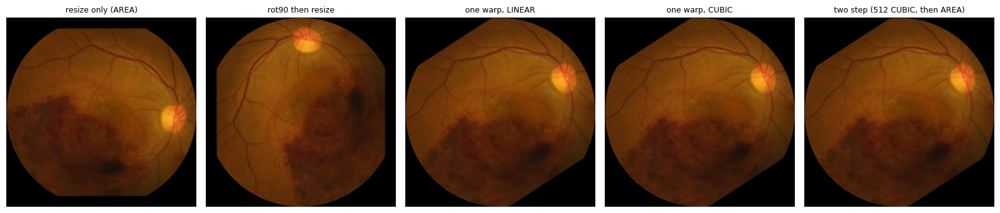

In [ ]:
# 3.3 Geometric augmentation, with its cost measured
IMG_SIZE = 380      

def geom(img, angle=0.0, scale=1.0, hflip=False, vflip=False, out=IMG_SIZE, interp=cv2.INTER_LINEAR):
    if hflip:
        img = img[:, ::-1]
    if vflip:
        img = img[::-1]
    src = img.shape[0]
    k   = (out / src) * scale
    M   = cv2.getRotationMatrix2D((src / 2, src / 2), angle, k)
    M[0, 2] += out / 2 - src / 2                 
    M[1, 2] += out / 2 - src / 2
    o = cv2.warpAffine(np.ascontiguousarray(img), M, (out, out), flags=interp, borderValue=(0, 0, 0))
    o[~circ_mask(o)] = 0                         
    return o

def disc_mask(side, rfrac=1.0, erode=7):
    yy, xx = np.ogrid[:side, :side]
    m = ((xx - side / 2) ** 2 + (yy - side / 2) ** 2 <= (side / 2 * rfrac) ** 2).astype(np.uint8)
    return cv2.erode(m, np.ones((erode, erode), np.uint8)) == 1

def lap_var(img, rfrac=1.0):
    m = disc_mask(img.shape[0], rfrac)
    g = cv2.Laplacian(img[:, :, 1].astype(np.float32), cv2.CV_32F, ksize=3)
    return float(g[m].var())

def dark_frac(img):
    return float((img.max(2) <= 12).mean())

M_SAMPLE = 60
samp_ids = (splits[splits['split'] == 'train']
            .sample(M_SAMPLE, random_state=SEED)['id_code'].tolist())
imgs = [cv2.imread(str(PROC / 'ddr' / n)) for n in samp_ids]
assert all(i is not None and i.shape[0] == OUT_SIZE for i in imgs), 'processed cache not loaded'

orient = [np.mean([lap_var(geom(np.rot90(im, k), 0, 1.0, interp=cv2.INTER_AREA)) for im in imgs])
          for k in range(4)]
floor_pct = 100 * (max(orient) - min(orient)) / np.mean(orient)
print('metric floor from 4 lossless orientations: %s  spread %.1f%% of the mean'
      % (np.round(orient, 1).tolist(), floor_pct))
print('-> differences smaller than ~%.0f%% in the table below are not interpretable\n' % floor_pct)

ANG = 33.0                                      
variants = {
    'source 512, no op':      (lambda im: im, 1.0),
    'resize only (AREA)':     (lambda im: geom(im, 0,   1.0, interp=cv2.INTER_AREA), 1.0),
    'rot90 then resize':      (lambda im: geom(np.rot90(im), 0, 1.0, interp=cv2.INTER_AREA), 1.0),
    'one warp, LINEAR':       (lambda im: geom(im, ANG, 1.0, interp=cv2.INTER_LINEAR), 1.0),
    'one warp, CUBIC':        (lambda im: geom(im, ANG, 1.0, interp=cv2.INTER_CUBIC), 1.0),
    'two step (512 CUBIC, then AREA)':
        (lambda im: geom(cv2.warpAffine(im, cv2.getRotationMatrix2D((256, 256), ANG, 1.0), (512, 512),
                                        flags=cv2.INTER_CUBIC), 0, 1.0, interp=cv2.INTER_AREA), 1.0),
    'one warp, zoom 1.10':    (lambda im: geom(im, ANG, 1.10, interp=cv2.INTER_LINEAR), 1.0),
    'one warp, zoom 0.90':    (lambda im: geom(im, ANG, 0.90, interp=cv2.INTER_LINEAR), 0.90),
    'hflip only':             (lambda im: geom(im, 0, 1.0, hflip=True, interp=cv2.INTER_AREA), 1.0),
}

rows = []
for label, (fn, rfrac) in variants.items():
    t0 = time.time()
    outs = [fn(im) for im in imgs]
    ms = (time.time() - t0) / len(imgs) * 1000
    rows.append({'variant': label, 'size': outs[0].shape[0], 'r_meas': rfrac,
                 'lap_var': np.mean([lap_var(o, rfrac) for o in outs]),
                 'dark': np.mean([dark_frac(o) for o in outs]),
                 'ms/img': round(ms, 2)})

geo = pd.DataFrame(rows)
ref = geo.loc[geo['variant'] == 'resize only (AREA)', 'lap_var'].iloc[0]
geo['detail kept vs resize-only'] = (geo['lap_var'] / ref * 100).round(1)
geo['within metric floor'] = np.where(
    (geo['detail kept vs resize-only'] - 100).abs() <= floor_pct, 'yes', 'NO')
geo['lap_var'] = geo['lap_var'].round(1); geo['dark'] = geo['dark'].round(3)
print(f'fine-detail retention at IMG_SIZE={IMG_SIZE}, rotation {ANG} deg, mean of {M_SAMPLE} images\n')
print(geo.to_string(index=False))

for label, (fn, _) in variants.items():
    if label == 'source 512, no op':
        continue
    o = fn(imgs[0])
    assert o.shape == (IMG_SIZE, IMG_SIZE, 3), f'{label}: wrong output shape {o.shape}'
    assert o[:6, :6].max() <= 12 and o[-6:, -6:].max() <= 12, f'{label}: corner not black'
    assert 0.15 < dark_frac(o) < 0.45, f'{label}: dark fraction {dark_frac(o):.3f} off the pi/4 floor'
print('\nmask integrity assertions passed for every variant')

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, (label, (fn, _)) in zip(axes, list(variants.items())[1:6]):
    ax.imshow(cv2.cvtColor(fn(imgs[0]), cv2.COLOR_BGR2RGB)); ax.set_title(label, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

**Result. Rotation is affordable, and the measure's noise level is the main finding.**

Rotating by exactly 90° loses no detail, yet its scores spread by **24.4%** (393.9 to 503.6). So any
difference under about 24% in the table cannot be trusted.

**Decision: `INTER_LINEAR`, single warp.** LINEAR (95.0%) and the two-step method (93.2%) are both inside
this noise level, so the test cannot tell them apart. The two-step method takes 2.2× longer (6.47 vs
2.90 ms), so we use the cheaper one.

**Operations selected for the pipeline:**
- Rotate by a random angle from 0° to 360°
- Zoom by a random amount from 0.90 to 1.10
- Flip left to right, with a 50% chance
- Flip top to bottom, with a 50% chance
- Do the rotation, zoom and resize in one step using `INTER_LINEAR`
- Re-apply the circle mask after each change, so the retina stays a clean circle on black

retina means (B, G, R) measured on the PROCESSED cache, not on raw images:
                  B     G      R
DDR hyphen     37.5  81.9  135.3
DDR timestamp  39.0  84.5  148.7
IDRiD          21.9  74.7  155.9

cohort separability per statistic (0.5 = carries no cohort information):
statistic  hyphen  timestamp  gap %  cohort AUC   IDRiD  DDR vs IDRiD AUC
        B  37.453     39.050  4.264       0.520  21.930             0.308
        G  81.898     84.532  3.217       0.519  74.716             0.432
        R 135.295    148.656  9.876       0.586 155.858             0.648
luminance  92.797     98.520  6.168       0.540  92.960             0.497
      R/G   1.789      1.811  1.257       0.597   2.152             0.787
      B/G   0.423      0.443  4.870       0.509   0.278             0.306

most cohort-separable statistic: R/G  (AUC 0.597)

brightness jitter sweep (whole-image gain exp(U(-a, a)), 8 draws per image):
  note: a whole-image gain cancels in any channel ratio, so it can only 

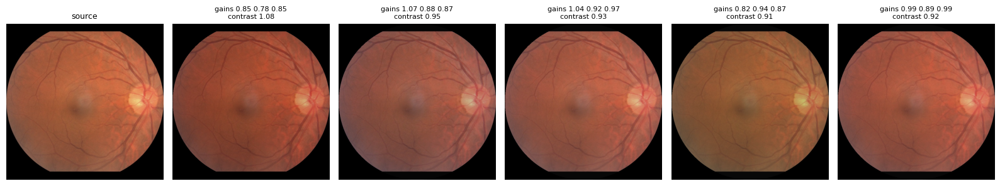

In [ ]:
# 3.4 Photometric jitter sized from the measured confounds
# Decide how much random brightness, colour and contrast change to add to training images, based on measurements of how the datasets differ.
def retina_means(path):
    im = cv2.imread(str(path))
    if im is None:
        return None
    m = cv2.erode(circ_mask(im).astype(np.uint8), np.ones((9, 9), np.uint8)) == 1
    return im[m].mean(0)                               

def auc_separable(a, b):
    ra = pd.Series(np.concatenate([a, b])).rank().values
    na = len(a)
    return float((ra[na:].sum() - len(b) * (len(b) + 1) / 2) / (na * len(b)))

def stat_table(M):
    B, G, R = M[:, 0], M[:, 1], M[:, 2]
    return {'B': B, 'G': G, 'R': R,
            'luminance': 0.114 * B + 0.587 * G + 0.299 * R,
            'R/G': R / G, 'B/G': B / G}

NS = 250
trs = splits[splits['split'] == 'train']
hy_ids = trs[trs['source'] == 'hyphen'   ]['id_code'].sample(min(NS, (trs['source'] == 'hyphen').sum()),    random_state=SEED)
ts_ids = trs[trs['source'] == 'timestamp']['id_code'].sample(min(NS, (trs['source'] == 'timestamp').sum()), random_state=SEED)
id_ids = iext['id_code'].sample(min(NS, len(iext)), random_state=SEED)

HY = np.array([retina_means(PROC / 'ddr'   / n)          for n in hy_ids])
TS = np.array([retina_means(PROC / 'ddr'   / n)          for n in ts_ids])
ID = np.array([retina_means(PROC / 'idrid' / f'{n}.jpg') for n in id_ids])
print('retina means (B, G, R) measured on the PROCESSED cache, not on raw images:')
print(pd.DataFrame([HY.mean(0), TS.mean(0), ID.mean(0)], index=['DDR hyphen', 'DDR timestamp', 'IDRiD'],
                   columns=['B', 'G', 'R']).round(1).to_string())

sh, st, si = stat_table(HY), stat_table(TS), stat_table(ID)
diag = pd.DataFrame([{'statistic': k,
                      'hyphen': np.mean(sh[k]), 'timestamp': np.mean(st[k]),
                      'gap %': 100 * abs(np.mean(st[k]) - np.mean(sh[k])) / np.mean(sh[k]),
                      'cohort AUC': auc_separable(sh[k], st[k]),
                      'IDRiD': np.mean(si[k]),
                      'DDR vs IDRiD AUC': auc_separable(np.concatenate([sh[k], st[k]]), si[k])}
                     for k in sh]).round(3)
print('\ncohort separability per statistic (0.5 = carries no cohort information):')
print(diag.to_string(index=False))

CUE = diag.loc[(diag['cohort AUC'] - 0.5).abs().idxmax(), 'statistic']
print(f"\nmost cohort-separable statistic: {CUE}  (AUC "
      f"{diag.loc[diag['statistic'] == CUE, 'cohort AUC'].iloc[0]:.3f})")

rg = np.random.default_rng(SEED)
print('\nbrightness jitter sweep (whole-image gain exp(U(-a, a)), 8 draws per image):')
print('  note: a whole-image gain cancels in any channel ratio, so it can only move B, G, R, luminance')
for a in (0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30):
    row = {}
    for k in ('B', 'G', 'R', 'luminance'):
        ha = (sh[k][:, None] * np.exp(rg.uniform(-a, a, (len(HY), 8)))).ravel()
        ta = (st[k][:, None] * np.exp(rg.uniform(-a, a, (len(TS), 8)))).ravel()
        row[k] = round(auc_separable(ha, ta), 3)
    print(f'  a={a:.2f}  ' + '  '.join(f'{k} {v:.3f}' for k, v in row.items()))

print('\ncolour jitter sweep, blue gain exp(U(-c, c)), measured as DDR-vs-IDRiD AUC on B/G:')
print('  gain needed to centre DDR on IDRiD: %.2f (a %.0f%% shift, not a spread)'
      % (np.median(si['B/G']) / np.median(np.concatenate([sh['B/G'], st['B/G']])),
         100 * (1 - np.median(si['B/G']) / np.median(np.concatenate([sh['B/G'], st['B/G']])))))
bg_ddr = np.concatenate([sh['B/G'], st['B/G']])
for c in (0.0, 0.10, 0.20, 0.30, 0.40, 0.50):
    aug = (bg_ddr[:, None] * np.exp(rg.uniform(-c, c, (len(bg_ddr), 8)))).ravel()
    print(f'  c={c:.2f}  AUC {auc_separable(aug, si["B/G"]):.3f}  '
          f'median aug {np.median(aug):.3f} vs IDRiD {np.median(si["B/G"]):.3f}')

BRIGHT_JITTER   = 0.20        
COLOUR_JITTER   = np.array([0.20, 0.12, 0.12])  
CONTRAST_JITTER = 0.10        

def photo_reference(img, gains, contrast):
    m = circ_mask(img)
    x = img.astype(np.float32) * np.asarray(gains, np.float32)
    mu = x[m].mean()
    x = (x - mu) * contrast + mu
    np.clip(x, 0, 255, out=x)
    x[~m] = 0
    return x.astype(np.uint8)

_MASK_CACHE = {}
def _masks(side):
    if side not in _MASK_CACHE:
        m = circ_mask(np.empty((side, side, 1), np.uint8))
        _MASK_CACHE[side] = (m, m.astype(np.uint8))
    return _MASK_CACHE[side]

def photo(img, gains, contrast):
    m, m8 = _masks(img.shape[0])
    g  = np.asarray(gains, np.float32)
    mu = float((np.asarray(cv2.mean(img, mask=m8)[:3], np.float32) * g).mean())
    v   = np.arange(256, dtype=np.float32)
    lut = np.clip((v[None, :] * g[:, None] - mu) * np.float32(contrast) + mu, 0, 255).astype(np.uint8)
    out = cv2.LUT(img, np.ascontiguousarray(lut.T.reshape(1, 256, 3)))
    out[~m] = 0                                 
    return out

def draw_photo(rng):
    gains = float(np.exp(rng.uniform(-BRIGHT_JITTER, BRIGHT_JITTER))) * np.exp(
        rng.uniform(-COLOUR_JITTER, COLOUR_JITTER))
    return gains, float(np.exp(rng.uniform(-CONTRAST_JITTER, CONTRAST_JITTER)))

NV = 80
hv = [cv2.imread(str(PROC / 'ddr' / n)) for n in hy_ids[:NV]]
tv = [cv2.imread(str(PROC / 'ddr' / n)) for n in ts_ids[:NV]]

rg_eq  = np.random.default_rng(SEED)
worst  = 0
for im in hv[:20]:
    g, c = draw_photo(rg_eq)
    worst = max(worst, int(np.abs(photo(im, g, c).astype(int) - photo_reference(im, g, c).astype(int)).max()))
print('\nLUT rewrite vs float32 reference: max abs pixel difference over 20 images =', worst)
assert worst == 0, 'the fast path is not equivalent to the reference implementation'
for label, fn in (('float32 reference', photo_reference), ('uint8 LUT', photo)):
    g, c = draw_photo(rg_eq)
    t0 = time.time()
    for _ in range(30):
        fn(hv[0], g, c)
    print(f'  {label:18s} {(time.time() - t0) / 30 * 1000:5.2f} ms/img')

def rendered_stats(ims, draws=4, jitter=True):
    out = []
    for im in ims:
        for _ in range(draws):
            a = photo(im, *draw_photo(rg)) if jitter else im
            m = cv2.erode(circ_mask(a).astype(np.uint8), np.ones((9, 9), np.uint8)) == 1
            out.append(a[m].mean(0))
    return stat_table(np.array(out))

b_h, b_t = rendered_stats(hv, draws=1, jitter=False), rendered_stats(tv, draws=1, jitter=False)
r_h, r_t = rendered_stats(hv), rendered_stats(tv)
print('\nconfirmed on rendered images (same %d images per cohort, clipping included):' % NV)
print('  cohort AUC before -> after jitter')
for k in ('B', 'G', 'R', 'luminance', 'R/G'):
    print(f'  {k:10s} {auc_separable(b_h[k], b_t[k]):.3f} -> {auc_separable(r_h[k], r_t[k]):.3f}')
print('  surround still black:', all(photo(hv[0], *draw_photo(rg))[:6, :6].max() <= 0 for _ in range(5)))

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(cv2.cvtColor(hv[0], cv2.COLOR_BGR2RGB)); axes[0].set_title('source', fontsize=9)
for ax in axes[1:]:
    g, c = draw_photo(rg)
    ax.imshow(cv2.cvtColor(photo(hv[0], g, c), cv2.COLOR_BGR2RGB))
    ax.set_title('gains %.2f %.2f %.2f\ncontrast %.2f' % (*g, c), fontsize=8)
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

**Result. Preprocessing already removed most of the DDR source difference, and jitter could not have fixed it anyway.**

**Finding 1: The source difference is mostly gone after preprocessing.** The green brightness gap between the two DDR sources fell from 12% to 3.2% (AUC 0.519, close to chance). The 0.95 mask cut the dim rim, which caused most of the gap. A small difference is left in red and `R/G` (AUC 0.586 and 0.597).

**Finding 2: Random brightness changes during training do not help.** The scores stay flat from `a = 0` to `a = 0.30`. The images inside each source already vary more than the gap between them, and `R/G` ignores brightness.

**Finding 3: Random colour changes cannot close the IDRiD colour gap.** IDRiD's `B/G` is 0.211 against 0.447 for DDR, so DDR's blue would need to drop by about half (0.47 gain). Random changes only widen the values around the same middle (AUC stays at 0.306-0.309). Matching IDRiD would also defeat its use as an outside test, so we expect a drop on IDRiD and leave it unfixed.

**Decision: Keep small random brightness, colour and contrast changes as general robustness only.** Brightness ±0.20, colour ±0.20 / 0.12 / 0.12 (B, G, R), contrast ±0.10.

| Setting | Value |
|---|---|
| Brightness | ±0.20 |
| Colour (B, G, R) | ±0.20, ±0.12, ±0.12 |
| Contrast | ±0.10 |

I0000 00:00:1789445511.108720      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789445511.111519      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


steps per epoch - train 280, val 56, test 56, external 15

batch x (32, 380, 380, 3) <dtype: 'float32'> | range 0.0 to 255.0
batch y (32,) <dtype: 'int32'> | labels [0, 2, 4]
eval path deterministic: True | train path varies: True
external path deterministic: True | external images: 455

class share of the images the network sees (%):
                  train split  weighted arm (sampled)  oversampled arm
No_DR                    50.0                    51.5             19.0
Mild                      5.1                     4.5             19.3
Moderate                 35.7                    35.8             20.9
Severe                    1.9                     1.5             20.3
Proliferative_DR          7.3                     6.8             20.5


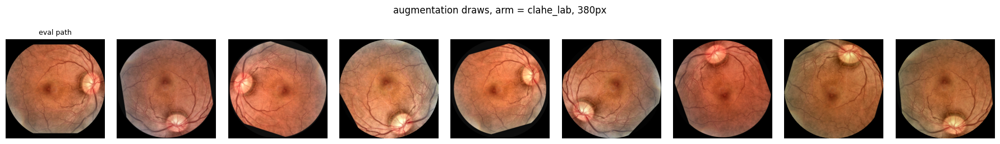

In [ ]:
## 3.5 The `tf.data` pipeline
# build the data pipeline that feeds images to the model during training and testing, and check that it works correctly.
import tensorflow as tf
cv2.setNumThreads(1)          

AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
NORM_ARM   = 'clahe_lab'      
GEOM_INTERP = cv2.INTER_LINEAR   
SCALE_RANGE = (0.90, 1.10)       
USE_VFLIP   = True             

def augment(img, rng, img_size=IMG_SIZE, norm=NORM_ARM):
    x = geom(img,
             angle=float(rng.uniform(0, 360)),
             scale=float(rng.uniform(*SCALE_RANGE)),
             hflip=bool(rng.random() < 0.5),
             vflip=bool(USE_VFLIP and rng.random() < 0.5),
             out=img_size, interp=GEOM_INTERP)
    g, c = draw_photo(rng)
    x = photo(x, g, c)
    return NORMS[norm](x)

def evaluate_path(img, img_size=IMG_SIZE, norm=NORM_ARM):
    return NORMS[norm](geom(img, 0.0, 1.0, out=img_size, interp=cv2.INTER_AREA))

def _load(path, training, img_size, norm):
    im = cv2.imread(path.decode() if isinstance(path, bytes) else path)
    if im is None:
        raise ValueError(f'unreadable image: {path}')
    x = augment(im, np.random.default_rng(), img_size, norm) if training else \
        evaluate_path(im, img_size, norm)
    return cv2.cvtColor(x, cv2.COLOR_BGR2RGB).astype(np.float32)

def make_ds(table, img_dir, ext='', training=False, img_size=IMG_SIZE, norm=NORM_ARM,
            batch_size=BATCH_SIZE, balanced=False, shuffle_buffer=4096):
    paths  = np.array([str(img_dir / f'{n}{ext}') for n in table['id_code']])
    labels = table['diagnosis'].to_numpy('int32')
    steps  = int(np.ceil(len(paths) / batch_size))

    if training and balanced:
        parts = []
        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            parts.append(tf.data.Dataset.from_tensor_slices((paths[idx], labels[idx]))
                           .shuffle(len(idx), seed=SEED, reshuffle_each_iteration=True).repeat())
        ds = tf.data.Dataset.sample_from_datasets(parts, weights=[1 / len(parts)] * len(parts), seed=SEED)
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if training:
            ds = ds.shuffle(min(len(paths), shuffle_buffer), seed=SEED, reshuffle_each_iteration=True)

    def wrap(p, y):
        x = tf.numpy_function(lambda q: _load(q, training, img_size, norm), [p], tf.float32)
        return tf.ensure_shape(x, (img_size, img_size, 3)), y

    return ds.map(wrap, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE), steps

ddr_tr, ddr_va = splits[splits['split'] == 'train'], splits[splits['split'] == 'val']
ddr_te         = splits[splits['split'] == 'test']

train_ds, train_steps = make_ds(ddr_tr, PROC / 'ddr', training=True)
val_ds,   val_steps   = make_ds(ddr_va, PROC / 'ddr')
test_ds,  test_steps  = make_ds(ddr_te, PROC / 'ddr')
ext_ds,   ext_steps   = make_ds(iext,   PROC / 'idrid', ext='.jpg')
print('steps per epoch - train %d, val %d, test %d, external %d'
      % (train_steps, val_steps, test_steps, ext_steps))

xb, yb = next(iter(train_ds))
print('\nbatch x', xb.shape, xb.dtype, '| range %.1f to %.1f' % (float(tf.reduce_min(xb)), float(tf.reduce_max(xb))))
print('batch y', yb.shape, yb.dtype, '| labels', sorted(set(yb.numpy().tolist())))
assert xb.shape[1:] == (IMG_SIZE, IMG_SIZE, 3) and xb.dtype == tf.float32
assert float(tf.reduce_max(xb)) <= 255.0 and float(tf.reduce_min(xb)) >= 0.0

a = next(iter(val_ds))[0].numpy(); b = next(iter(val_ds))[0].numpy()
assert np.array_equal(a, b), 'evaluation path is not deterministic'
c1 = next(iter(train_ds))[0].numpy(); c2 = next(iter(train_ds))[0].numpy()
print('eval path deterministic:', True, '| train path varies:', not np.array_equal(c1, c2))

ex_a = next(iter(ext_ds))[0].numpy(); ex_b = next(iter(ext_ds))[0].numpy()
assert np.array_equal(ex_a, ex_b), 'external path is not deterministic'
print('external path deterministic:', True, '| external images:', len(iext))

bal_ds, _ = make_ds(ddr_tr, PROC / 'ddr', training=True, balanced=True)
def seen(ds, nb):
    out = []
    for k, (_, y) in enumerate(ds):
        out.append(y.numpy())
        if k + 1 == nb:
            break
    return pd.Series(np.concatenate(out)).value_counts(normalize=True).sort_index() * 100
cmp_arm = pd.DataFrame({'train split': ddr_tr['diagnosis'].value_counts(normalize=True).sort_index() * 100,
                        'weighted arm (sampled)': seen(train_ds, 30),
                        'oversampled arm': seen(bal_ds, 30)}).round(1)
cmp_arm.index = [LABELS[i] for i in cmp_arm.index]
print('\nclass share of the images the network sees (%):')
print(cmp_arm.to_string())

probe = cv2.imread(str(PROC / 'ddr' / ddr_tr['id_code'].iloc[0]))
rg2 = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 9, figsize=(18, 2.4))
axes[0].imshow(cv2.cvtColor(evaluate_path(probe), cv2.COLOR_BGR2RGB)); axes[0].set_title('eval path', fontsize=9)
for ax in axes[1:]:
    ax.imshow(cv2.cvtColor(augment(probe, rg2), cv2.COLOR_BGR2RGB))
for ax in axes:
    ax.axis('off')
plt.suptitle(f'augmentation draws, arm = {NORM_ARM}, {IMG_SIZE}px', y=1.05)
plt.tight_layout(); plt.show()

**Result. The pipeline works as intended.**

Batches are 32 images of 380×380×3, with pixel values 0 to 255 (the model rescales them itself later).
Steps per epoch: 280 train, 56 val, 56 test, 15 external.

**Checks passed.** Validation, test and IDRiD images give identical results every time, and training images
change every time. So any drop on IDRiD comes from the data, not from the pipeline.

The weighted arm keeps the real class shares, and the oversampled arm shows each class about 20% of the time.
The first batch had only grades 0, 2 and 4. With Severe at 1.9%, a batch of 32 has no Severe image more than
half the time, which is why class weighting is needed.

**Order changed from the plan:** geometry, then colour jitter, then normalisation. Training and testing now
end on the same step.

**Cost to report.** Colour jitter changes hue, and hue helps tell lesions apart (dark red haemorrhages,
yellow-white exudates). The amplitude is small and the images still look normal, so it is kept.

In [ ]:
# 3.6 Throughput
# check whether the data pipeline is fast enough, so that loading and augmenting images does not slow down the GPU during training.
def throughput(ds, n_batches=12, warmup=3):
    it = iter(ds)
    for _ in range(warmup):
        next(it)
    t0, seen_n = time.time(), 0
    for _ in range(n_batches):
        xb, _ = next(it)
        seen_n += int(xb.shape[0])
    return seen_n / (time.time() - t0)

print('input pipeline throughput, images/second at IMG_SIZE=%d, batch=%d, %d vCPU'
      % (IMG_SIZE, BATCH_SIZE, os.cpu_count()))
bench = []
for arm in ('none', 'clahe_lab'):
    for train_mode in (False, True):
        d, _ = make_ds(ddr_tr if train_mode else ddr_va, PROC / 'ddr',
                       training=train_mode, norm=arm)
        bench.append({'norm arm': arm, 'path': 'train (augmented)' if train_mode else 'eval',
                      'img/s': round(throughput(d.repeat()), 1)})
print(pd.DataFrame(bench).to_string(index=False))

probe = cv2.imread(str(PROC / 'ddr' / ddr_tr['id_code'].iloc[0]))
path0 = str(PROC / 'ddr' / ddr_tr['id_code'].iloc[0])
rg3   = np.random.default_rng(SEED)
stages = {
    'decode 512 jpeg':      lambda: cv2.imread(path0),
    'geom warp to target':  lambda: geom(probe, 33.0, 1.05, out=IMG_SIZE, interp=GEOM_INTERP),
    'clahe_lab at target':  lambda: NORMS['clahe_lab'](geom(probe, 0, 1.0, out=IMG_SIZE,
                                                            interp=cv2.INTER_AREA)),
    'photo jitter':         lambda: photo(geom(probe, 0, 1.0, out=IMG_SIZE, interp=cv2.INTER_AREA),
                                          *draw_photo(rg3)),
}
print('\nper-stage cost, one thread:')
for label, fn in stages.items():
    t0 = time.time()
    for _ in range(20):
        fn()
    print(f'  {label:22s} {(time.time() - t0) / 20 * 1000:6.2f} ms/img')

slowest = min(b['img/s'] for b in bench)
print('\nslowest arm: %.0f img/s -> one training epoch of input work = %.0f s (%d images)'
      % (slowest, len(ddr_tr) / slowest, len(ddr_tr)))
print('If this is above the GPU step rate measured in 4.0, the pipeline is free and stays on the fly.')
print('If not, the fallback is a second cache written with clahe_lab baked in (geometry stays on the fly).')

**Result. The pipeline is faster after the rewrite, but still slower than the model.**

| Norm arm | Path | img/s |
|---|---|---:|
| `none` | eval | 240.6 |
| `none` | train (augmented) | 112.7 |
| `clahe_lab` | eval | 117.4 |
| `clahe_lab` | train (augmented) | 93.6 |

The slowest case (`clahe_lab`, augmented) takes **96 s of loading per epoch**, down from 130 s. `clahe_lab` is
the slowest step (7.66 ms per image, 47% of the time).

**The model runs at 260 img/s, so the pipeline is the bottleneck.** The GPU waits for about two thirds of
each epoch. Fixing it would mean a second saved copy of the images, which would break the one-cache setup
for both normalisation arms. We accept about 32 s of waiting per epoch to keep that comparison fair.

**Speeds depend on the runtime.** Some of the speed-up came from a faster session, not only from the code.

## 3.7 Section 3: Decisions

| Decision | Setting | Reason |
|---|---|---|
| Keep duplicate groups together when splitting | whole groups go into one split | 30 duplicate groups, and none is split across train, validation or test (1.16) |
| Split by grade and image source | both used together | class shares agree within 0.2 points (3.1) |
| Split sizes | 8,944 / 1,792 / 1,786 (71.4 / 14.3 / 14.3%) | Severe has only 33 test images, the minimum for measuring its recall |
| Save the split in Disk | `ddr_splits.csv` + manifest | a library change could otherwise re-split the data without warning |
| Class weighting, not resampling | **`effnum_b0.999`**, weights 0.38 / 1.02 / 0.39 / 2.43 / 0.78 | Severe's share of the loss rises from 1.9% to 9.4%. Other `beta` values were tested: 0.99 does almost nothing and 0.9999 nearly inverts the classes (3.2) |
| Keep resampling as an option | `balanced=True` | repeats the 167 Severe images 26.8× per epoch. Kept for a test in section 5 |
| Rotation 0-360°, in a single warp | rotate, zoom and resize in one step | the retina is a round disc, so rotation leaves no corner artefacts (3.3) |
| Interpolation | **`INTER_LINEAR`** | keeps 95.0% of detail, inside the 24.4% noise level, and takes half the time of two-step. CUBIC creates fake detail (143.1%) |
| Zoom | 0.90 to 1.10 | general robustness only, not widened to cover IDRiD's 15% scale gap |
| Flip left to right | on | both datasets already have a mix (54/46 and 52/48) |
| Flip top to bottom | on, switchable | no measurement supports it |
| Colour jitter | brightness 0.20, colour [0.20, 0.12, 0.12] (B, G, R), contrast 0.10 | general robustness, not a fix for the source difference (3.4) |
| Order of steps | geometry, then colour jitter, then normalisation | training and testing end on the same step (3.5) |
| Augment on the fly, training split only | validation, test and IDRiD get no random changes | otherwise the IDRiD drop in 6.0 could not be explained |
| Model input | raw RGB 0-255 | the model rescales it itself (4.0) |
| Keep CLAHE on the fly | 93.6 img/s, 96 s per epoch | a second cache would break the two-normalisation-arms setup (3.6) |

**Three findings that changed an earlier conclusion**

1. **Preprocessing removed most of the brightness difference between the two DDR sources.**
2. **What is left is in colour balance and red.** 
3. **Colour jitter cannot remove what is left.** 

**Deliberately not used**

- **Augmentation fitted to IDRiD:**
- **Shear, elastic and perspective warps:** 
- **Random erasing:**
- **Added noise or blur:**

**Limitations to carry into the report**

1. **The difference between the two DDR sources is reduced, not removed.**
2. **Colour jitter changes hue, and hue helps tell lesions apart**
3. **Top-to-bottom flip has no evidence behind it.** 
4. **Speeds depend on the runtime.**

---

# 4. CNN Architecture and Transfer Learning

| Step | What we do | Why |
|---|---|---|
| 4.1 | Set up the runtime and build the model: a pretrained backbone, then a small 5-grade output layer | There can be Different GPUs during runtime, and the model must be built the same way every time |
| 4.2 | Run sanity checks before training | Catch silent mistakes early (wrong labels, wrong pixel scaling, memorising test) |
| 4.3 | Pilot two backbones (EfficientNetV2-B0 and ResNet50) with only the new output layer trained | See if ImageNet features already help on retina images |
| 4.4 | Test how many backbone layers to unfreeze (25%, 50%, 100%) and two learning rates | Find the setting that adapts the backbone without damaging it |
| 4.5 | Train the final model on both normalisation arms (`none`, `clahe_lab`) | 2.5 found no evidence to choose between them |

In [ ]:
# 4.1 Runtime, precision, and the model factory

# set up the training environment and build a reusable function that creates # the model, so every later section builds it the same way.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

gpus = tf.config.list_physical_devices('GPU')
print('TF', tf.__version__, '| Keras', keras.__version__, '| GPU:', [g.name for g in gpus] or 'NONE (CPU)')
if gpus:
    det = tf.config.experimental.get_device_details(gpus[0])
    cc  = det.get('compute_capability')
    print('device:', det.get('device_name'), '| compute capability:', cc)
    if cc and cc >= (7, 0):                       
        keras.mixed_precision.set_global_policy('mixed_float16')
print('precision policy:', keras.mixed_precision.global_policy().name)

BACKBONES = {
    'effnetv2b0': dict(ctor=keras.applications.EfficientNetV2B0,
                       prep=None,                                  
                       kw=dict(include_preprocessing=True),
                       native=224,
                       why='modern efficient baseline; strong accuracy per FLOP, small enough to '
                           'fine-tune fully inside the time budget'),
    'resnet50':   dict(ctor=keras.applications.ResNet50,
                       prep=keras.applications.resnet50.preprocess_input,
                       kw={},
                       native=224,
                       why='the reference architecture in most published DR grading work, so it is '
                           'the comparison a reader expects'),
}

def build_model(name, img_size=IMG_SIZE, n_classes=5, dropout=0.3, trainable=False):
    """Backbone + its own normalisation + GAP + dropout + 5-way softmax head."""
    spec = BACKBONES[name]
    inp = keras.Input(shape=(img_size, img_size, 3), name='raw_rgb_0_255')
    x = inp if spec['prep'] is None else layers.Lambda(
        spec['prep'], output_shape=(img_size, img_size, 3), name='preprocess')(inp)

    base = spec['ctor'](include_top=False, weights='imagenet',
                        input_shape=(img_size, img_size, 3), **spec['kw'])
    base.trainable = trainable
    
    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(dropout, name='drop')(x)
    out = layers.Dense(n_classes, activation='softmax', dtype='float32', name='grade')(x)
    return keras.Model(inp, out, name=f'{name}_dr'), base

rows = []
for name in BACKBONES:
    m, base = build_model(name)
    total = m.count_params()
    train = int(sum(np.prod(w.shape) for w in m.trainable_weights))
    bn    = sum(1 for l in base.layers if 'BatchNormalization' in type(l).__name__)
    rows.append({'backbone': name, 'native px': BACKBONES[name]['native'],
                 'total params': f'{total:,}', 'trainable (head only)': f'{train:,}',
                 'base layers': len(base.layers), 'BN layers': bn,
                 'feature dim': base.output_shape[-1]})
    del m, base
print('\ncandidates at IMG_SIZE=%d:' % IMG_SIZE)
print(pd.DataFrame(rows).to_string(index=False))
for name in BACKBONES:
    print(f"\n{name}: {BACKBONES[name]['why']}")

probe_model, _ = build_model('effnetv2b0')
probe_out = probe_model.predict(np.random.uniform(0, 255, (2, IMG_SIZE, IMG_SIZE, 3)).astype('float32'),
                                verbose=0)
print('\nprobe output', probe_out.shape, '| row sums', probe_out.sum(1).round(4))
assert probe_out.shape == (2, 5) and np.allclose(probe_out.sum(1), 1.0, atol=1e-4)
print('model factory ready')

TF 2.20.0 | Keras 3.13.2 | GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']
device: Tesla T4 | compute capability: (7, 5)
precision policy: mixed_float16
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

candidates at IMG_SIZE=380:
  backbone  native px total params trainable (head only)  base layers  BN layers  feature dim
effnetv2b0        224    5,925,717                 6,405          270         59         1280
  resnet50        224   23,597,957                10,245          175         53         2048

effnetv2b0: modern efficient baseline; strong accuracy per FLOP, small enough to fine-tune fully inside the time budget

resnet50: the reference architecture in most published DR grading work, so it is the comparison a reader expects


I0000 00:00:1789446176.770836     213 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



probe output (2, 5) | row sums [1. 1.]
model factory ready


**Result. The model builder works.**

Runtime: Tesla T4, TF 2.20 / Keras 3.13, mixed precision on.

| Backbone | Total parameters | Trainable (head only) | Feature size |
|---|---:|---:|---:|
| EfficientNetV2-B0 | 5.9M | 6,405 | 1280 |
| ResNet50 | 23.6M | 10,245 | 2048 |

The trainable counts match the expected 1280×5+5 and 2048×5+5, so the output layer is wired correctly. A
test batch gives 5 probabilities per image that add up to 1.

Each backbone does its own pixel scaling inside the model, so the pipeline's raw 0-255 input is correct.

In [ ]:
# 4.2 Sanity checks before any real training run

# run quick checks on a tiny sample (35 images) before any real training, to catch silent mistakes that would waste hours of training.

# label alignment, pixel scaling is inside the model, batchnorm stays frozen, whether the model can overfit, speed of the model
SANITY_N      = 35        
SANITY_LR     = 1e-4
OVERFIT_LR    = 3e-4      
OVERFIT_ROUNDS, OVERFIT_STEPS = 6, 10

sane_idx = np.concatenate([g.sample(min(len(g), SANITY_N // 5), random_state=SEED).index.values
                           for _, g in ddr_tr.groupby('diagnosis')])
sane_tbl = ddr_tr.loc[sane_idx]
print('sanity batch:', len(sane_tbl), 'images |',
      {LABELS[k]: int(v) for k, v in sane_tbl['diagnosis'].value_counts().sort_index().items()})

check_ds, _ = make_ds(sane_tbl, PROC / 'ddr', training=False, batch_size=len(sane_tbl))
xs, ys = next(iter(check_ds))
assert np.array_equal(ys.numpy(), sane_tbl['diagnosis'].to_numpy('int32')), 'label/image misalignment'
print('\nA. label alignment: OK (%d labels match the table order)' % len(ys))

raw = xs.numpy()[:4]
for name in BACKBONES:
    m, _ = build_model(name)
    a, b = m.predict(raw, verbose=0), m.predict(raw / 255.0, verbose=0)
    delta = float(np.abs(a - b).max())
    print(f'B. {name:12s} max |p(0-255) - p(0-1)| = {delta:.4f}  ->',
          'scale-sensitive, normalisation present' if delta > 1e-3 else 'NO NORMALISATION IN GRAPH')
    assert delta > 1e-3, f'{name}: input scaling has no effect, preprocessing is missing'
    del m

m, base = build_model('effnetv2b0', trainable=False)
bn = [l for l in base.layers if 'BatchNormalization' in type(l).__name__][0]
before = keras.ops.convert_to_numpy(bn.moving_mean)
m.compile(optimizer=keras.optimizers.Adam(SANITY_LR),
          loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('\noptimizer after compile:', type(m.optimizer).__name__)
m.fit(check_ds.repeat(), steps_per_epoch=5, epochs=1, verbose=0)
drift = float(np.abs(keras.ops.convert_to_numpy(bn.moving_mean) - before).max())
print('C. BN moving_mean drift after 5 steps: %.3e ->' % drift,
      'frozen' if drift < 1e-6 else 'DRIFTING - the base was called in training mode')
assert drift < 1e-6, 'BatchNorm statistics updated while the backbone was frozen'
print('   trainable params during head-only training:',
      f'{int(sum(np.prod(w.shape) for w in m.trainable_weights)):,}')
del m, base

m, _ = build_model('effnetv2b0', trainable=True)
m.compile(optimizer=keras.optimizers.Adam(OVERFIT_LR),
          loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('\nD. overfitting %d images, %d steps per round:' % (len(sane_tbl), OVERFIT_STEPS))
t0 = time.time()
for r in range(OVERFIT_ROUNDS):
    h = m.fit(check_ds.repeat(), steps_per_epoch=OVERFIT_STEPS, epochs=1, verbose=0)
    print('   round %d  (%3d steps)  loss %.4f  accuracy %.3f'
          % (r + 1, (r + 1) * OVERFIT_STEPS, h.history['loss'][-1], h.history['accuracy'][-1]))
    assert np.isfinite(h.history['loss'][-1]), 'loss went NaN - check loss scaling under mixed_float16'
probe = m.predict(xs, verbose=0)
hit = int((probe.argmax(1) == ys.numpy()).sum())
print('   %.0f s total | %d/%d correct | output dtype %s | max softmax %.3f'
      % (time.time() - t0, hit, len(ys), probe.dtype, probe.max()))
print('   verdict:', 'PASS - the model can fit data'
      if hit >= 0.9 * len(ys) else 'INCONCLUSIVE - run more rounds before trusting a real training curve')

bench_ds, _ = make_ds(ddr_tr, PROC / 'ddr', training=True)
it = iter(bench_ds.repeat())
cached = [next(it) for _ in range(6)]         
m.train_on_batch(*cached[0])                  
t0 = time.time()
for xb2, yb2 in cached[1:]:
    m.train_on_batch(xb2, yb2)
gpu_rate = (len(cached) - 1) * BATCH_SIZE / (time.time() - t0)
print('\nE. model step rate: %.0f img/s (fwd+bwd, full backbone trainable, %d px, mixed precision)'
      % (gpu_rate, IMG_SIZE))
print('   input pipeline from 3.6: 68.8 img/s worst case')
print('   ->', 'pipeline is the bottleneck' if gpu_rate > 68.8 else 'GPU is the bottleneck, pipeline is free')
print('   one %d-image epoch: %.0f s GPU-bound vs %.0f s input-bound'
      % (len(ddr_tr), len(ddr_tr) / gpu_rate, len(ddr_tr) / 68.8))
del m

**Result. All five checks passed, and the pipeline is slower than the model.**

| Check | Result |
|---|---|
| A. Labels match images | exact match |
| B. Model reacts to input scale | 0.160 (EfficientNetV2), 0.545 (ResNet50) |
| C. BatchNorm stays frozen | drift 0.000, so the pretrained averages are untouched |
| D. Model can memorise 35 images | loss 1.61 to 0.0022 in 60 steps, 35/35 correct |
| E. Model speed | 260 img/s |

Mixed precision is active, with the optimizer wrapped for loss scaling and the output in float32.


=== effnetv2b0 | head-only | arm=none | 5 epochs ===
Epoch 1/5


2026-09-14 18:12:33.066931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:12:33.231021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:12:34.946072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:12:35.087899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:13:35.270054: E external/local_xla/xla/stream_

280/280 - 116s - 414ms/step - accuracy: 0.6136 - loss: 0.5814 - val_accuracy: 0.6713 - val_loss: 0.9354
Epoch 2/5
280/280 - 46s - 164ms/step - accuracy: 0.6525 - loss: 0.5161 - val_accuracy: 0.6858 - val_loss: 0.8773
Epoch 3/5
280/280 - 46s - 164ms/step - accuracy: 0.6637 - loss: 0.4909 - val_accuracy: 0.6998 - val_loss: 0.8026
Epoch 4/5
280/280 - 46s - 163ms/step - accuracy: 0.6779 - loss: 0.4786 - val_accuracy: 0.6468 - val_loss: 0.9112
Epoch 5/5
280/280 - 46s - 163ms/step - accuracy: 0.6801 - loss: 0.4710 - val_accuracy: 0.7031 - val_loss: 0.8132

=== resnet50 | head-only | arm=none | 5 epochs ===
Epoch 1/5
280/280 - 119s - 425ms/step - accuracy: 0.5796 - loss: 0.6088 - val_accuracy: 0.7076 - val_loss: 0.8215
Epoch 2/5
280/280 - 85s - 302ms/step - accuracy: 0.6407 - loss: 0.5175 - val_accuracy: 0.6763 - val_loss: 0.8287
Epoch 3/5
280/280 - 84s - 300ms/step - accuracy: 0.6526 - loss: 0.4926 - val_accuracy: 0.5681 - val_loss: 0.9914
Epoch 4/5
280/280 - 84s - 299ms/step - accuracy: 0.6

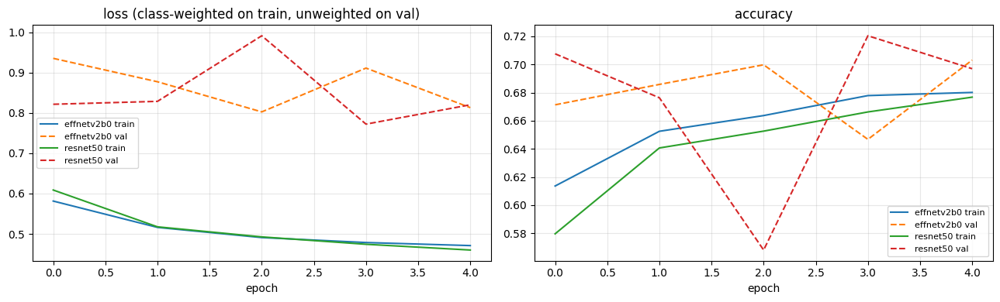

In [ ]:
# 4.3 Backbone pilot - head-only
# a quick first test of the two candidate backbones ith the backbone frozen, to see whether ImageNet features already help on retina images before spending time on fine-tuning.
from sklearn.metrics import f1_score, cohen_kappa_score, recall_score, confusion_matrix

PILOT_ARM    = 'none'     
PILOT_EPOCHS = 5
PILOT_LR     = 1e-3       
PILOT_DIR    = CACHE / 'pilots'; PILOT_DIR.mkdir(parents=True, exist_ok=True)

y_val = ddr_va['diagnosis'].to_numpy('int32')

def score(y_true, y_hat, name):
    return {'model': name,
            'accuracy': (y_hat == y_true).mean(),
            'macro F1': f1_score(y_true, y_hat, average='macro', zero_division=0),
            'QWK': cohen_kappa_score(y_true, y_hat, weights='quadratic'),
            'Severe recall': recall_score(y_true, y_hat, labels=[3], average='macro', zero_division=0),
            'Mild recall': recall_score(y_true, y_hat, labels=[1], average='macro', zero_division=0),
            'classes predicted': len(set(y_hat.tolist()))}

pilot_train, pilot_steps = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=PILOT_ARM)
pilot_val,   _           = make_ds(ddr_va, PROC / 'ddr', norm=PILOT_ARM)

pilot_rows = [score(y_val, np.zeros_like(y_val), 'baseline (all No_DR)')]
pilot_rows[0]['s/epoch'] = 0
pilot_hist, pilot_pred = {}, {}

for name in BACKBONES:
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)                 
    model, _ = build_model(name, trainable=False)
    model.compile(optimizer=keras.optimizers.Adam(PILOT_LR),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f'\n=== {name} | head-only | arm={PILOT_ARM} | {PILOT_EPOCHS} epochs ===')
    t0 = time.time()
    h = model.fit(pilot_train, validation_data=pilot_val, epochs=PILOT_EPOCHS,
                  class_weight=CLASS_WEIGHT, shuffle=False, verbose=2)
    wall = time.time() - t0

    p = model.predict(pilot_val, verbose=0)
    assert len(p) == len(y_val), 'prediction count does not match the validation table'
    y_hat = p.argmax(1)
    row = score(y_val, y_hat, name); row['s/epoch'] = round(wall / PILOT_EPOCHS)
    pilot_rows.append(row); pilot_hist[name] = h.history; pilot_pred[name] = y_hat
    del model

pilots = pd.DataFrame(pilot_rows).set_index('model').round(4)
print('\nhead-only pilot, validation set (%d images):' % len(y_val))
print(pilots.to_string())
json.dump({k: {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in pilot_hist.items()},
          open(PILOT_DIR / f'pilot_history_{PILOT_ARM}.json', 'w'))
print('\nhistories cached to', PILOT_DIR / f'pilot_history_{PILOT_ARM}.json')

print('\nconfusion matrices (rows = true grade, columns = predicted):')
for name in pilot_pred:
    cm = pd.DataFrame(confusion_matrix(y_val, pilot_pred[name], labels=range(5)),
                      index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
    print(f'\n{name}:'); print(cm.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hh in pilot_hist.items():
    axes[0].plot(hh['loss'], label=f'{name} train')
    axes[0].plot(hh['val_loss'], '--', label=f'{name} val')
    axes[1].plot(hh['accuracy'], label=f'{name} train')
    axes[1].plot(hh['val_accuracy'], '--', label=f'{name} val')
axes[0].set_title('loss (class-weighted on train, unweighted on val)')
axes[1].set_title('accuracy')
for ax in axes:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Even with the backbone frozen, both models learn useful features.**

| Model | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | s/epoch |
|---|---:|---:|---:|---:|---:|---:|
| baseline (all No_DR) | 0.5017 | 0.1336 | 0.0000 | 0.000 | 0.000 | - |
| EfficientNetV2-B0 | 0.7031 | 0.4861 | 0.6924 | 0.389 | 0.023 | 60 |
| ResNet50 | 0.6970 | 0.5216 | 0.7021 | 0.528 | 0.148 | 91 |

Both beat the baseline and predict all 5 grades. They reach QWK of about 0.69 to 0.70 with **no backbone weights
updated**, so ImageNet features already transfer to retina images.

**Mild is the hardest grade** (recall 2 of 88 and 13 of 88). Its lesions are only 1 to 6 px wide. Most mistakes
are No_DR mixed up with Moderate (293 of 532 for EfficientNetV2-B0), and that is why macro F1 is much lower
than QWK.

**ResNet50 is slightly ahead on F1 and on the rare grades, but takes about 1.5× longer per epoch** (91 s vs
60 s). This is only a pilot, and the choice between the two is made in 4.4 after fine-tuning.


--- effnetv2b0: head warm-up, 2 epochs ---
Epoch 1/2
280/280 - 94s - 335ms/step - accuracy: 0.6092 - loss: 0.5828 - val_accuracy: 0.6786 - val_loss: 0.8974
Epoch 2/2
280/280 - 42s - 150ms/step - accuracy: 0.6579 - loss: 0.5156 - val_accuracy: 0.6819 - val_loss: 0.8661

=== effnetv2b0 @50% | unfrozen from layer 135/270 | 4,615,661 trainable params | lr 0.0001 ===
Epoch 1/3


2026-09-14 18:28:28.213644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:28:28.383872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:28:29.112366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:28:29.280296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:28:30.106045: E external/local_xla/xla/stream_

280/280 - 140s - 501ms/step - accuracy: 0.6881 - loss: 0.4608 - val_accuracy: 0.7355 - val_loss: 0.7224
Epoch 2/3
280/280 - 47s - 167ms/step - accuracy: 0.7427 - loss: 0.3876 - val_accuracy: 0.7762 - val_loss: 0.6227
Epoch 3/3
280/280 - 46s - 163ms/step - accuracy: 0.7559 - loss: 0.3542 - val_accuracy: 0.7907 - val_loss: 0.5874

--- resnet50: head warm-up, 2 epochs ---
Epoch 1/2
280/280 - 103s - 368ms/step - accuracy: 0.5817 - loss: 0.6268 - val_accuracy: 0.6908 - val_loss: 0.8304
Epoch 2/2
280/280 - 85s - 302ms/step - accuracy: 0.6379 - loss: 0.5202 - val_accuracy: 0.6652 - val_loss: 0.8984

=== resnet50 @50% | unfrozen from layer 87/175 | 21,372,421 trainable params | lr 0.0001 ===
Epoch 1/3
280/280 - 212s - 758ms/step - accuracy: 0.7023 - loss: 0.4543 - val_accuracy: 0.7662 - val_loss: 0.6392
Epoch 2/3
280/280 - 150s - 537ms/step - accuracy: 0.7554 - loss: 0.3736 - val_accuracy: 0.7835 - val_loss: 0.5944
Epoch 3/3
280/280 - 150s - 535ms/step - accuracy: 0.7860 - loss: 0.3255 - val_a

2026-09-14 18:51:45.029261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:51:45.184401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:56:15.823132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 18:56:15.973310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


280/280 - 354s - 1s/step - accuracy: 0.6852 - loss: 0.4797 - val_accuracy: 0.6998 - val_loss: 0.8204
Epoch 2/3
280/280 - 253s - 903ms/step - accuracy: 0.7572 - loss: 0.3705 - val_accuracy: 0.7511 - val_loss: 0.6948
Epoch 3/3
280/280 - 252s - 901ms/step - accuracy: 0.7815 - loss: 0.3476 - val_accuracy: 0.7148 - val_loss: 0.7762
resnet50: head weights restored from Drive

=== resnet50 @50% lr3e-05 | unfrozen from layer 87/175 | 21,372,421 trainable params | lr 3e-05 ===
Epoch 1/3
280/280 - 201s - 718ms/step - accuracy: 0.6840 - loss: 0.4794 - val_accuracy: 0.7433 - val_loss: 0.6744
Epoch 2/3
280/280 - 151s - 539ms/step - accuracy: 0.7356 - loss: 0.3804 - val_accuracy: 0.7444 - val_loss: 0.6630
Epoch 3/3
280/280 - 150s - 536ms/step - accuracy: 0.7549 - loss: 0.3489 - val_accuracy: 0.7411 - val_loss: 0.6879

all fine-tuning runs (validation, 1792 images):
                      unfrozen      lr   trainable  accuracy  macro F1     QWK  Severe recall  Mild recall  classes predicted  s/epoch
m

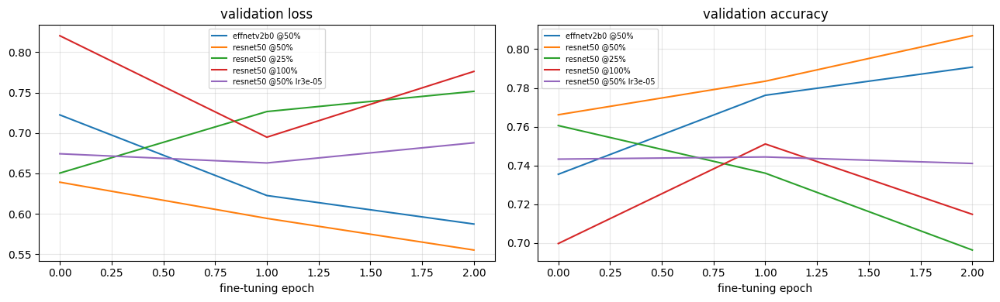

In [ ]:
# 4.4 Fine Tuning

# compare backbones after fine tuning using qwk score
# test how deep to unfreeze
# test learning rates

HEAD_EPOCHS, FT_EPOCHS = 2, 3
HEAD_LR, FT_LR         = 1e-3, 1e-4
DEPTHS                 = (0.25, 0.50, 1.00)      
PROBE_LR               = 3e-5                    
FT_ARM                 = PILOT_ARM               

ft_train, _ = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=FT_ARM)
ft_val,   _ = make_ds(ddr_va, PROC / 'ddr', norm=FT_ARM)

def head_weights(name):
    wpath = PILOT_DIR / f'head_{name}_{FT_ARM}.weights.h5'
    if wpath.exists():
        print(f'{name}: head weights restored from Drive'); return wpath
    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, _ = build_model(name, trainable=False)
    m.compile(optimizer=keras.optimizers.Adam(HEAD_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f'\n--- {name}: head warm-up, {HEAD_EPOCHS} epochs ---')
    m.fit(ft_train, validation_data=ft_val, epochs=HEAD_EPOCHS,
          class_weight=CLASS_WEIGHT, shuffle=False, verbose=2)
    m.save_weights(wpath); del m
    return wpath

def finetune(name, frac, lr, tag):
    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(name, trainable=False)
    m.load_weights(head_weights(name))
    cut = int(len(base.layers) * (1 - frac))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    trainable = int(sum(np.prod(w.shape) for w in m.trainable_weights))
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f'\n=== {tag} | unfrozen from layer {cut}/{len(base.layers)} | '
          f'{trainable:,} trainable params | lr {lr:g} ===')
    t0 = time.time()
    h = m.fit(ft_train, validation_data=ft_val, epochs=FT_EPOCHS,
              class_weight=CLASS_WEIGHT, shuffle=False, verbose=2)
    y_hat = m.predict(ft_val, verbose=0).argmax(1)
    row = score(y_val, y_hat, tag)
    row.update({'unfrozen': f'{frac:.0%}', 'lr': f'{lr:g}', 'trainable': f'{trainable:,}',
                's/epoch': round((time.time() - t0) / FT_EPOCHS)})
    del m
    return row, h.history, y_hat

ft_rows, ft_hist, ft_pred = [], {}, {}

for name in BACKBONES:
    r, h, p = finetune(name, 0.50, FT_LR, f'{name} @50%')
    ft_rows.append(r); ft_hist[r['model']] = h; ft_pred[r['model']] = p

stage_a = pd.DataFrame(ft_rows).set_index('model')
print('\nstage A - backbone choice after fine-tuning:')
print(stage_a[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall', 's/epoch']].round(4).to_string())
WINNER = stage_a['QWK'].idxmax().split(' @')[0]
print('\nwinner on QWK:', WINNER)

for frac in DEPTHS:
    if frac == 0.50:
        continue
    r, h, p = finetune(WINNER, frac, FT_LR, f'{WINNER} @{frac:.0%}')
    ft_rows.append(r); ft_hist[r['model']] = h; ft_pred[r['model']] = p

depth_tbl  = pd.DataFrame([r for r in ft_rows if r['model'].startswith(WINNER)]).set_index('model')
BEST_DEPTH = float(depth_tbl['QWK'].idxmax().split('@')[1].rstrip('%')) / 100
r, h, p = finetune(WINNER, BEST_DEPTH, PROBE_LR, f'{WINNER} @{BEST_DEPTH:.0%} lr{PROBE_LR:g}')
ft_rows.append(r); ft_hist[r['model']] = h; ft_pred[r['model']] = p

ft = pd.DataFrame(ft_rows).set_index('model')
print('\nall fine-tuning runs (validation, %d images):' % len(y_val))
print(ft[['unfrozen', 'lr', 'trainable', 'accuracy', 'macro F1', 'QWK',
          'Severe recall', 'Mild recall', 'classes predicted', 's/epoch']].round(4).to_string())
print('\nhead-only reference from 4.3: resnet50 QWK %.4f | effnetv2b0 QWK %.4f'
      % (pilots.loc['resnet50', 'QWK'], pilots.loc['effnetv2b0', 'QWK']))

BEST = ft['QWK'].idxmax()
print('\nbest configuration:', BEST)
cm = pd.DataFrame(confusion_matrix(y_val, ft_pred[BEST], labels=range(5)),
                  index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
print('\nconfusion matrix -', BEST); print(cm.to_string())
json.dump({k: {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in ft_hist.items()},
          open(PILOT_DIR / f'finetune_history_{FT_ARM}.json', 'w'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for k, hh in ft_hist.items():
    axes[0].plot(hh['val_loss'], label=k); axes[1].plot(hh['val_accuracy'], label=k)
axes[0].set_title('validation loss'); axes[1].set_title('validation accuracy')
for ax in axes:
    ax.set_xlabel('fine-tuning epoch'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Fine-tuning helps a lot, and unfreezing 50% of the layers is best.**

| Configuration | Unfrozen | lr | QWK | Severe recall | s/epoch |
|---|---|---|---:|---:|---:|
| EfficientNetV2-B0 | 50% | 1e-4 | 0.8245 | 0.694 | 82 |
| ResNet50 | 50% | 1e-4 | **0.8332** | 0.389 | 177 |
| ResNet50 | 25% | 1e-4 | 0.7391 | 0.722 | 137 |
| ResNet50 | 100% | 1e-4 | 0.7281 | 0.750 | 292 |
| ResNet50 | 50% | 3e-5 | 0.7921 | 0.667 | 174 |

Fine-tuning lifts QWK from about 0.70 (head only, 4.3) to 0.82-0.83. At 25% too few layers can adapt, and at
100% the early filters get disturbed. A learning rate of 1e-4 beats 3e-5, which is too slow for 3 epochs.

**Backbone choice: EfficientNetV2-B0.** ResNet50 leads by only 0.009 QWK, which is inside the run-to-run
spread (about 0.005-0.007). EfficientNetV2-B0 is better outside that noise: **Severe recall 0.694 against
0.389** and **82 against 177 s/epoch**.


--- effnetv2b0 | arm=none | head weights restored from Drive ---
=== effnetv2b0 | arm=none | 50% unfrozen | lr 0.0001 | 8 epochs ===
Epoch 1/8
      val QWK 0.7603 | macro F1 0.5336  <- saved
280/280 - 144s - 515ms/step - accuracy: 0.6860 - loss: 0.4604 - val_accuracy: 0.7478 - val_loss: 0.6964 - val_qwk: 0.7603 - val_macro_f1: 0.5336
Epoch 2/8
      val QWK 0.8029 | macro F1 0.5990  <- saved
280/280 - 51s - 181ms/step - accuracy: 0.7473 - loss: 0.3831 - val_accuracy: 0.7868 - val_loss: 0.6071 - val_qwk: 0.8029 - val_macro_f1: 0.5990
Epoch 3/8
      val QWK 0.8314 | macro F1 0.6271  <- saved
280/280 - 52s - 187ms/step - accuracy: 0.7674 - loss: 0.3532 - val_accuracy: 0.7852 - val_loss: 0.5939 - val_qwk: 0.8314 - val_macro_f1: 0.6271
Epoch 4/8
      val QWK 0.8339 | macro F1 0.6546  <- saved
280/280 - 52s - 186ms/step - accuracy: 0.7800 - loss: 0.3305 - val_accuracy: 0.7935 - val_loss: 0.5772 - val_qwk: 0.8339 - val_macro_f1: 0.6546
Epoch 5/8
      val QWK 0.8259 | macro F1 0.6382
280/

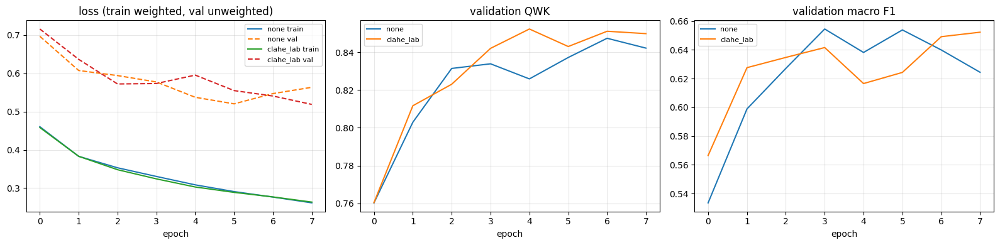

In [ ]:
# 4.5 Final runs - both normalisation arms, checkpointed
# train the chosen model for real, on both normalisation arms (none and clahe_lab), and see whether normalisation makes a difference.

CHOSEN, CHOSEN_DEPTH, CHOSEN_LR = 'effnetv2b0', 0.50, 1e-4
FINAL_EPOCHS = 8
MODEL_DIR    = CACHE / 'models'; MODEL_DIR.mkdir(parents=True, exist_ok=True)

class QWKCheckpoint(keras.callbacks.Callback):
    """Evaluates QWK on validation each epoch and keeps the best weights."""
    def __init__(self, ds, y_true, path):
        super().__init__(); self.ds, self.y = ds, y_true; self.path = path; self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        y_hat = self.model.predict(self.ds, verbose=0).argmax(1)
        q  = cohen_kappa_score(self.y, y_hat, weights='quadratic')
        f1 = f1_score(self.y, y_hat, average='macro', zero_division=0)
        logs['val_qwk'], logs['val_macro_f1'] = q, f1
        flag = ''
        if q > self.best:
            self.best = q; self.model.save_weights(self.path); flag = '  <- saved'
        print(f'      val QWK {q:.4f} | macro F1 {f1:.4f}{flag}')

def run_arm(arm):
    train_ds, _ = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=arm)
    val_ds,   _ = make_ds(ddr_va, PROC / 'ddr', norm=arm)

    wpath = PILOT_DIR / f'head_{CHOSEN}_{arm}.weights.h5'
    if not wpath.exists():
        keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
        m0, _ = build_model(CHOSEN, trainable=False)
        m0.compile(optimizer=keras.optimizers.Adam(HEAD_LR),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        print(f'\n--- {CHOSEN} | arm={arm} | head warm-up, {HEAD_EPOCHS} epochs ---')
        m0.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
               class_weight=CLASS_WEIGHT, shuffle=False, verbose=2)
        m0.save_weights(wpath); del m0
    else:
        print(f'\n--- {CHOSEN} | arm={arm} | head weights restored from Drive ---')

    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(CHOSEN, trainable=False)
    m.load_weights(wpath)
    cut = int(len(base.layers) * (1 - CHOSEN_DEPTH))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    m.compile(optimizer=keras.optimizers.Adam(CHOSEN_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    best_w = MODEL_DIR / f'{CHOSEN}_{arm}_best.weights.h5'
    print(f'=== {CHOSEN} | arm={arm} | {CHOSEN_DEPTH:.0%} unfrozen | lr {CHOSEN_LR:g} | '
          f'{FINAL_EPOCHS} epochs ===')
    t0 = time.time()
    h = m.fit(train_ds, validation_data=val_ds, epochs=FINAL_EPOCHS,
              class_weight=CLASS_WEIGHT, shuffle=False, verbose=2,
              callbacks=[QWKCheckpoint(val_ds, y_val, best_w)])
    wall = time.time() - t0

    m.load_weights(best_w)                       
    p = m.predict(val_ds, verbose=0)
    row = score(y_val, p.argmax(1), f'{CHOSEN} {arm}')
    row.update({'best epoch': int(np.argmax(h.history['val_qwk'])) + 1,
                'last-epoch QWK': round(h.history['val_qwk'][-1], 4),
                's/epoch': round(wall / FINAL_EPOCHS)})
    np.save(MODEL_DIR / f'val_probs_{CHOSEN}_{arm}.npy', p)
    del m
    return row, h.history, p.argmax(1)

arm_rows, arm_hist, arm_pred = [], {}, {}
for arm in ('none', 'clahe_lab'):
    r, h, p = run_arm(arm)
    arm_rows.append(r); arm_hist[arm] = h; arm_pred[arm] = p

arms = pd.DataFrame(arm_rows).set_index('model')
print('\nnormalisation arm comparison (validation, %d images, best epoch by QWK):' % len(y_val))
print(arms[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
            'best epoch', 'last-epoch QWK', 's/epoch']].round(4).to_string())

BEST_ARM = 'none' if arms.iloc[0]['QWK'] >= arms.iloc[1]['QWK'] else 'clahe_lab'
gap = abs(arms.iloc[0]['QWK'] - arms.iloc[1]['QWK'])
print(f'\nhigher QWK: {BEST_ARM} (gap {gap:.4f})',
      '- inside the ~0.006 run-to-run spread measured in 4.4, so read as a tie' if gap < 0.01 else '')

for arm in arm_pred:
    cm = pd.DataFrame(confusion_matrix(y_val, arm_pred[arm], labels=range(5)),
                      index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
    print(f'\nconfusion matrix - {arm}:'); print(cm.to_string())

manifest = {'backbone': CHOSEN, 'unfrozen': CHOSEN_DEPTH, 'lr': CHOSEN_LR, 'img_size': IMG_SIZE,
            'batch': BATCH_SIZE, 'head_epochs': HEAD_EPOCHS, 'epochs': FINAL_EPOCHS, 'seed': SEED,
            'class_weight': CLASS_WEIGHT,
            'arms': {a: float(arms.loc[f'{CHOSEN} {a}', 'QWK']) for a in arm_hist}}
json.dump(manifest, open(MODEL_DIR / 'final_manifest.json', 'w'), indent=1)
json.dump({a: {k: [float(x) for x in v] for k, v in hh.items()} for a, hh in arm_hist.items()},
          open(MODEL_DIR / 'final_history.json', 'w'))
print('\nsaved to', MODEL_DIR, '->', sorted(p.name for p in MODEL_DIR.iterdir()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for arm, hh in arm_hist.items():
    axes[0].plot(hh['loss'], label=f'{arm} train'); axes[0].plot(hh['val_loss'], '--', label=f'{arm} val')
    axes[1].plot(hh['val_qwk'], label=arm)
    axes[2].plot(hh['val_macro_f1'], label=arm)
axes[0].set_title('loss (train weighted, val unweighted)')
axes[1].set_title('validation QWK'); axes[2].set_title('validation macro F1')
for ax in axes:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. The two normalisation arms are a tie.**

| Arm | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | Best epoch | Last-epoch QWK | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| `none` | 0.7924 | 0.6400 | 0.8474 | 0.722 | 0.364 | 7 | 0.8422 | 63 |
| `clahe_lab` | 0.7807 | 0.6166 | **0.8523** | 0.722 | 0.295 | 5 | 0.8498 | 90 |

`clahe_lab` has the higher QWK, but the gap is 0.0049, inside the run-to-run spread (about 0.006), so this is a
tie. `clahe_lab` also takes 43% longer per epoch (90 s against 63 s). Both arms have the same Severe recall
(26 of 36). `clahe_lab` finds fewer Mild cases (26 of 88 against 32) and calls more Moderate images Severe
(53 against 44). Training for 8 epochs lifts QWK from 0.8245 (3 epochs, 4.4) to about 0.85.

**Saved for later sections**

| File | What it is |
|---|---|
| `effnetv2b0_none_best.weights.h5` | model weights from the best epoch (7) of the `none` run |
| `effnetv2b0_clahe_lab_best.weights.h5` | model weights from the best epoch (5) of the `clahe_lab` run |
| `val_probs_effnetv2b0_none.npy` | the 5 grade probabilities for each of the 1,792 validation images, `none` run |
| `val_probs_effnetv2b0_clahe_lab.npy` | the same, `clahe_lab` run |
| `final_history.json` | loss, accuracy, QWK and macro F1 for every epoch of both runs, used for the curves |
| `final_manifest.json` | the settings used (backbone, 50% unfrozen, lr 1e-4, 380 px, batch 32, 8 epochs, seed, class weights) and each arm's QWK |

The probability files are used in 6.0 for thresholds, abstention and ROC.

## 4.6 Section 4: Decisions

| Decision | Setting | Reason |
|---|---|---|
| Model shape | backbone, pooling, dropout 0.3, 5-grade output | The 5 outputs are the 5 ICDR grades |
| Input | raw RGB 0-255, scaling done inside the model | Matches the pipeline from 3.5 |
| **Backbone: EfficientNetV2-B0** | ImageNet weights, 5.9M parameters | Severe recall 0.694 vs 0.389, and 82 vs 177 s/epoch. ResNet50's 0.009 QWK lead is inside the noise (4.4) |
| **Unfreeze the top 50%** | about 4.6M trainable parameters | 25% overfits (validation accuracy falls 0.761 to 0.696). 100% disturbs the early filters (macro F1 drops to 0.409) (4.4) |
| BatchNorm kept frozen | `training=False` on the backbone | Keeps the ImageNet averages. Drift was 0 (4.2) |
| Warm up the head first | 2 epochs at 1e-3 | A random head would push large errors into the pretrained layers |
| **Learning rate 1e-4** | Adam | Beats 3e-5 (QWK 0.833 vs 0.792) (4.4) |
| Mixed precision | output layer kept in float32 | Faster on the T4 GPU (4.1) |
| Class weights from 3.2 | `effnum_b0.999` | Both arms predict all 5 grades, with Severe recall 0.72 from only 167 training images |
| **Choose the best epoch by QWK** | checkpoint saved on validation QWK | Validation loss is unweighted while training is weighted, so it favours the common grades (4.5) |
| **Main arm: `none`** | `clahe_lab` also evaluated in 6.0 | QWK gap is only 0.0049, a tie. `none` has better macro F1 (+0.023) and Mild recall (+0.068), and is 30% faster per epoch (63 vs 90 s) (4.5) |
| 8 epochs | best epoch was 7 (`none`) and 5 (`clahe_lab`) | 8 epochs covers the point where scores level off |

**Final validation result (`none`, best epoch):** accuracy 0.7924, macro F1 0.6400, **QWK 0.8474**, Severe
recall 0.7222, Mild recall 0.3636. The best epoch was picked on this same validation set, so the scores are
slightly optimistic.

**What each step added (QWK):** always predicting No_DR 0.00, then a frozen backbone with a trained head
0.69, then 50% unfrozen for 3 epochs 0.825, then 8 epochs 0.847. Transfer learning helped a lot on this
dataset.

**Two automatic picks were overridden.** The backbone (4.4) and the arm (4.5) were both chosen by highest
QWK, but the margins (0.009 and 0.0049) were smaller than the run-to-run spread (about 0.006). So both
decisions went to measures outside that noise: per-class recall and time per epoch.

**Limitations to carry into the report**

1. **Settings were tuned on limited cases.** Depth and learning rate were tested on ResNet50 only, and 4.3 and
   4.4 used the `none` arm only. That may slightly favour `none`.
2. **Both backbones were pretrained at 224 and run at 380.** This is deliberate, and 224 / 380 / 512 is tested
   in section 5.
3. **Every result is a single run.** The 0.006 spread came from an accidental re-run, not a planned repeat.
4. **No early stopping or learning rate schedule.** The 8 epochs are a fixed budget that happened to cover the
   plateau.

---
# 5. Training Strategy and Experimental Design

| Step | What we do | Why |
|---|---|---|
| 5.0 | Load the saved 4.5 model settings and files, and check they are all there | Kaggle restarts lose the session state, and 5.1 takes about 45 minutes |
| 5.1 | Compare three learning-rate schedules (fixed, reduce-on-plateau, cosine) with early stopping | Section 4 used a fixed 8 epochs, so the schedule and stopping point had not been tested |
| 5.2 | Compare three input sizes (224, 380, 512 px) | Small lesions may be lost when the image is shrunk. The backbone was pretrained at 224 |
| 5.3 | Compare three ways of handling class imbalance (class weights, oversampling, focal loss) | Severe and Mild have very few images, so the balancing method affects how well they are found |
| 5.4 | Train the two final candidates (focal loss, and focal loss with class weights) for up to 30 epochs | Pick the final model and how many epochs it needs |

In [ ]:
# 5.0 
from sklearn.metrics import f1_score, cohen_kappa_score, recall_score, confusion_matrix

PILOT_DIR = CACHE / 'pilots'; PILOT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = CACHE / 'models'; MODEL_DIR.mkdir(parents=True, exist_ok=True)
y_val     = ddr_va['diagnosis'].to_numpy('int32')

def score(y_true, y_hat, name):
    return {'model': name,
            'accuracy': (y_hat == y_true).mean(),
            'macro F1': f1_score(y_true, y_hat, average='macro', zero_division=0),
            'QWK': cohen_kappa_score(y_true, y_hat, weights='quadratic'),
            'Severe recall': recall_score(y_true, y_hat, labels=[3], average='macro', zero_division=0),
            'Mild recall': recall_score(y_true, y_hat, labels=[1], average='macro', zero_division=0),
            'classes predicted': len(set(y_hat.tolist()))}

class QWKCheckpoint(keras.callbacks.Callback):                     
    def __init__(self, ds, y_true, path):
        super().__init__(); self.ds, self.y = ds, y_true; self.path = path; self.best = -np.inf
    def on_epoch_end(self, epoch, logs=None):
        y_hat = self.model.predict(self.ds, verbose=0).argmax(1)
        q  = cohen_kappa_score(self.y, y_hat, weights='quadratic')
        f1 = f1_score(self.y, y_hat, average='macro', zero_division=0)
        logs['val_qwk'], logs['val_macro_f1'] = q, f1
        flag = ''
        if q > self.best:
            self.best = q; self.model.save_weights(self.path); flag = '  <- saved'
        print(f'      val QWK {q:.4f} | macro F1 {f1:.4f}{flag}')

need = ['models/final_manifest.json', 'models/final_history.json']
missing = [f for f in need if not (CACHE / f).exists()]
assert not missing, f'missing from the restored state: {missing} - check unpack_state() and CACHE'
_cfg = json.load(open(MODEL_DIR / 'final_manifest.json'))
hw = PILOT_DIR / f"head_{_cfg['backbone']}_none.weights.h5"
assert hw.exists(), f'head weights missing: {hw.name} - check what pack_state() captured'
print('4.5 artifacts present |', _cfg['backbone'], f"@{_cfg['unfrozen']:.0%}", 'lr', _cfg['lr'],
      '| arm QWK', {k: round(v, 4) for k, v in _cfg['arms'].items()})
print('files in models/:', sorted(p.name for p in MODEL_DIR.iterdir()))
print('files in pilots/:', sorted(p.name for p in PILOT_DIR.iterdir()))

4.5 artifacts present | effnetv2b0 @50% lr 0.0001 | arm QWK {'none': 0.8474, 'clahe_lab': 0.8523}
files in models/: ['effnetv2b0_clahe_lab_best.weights.h5', 'effnetv2b0_none_best.weights.h5', 'final_history.json', 'final_manifest.json', 'val_probs_effnetv2b0_clahe_lab.npy', 'val_probs_effnetv2b0_none.npy']
files in pilots/: ['finetune_history_none.json', 'head_effnetv2b0_clahe_lab.weights.h5', 'head_effnetv2b0_none.weights.h5', 'head_resnet50_none.weights.h5', 'pilot_history_none.json']


carried from 4.5: effnetv2b0 @50% lr 0.0001 | arm none | arm QWK {'none': 0.8474, 'clahe_lab': 0.8523}

=== fixed_lr | max 20 epochs | ES patience 4 ===
Epoch 1/20


2026-09-15 04:29:50.280148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:29:50.454101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:29:52.087774: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:29:52.236625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:29:53.472460: E external/local_xla/xla/stream_

      val QWK 0.7583 | macro F1 0.5394  <- saved
280/280 - 169s - 605ms/step - accuracy: 0.6917 - loss: 0.4655 - val_accuracy: 0.7254 - val_loss: 0.7620 - val_qwk: 0.7583 - val_macro_f1: 0.5394
Epoch 2/20
      val QWK 0.8101 | macro F1 0.6027  <- saved
280/280 - 57s - 203ms/step - accuracy: 0.7450 - loss: 0.3900 - val_accuracy: 0.7746 - val_loss: 0.6286 - val_qwk: 0.8101 - val_macro_f1: 0.6027
Epoch 3/20
      val QWK 0.8216 | macro F1 0.6209  <- saved
280/280 - 55s - 197ms/step - accuracy: 0.7662 - loss: 0.3507 - val_accuracy: 0.7924 - val_loss: 0.5822 - val_qwk: 0.8216 - val_macro_f1: 0.6209
Epoch 4/20
      val QWK 0.8290 | macro F1 0.6390  <- saved
280/280 - 54s - 192ms/step - accuracy: 0.7782 - loss: 0.3308 - val_accuracy: 0.7651 - val_loss: 0.6069 - val_qwk: 0.8290 - val_macro_f1: 0.6390
Epoch 5/20
      val QWK 0.8376 | macro F1 0.6205  <- saved
280/280 - 56s - 198ms/step - accuracy: 0.7894 - loss: 0.3009 - val_accuracy: 0.7924 - val_loss: 0.5667 - val_qwk: 0.8376 - val_macro_f

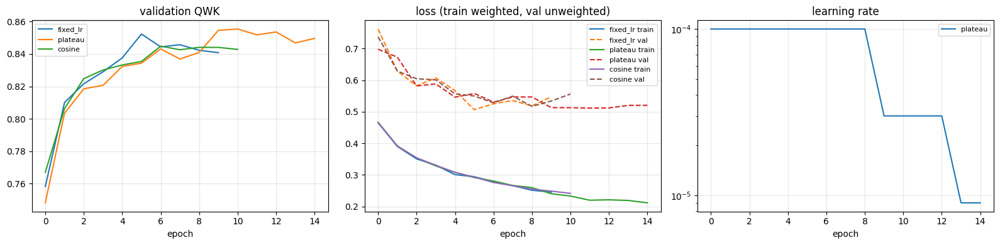

In [ ]:
# 5.1 Learning-rate schedule and early stopping
cfg = json.load(open(MODEL_DIR / 'final_manifest.json'))
S_BACKBONE, S_DEPTH, S_LR = cfg['backbone'], cfg['unfrozen'], cfg['lr']
S_ARM = 'none'
print('carried from 4.5:', S_BACKBONE, f'@{S_DEPTH:.0%}', 'lr', S_LR, '| arm', S_ARM,
      '| arm QWK', {k: round(v, 4) for k, v in cfg['arms'].items()})

MAX_EPOCHS   = 20       
ES_PATIENCE  = 4         
RLR_PATIENCE = 2
RLR_FACTOR   = 0.3
STRAT_DIR    = CACHE / 'strategy'; STRAT_DIR.mkdir(parents=True, exist_ok=True)

s_train, s_steps = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=S_ARM)
s_val,   _       = make_ds(ddr_va, PROC / 'ddr', norm=S_ARM)

def build_finetuned(lr_or_schedule):
    """The 4.5 configuration rebuilt: cached head restored, top `S_DEPTH` of the base unfrozen."""
    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(S_BACKBONE, trainable=False)
    m.load_weights(PILOT_DIR / f'head_{S_BACKBONE}_{S_ARM}.weights.h5')
    cut = int(len(base.layers) * (1 - S_DEPTH))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    m.compile(optimizer=keras.optimizers.Adam(lr_or_schedule),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def run_strategy(tag, schedule=None, use_plateau=False):
    """One run under one schedule. `schedule` and `use_plateau` are mutually exclusive:
    ReduceLROnPlateau writes to optimizer.learning_rate, which a schedule object owns."""
    best_w = STRAT_DIR / f'{tag}.weights.h5'
    m = build_finetuned(schedule if schedule is not None else S_LR)
    cbs = [QWKCheckpoint(s_val, y_val, best_w)]
    if use_plateau:
        cbs.append(keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=RLR_FACTOR,
                                                     patience=RLR_PATIENCE, min_lr=1e-6, verbose=1))
    cbs.append(keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=ES_PATIENCE,
                                             restore_best_weights=True, verbose=1))
    print(f'\n=== {tag} | max {MAX_EPOCHS} epochs | ES patience {ES_PATIENCE} ===')
    t0 = time.time()
    h = m.fit(s_train, validation_data=s_val, epochs=MAX_EPOCHS, class_weight=CLASS_WEIGHT,
              shuffle=False, verbose=2, callbacks=cbs)
    wall = time.time() - t0

    m.load_weights(best_w)
    p = m.predict(s_val, verbose=0)
    row = score(y_val, p.argmax(1), tag)
    row.update({'epochs run': len(h.history['loss']),
                'best epoch': int(np.argmax(h.history['val_qwk'])) + 1,
                'last QWK': round(h.history['val_qwk'][-1], 4),
                'total min': round(wall / 60, 1)})
    np.save(STRAT_DIR / f'val_probs_{tag}.npy', p)
    del m
    return row, h.history

strat_rows, strat_hist = [], {}

r, h = run_strategy('fixed_lr'); strat_rows.append(r); strat_hist['fixed_lr'] = h

r, h = run_strategy('plateau', use_plateau=True); strat_rows.append(r); strat_hist['plateau'] = h

cos = keras.optimizers.schedules.CosineDecay(S_LR, decay_steps=s_steps * MAX_EPOCHS, alpha=0.02)
r, h = run_strategy('cosine', schedule=cos); strat_rows.append(r); strat_hist['cosine'] = h

strat = pd.DataFrame(strat_rows).set_index('model')
print('\ntraining strategy comparison (validation, %d images, best checkpoint):' % len(y_val))
print(strat[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
             'epochs run', 'best epoch', 'last QWK', 'total min']].round(4).to_string())
print('\n4.5 reference (8 fixed epochs, no callbacks): QWK %.4f' % cfg['arms'][S_ARM])

json.dump({k: {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in strat_hist.items()},
          open(STRAT_DIR / 'strategy_history.json', 'w'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for tag, hh in strat_hist.items():
    axes[0].plot(hh['val_qwk'], label=tag)
    axes[1].plot(hh['loss'], label=f'{tag} train'); axes[1].plot(hh['val_loss'], '--', label=f'{tag} val')
    if 'learning_rate' in hh:
        axes[2].plot(hh['learning_rate'], label=tag)
axes[0].set_title('validation QWK'); axes[1].set_title('loss (train weighted, val unweighted)')
axes[2].set_title('learning rate'); axes[2].set_yscale('log')
for ax in axes:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Reduce-on-plateau is chosen, but the three strategies are close to a tie.**

| Strategy | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | Epochs | Best epoch | Minutes |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| fixed | 0.8131 | 0.6482 | 0.8523 | 0.694 | 0.205 | 10 | 6 | 11.0 |
| **plateau** | 0.8119 | 0.6582 | **0.8554** | 0.611 | 0.375 | 15 | 11 | 15.7 |
| cosine | 0.8064 | 0.6533 | 0.8448 | 0.583 | 0.364 | 11 | 7 | 11.6 |

The 4.5 reference (8 fixed epochs, no early stopping) had QWK 0.8474.

**Why plateau.** QWK was stuck at 0.836-0.843 during epochs 6 to 9. After the learning rate was cut to 3e-5,
it rose straight to 0.8546 and 0.8554. A second cut (to 9e-6) gave nothing more. The lead over fixed (0.003)
is inside the run-to-run spread (about 0.006), so the choice rests on this behaviour, not on the score.

**Why not cosine.** It plans to lower the rate over 20 epochs, but early stopping ended the run at 11, so it
never reached its low-rate phase. Cosine needs to run to the end, and early stopping prevents that.

**Patience of 4** comes from 4.5, where `none` dipped at epoch 5 and then peaked at epoch 7. A patience of 1 or 2
would have stopped at the dip.


=== 224 px | effnetv2b0 @50% | arm none | max 20 epochs ===
Epoch 1/20


2026-09-15 05:13:51.487575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:13:51.626090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:13:53.087431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:13:53.228750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:13:54.196464: E external/local_xla/xla/stream_

      val QWK 0.7227 | macro F1 0.5198  <- saved
280/280 - 128s - 457ms/step - accuracy: 0.6555 - loss: 0.4962 - val_accuracy: 0.7204 - val_loss: 0.7603 - val_qwk: 0.7227 - val_macro_f1: 0.5198 - learning_rate: 1.0000e-04
Epoch 2/20
      val QWK 0.7654 | macro F1 0.5740  <- saved
280/280 - 31s - 109ms/step - accuracy: 0.7191 - loss: 0.4208 - val_accuracy: 0.7612 - val_loss: 0.6801 - val_qwk: 0.7654 - val_macro_f1: 0.5740 - learning_rate: 1.0000e-04
Epoch 3/20
      val QWK 0.7808 | macro F1 0.5903  <- saved
280/280 - 31s - 110ms/step - accuracy: 0.7291 - loss: 0.3936 - val_accuracy: 0.7494 - val_loss: 0.6831 - val_qwk: 0.7808 - val_macro_f1: 0.5903 - learning_rate: 1.0000e-04
Epoch 4/20
      val QWK 0.7952 | macro F1 0.5801  <- saved
280/280 - 31s - 109ms/step - accuracy: 0.7399 - loss: 0.3744 - val_accuracy: 0.7539 - val_loss: 0.6459 - val_qwk: 0.7952 - val_macro_f1: 0.5801 - learning_rate: 1.0000e-04
Epoch 5/20
      val QWK 0.8050 | macro F1 0.5967  <- saved
280/280 - 31s - 111ms/

2026-09-15 05:36:47.464229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:36:47.643887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:36:48.729843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:36:48.934245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:36:50.155074: E external/local_xla/xla/stream_

      val QWK 0.7641 | macro F1 0.5575  <- saved
280/280 - 225s - 803ms/step - accuracy: 0.6928 - loss: 0.4579 - val_accuracy: 0.7500 - val_loss: 0.6829 - val_qwk: 0.7641 - val_macro_f1: 0.5575 - learning_rate: 1.0000e-04
Epoch 2/20
      val QWK 0.8074 | macro F1 0.6137  <- saved
280/280 - 92s - 328ms/step - accuracy: 0.7578 - loss: 0.3709 - val_accuracy: 0.7974 - val_loss: 0.5769 - val_qwk: 0.8074 - val_macro_f1: 0.6137 - learning_rate: 1.0000e-04
Epoch 3/20
      val QWK 0.8282 | macro F1 0.6348  <- saved
280/280 - 93s - 330ms/step - accuracy: 0.7763 - loss: 0.3367 - val_accuracy: 0.7852 - val_loss: 0.5720 - val_qwk: 0.8282 - val_macro_f1: 0.6348 - learning_rate: 1.0000e-04
Epoch 4/20
      val QWK 0.8338 | macro F1 0.6404  <- saved
280/280 - 92s - 329ms/step - accuracy: 0.7910 - loss: 0.3177 - val_accuracy: 0.7907 - val_loss: 0.5552 - val_qwk: 0.8338 - val_macro_f1: 0.6404 - learning_rate: 1.0000e-04
Epoch 5/20
      val QWK 0.8302 | macro F1 0.6569
280/280 - 91s - 325ms/step - acc

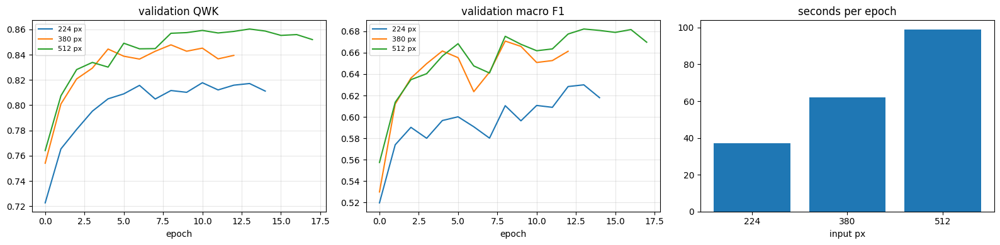

In [ ]:
# 5.2 Input resolution ablation
RESOLUTIONS = (224, 380, 512)
RES_DIR     = CACHE / 'resolution'; RES_DIR.mkdir(parents=True, exist_ok=True)
RES_PLATEAU = True

def run_resolution(px):
    tr, steps = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=S_ARM, img_size=px)
    va, _     = make_ds(ddr_va, PROC / 'ddr', norm=S_ARM, img_size=px)

    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(S_BACKBONE, img_size=px, trainable=False)
    m.load_weights(PILOT_DIR / f'head_{S_BACKBONE}_{S_ARM}.weights.h5')
    cut = int(len(base.layers) * (1 - S_DEPTH))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    m.compile(optimizer=keras.optimizers.Adam(S_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    best_w = RES_DIR / f'res_{px}.weights.h5'
    cbs = [QWKCheckpoint(va, y_val, best_w)]
    if RES_PLATEAU:
        cbs.append(keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=RLR_FACTOR,
                                                     patience=RLR_PATIENCE, min_lr=1e-6, verbose=1))
    cbs.append(keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=ES_PATIENCE,
                                             restore_best_weights=True, verbose=1))
    print(f'\n=== {px} px | {S_BACKBONE} @{S_DEPTH:.0%} | arm {S_ARM} | max {MAX_EPOCHS} epochs ===')
    t0 = time.time()
    h = m.fit(tr, validation_data=va, epochs=MAX_EPOCHS, class_weight=CLASS_WEIGHT,
              shuffle=False, verbose=2, callbacks=cbs)
    wall = time.time() - t0

    m.load_weights(best_w)
    p = m.predict(va, verbose=0)
    row = score(y_val, p.argmax(1), f'{px} px')
    row.update({'epochs run': len(h.history['loss']),
                'best epoch': int(np.argmax(h.history['val_qwk'])) + 1,
                's/epoch': round(wall / len(h.history['loss'])),
                'total min': round(wall / 60, 1),
                'um/px': round(40 * 1000 / px / 2, 1)})  
    np.save(RES_DIR / f'val_probs_{px}.npy', p)
    del m
    return row, h.history

res_rows, res_hist = [], {}
for px in RESOLUTIONS:
    r, h = run_resolution(px)
    res_rows.append(r); res_hist[px] = h

res = pd.DataFrame(res_rows).set_index('model')
print('\nresolution ablation (validation, %d images, best checkpoint):' % len(y_val))
print(res[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
           'epochs run', 'best epoch', 's/epoch', 'total min', 'um/px']].round(4).to_string())
print('\n5.1 reference at 380 px (plateau): QWK %.4f' % strat.loc['plateau', 'QWK'])
print('backbone pretraining resolution: %d px' % BACKBONES[S_BACKBONE]['native'])

json.dump({str(k): {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in res_hist.items()},
          open(RES_DIR / 'resolution_history.json', 'w'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for px, hh in res_hist.items():
    axes[0].plot(hh['val_qwk'], label=f'{px} px')
    axes[1].plot(hh['val_macro_f1'], label=f'{px} px')
axes[2].bar([str(p) for p in RESOLUTIONS], [res.loc[f'{p} px', 's/epoch'] for p in RESOLUTIONS])
axes[0].set_title('validation QWK'); axes[1].set_title('validation macro F1')
axes[2].set_title('seconds per epoch'); axes[2].set_xlabel('input px')
for ax in axes[:2]:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Higher resolution is better, and the gain is real.**

| Input | µm/px | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | s/epoch | Minutes |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 224 | 89.3 | 0.7790 | 0.6107 | 0.8178 | 0.556 | 0.239 | 37 | 9.2 |
| 380 | 52.6 | 0.8075 | 0.6709 | 0.8478 | 0.639 | 0.386 | 62 | 13.4 |
| **512** | 39.1 | **0.8198** | **0.6822** | **0.8603** | 0.611 | **0.500** | 99 | 29.7 |

QWK, accuracy and macro F1 all rise with size. The 224 to 512 gap of 0.0425 QWK is about five times the noise
level (about 0.008), so it is real.

**Mild recall doubles** (0.239 to 0.500, which is 21 to 44 of 88 images). This is what 2.7 predicted. At 224 px
one pixel covers 89 µm, and a microaneurysm is 20-100 µm, so a small one is smaller than a pixel and never
reaches the model. At 512 px one pixel covers 39 µm. Severe does not follow the trend, because its evidence is
large haemorrhages that survive shrinking, and one image out of 36 is 2.8 points.

**Cost: 3.2× the training time for 0.0425 QWK** (29.7 vs 9.2 min). 380 px gets 70% of the gain for 45% of the
time, so it is kept as the cheaper option.

**The backbone does worst at 224 px, the size it was pretrained at.** Seeing the small lesions matters more
than matching the pretraining size.

**Noise level updated to about 0.008.** 380 px scored 0.8478 here and 0.8554 in 5.1 with the same settings, so
earlier margins in sections 4 and 5 are read against this value.


=== oversampled | 512 px | weights=no | sampling=balanced | loss=sparse_categorical_crossentropy ===
Epoch 1/20
      val QWK 0.7446 | macro F1 0.5036  <- saved
280/280 - 169s - 605ms/step - accuracy: 0.6061 - loss: 0.9541 - val_accuracy: 0.5619 - val_loss: 0.9497 - val_qwk: 0.7446 - val_macro_f1: 0.5036 - learning_rate: 1.0000e-04
Epoch 2/20
      val QWK 0.7928 | macro F1 0.5790  <- saved
280/280 - 93s - 331ms/step - accuracy: 0.6960 - loss: 0.7376 - val_accuracy: 0.6685 - val_loss: 0.7875 - val_qwk: 0.7928 - val_macro_f1: 0.5790 - learning_rate: 1.0000e-04
Epoch 3/20
      val QWK 0.7972 | macro F1 0.5661  <- saved
280/280 - 92s - 327ms/step - accuracy: 0.7493 - loss: 0.6213 - val_accuracy: 0.6574 - val_loss: 0.7925 - val_qwk: 0.7972 - val_macro_f1: 0.5661 - learning_rate: 1.0000e-04
Epoch 4/20
      val QWK 0.8035 | macro F1 0.5751  <- saved
280/280 - 92s - 327ms/step - accuracy: 0.7825 - loss: 0.5464 - val_accuracy: 0.6936 - val_loss: 0.7716 - val_qwk: 0.8035 - val_macro_f1: 0.57

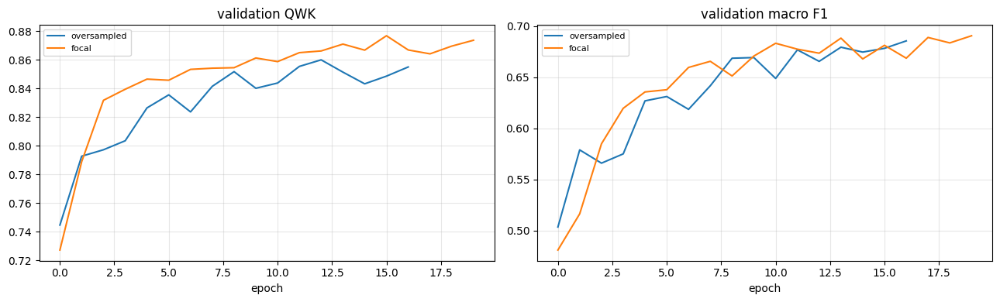

In [ ]:
# 5.3 Balancing strategy: weights, resampling, or focal loss
# find the best way to handle the class imbalance during training, since Severe and Mild have very few images.

S_PX     = 512        
BAL_DIR  = CACHE / 'balancing'; BAL_DIR.mkdir(parents=True, exist_ok=True)
FOCAL_GAMMA = 2.0

def sparse_focal(gamma=FOCAL_GAMMA, alpha=None, n_classes=5):
    a = None if alpha is None else keras.ops.convert_to_tensor(np.asarray(alpha, 'float32'))
    def loss(y_true, y_pred):
        yt = keras.ops.cast(keras.ops.reshape(y_true, (-1,)), 'int32')
        p  = keras.ops.clip(keras.ops.cast(y_pred, 'float32'), 1e-7, 1.0)
        oh = keras.ops.one_hot(yt, n_classes)
        pt = keras.ops.sum(oh * p, axis=-1)
        w  = keras.ops.power(1.0 - pt, gamma)
        if a is not None:
            w = w * keras.ops.sum(oh * a, axis=-1)
        return keras.ops.mean(-w * keras.ops.log(pt))
    loss.__name__ = f'sparse_focal_g{gamma}'
    return loss

def run_balancing(tag, balanced=False, loss='sparse_categorical_crossentropy', weights=None):
    tr, steps = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=S_ARM,
                        img_size=S_PX, balanced=balanced)
    va, _     = make_ds(ddr_va, PROC / 'ddr', norm=S_ARM, img_size=S_PX)

    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(S_BACKBONE, img_size=S_PX, trainable=False)
    m.load_weights(PILOT_DIR / f'head_{S_BACKBONE}_{S_ARM}.weights.h5')
    cut = int(len(base.layers) * (1 - S_DEPTH))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    m.compile(optimizer=keras.optimizers.Adam(S_LR), loss=loss, metrics=['accuracy'])

    best_w = BAL_DIR / f'{tag}.weights.h5'
    cbs = [QWKCheckpoint(va, y_val, best_w),
           keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=RLR_FACTOR,
                                             patience=RLR_PATIENCE, min_lr=1e-6, verbose=1),
           keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=ES_PATIENCE,
                                         restore_best_weights=True, verbose=1)]
    print(f'\n=== {tag} | {S_PX} px | weights={"yes" if weights else "no"} | '
          f'sampling={"balanced" if balanced else "natural"} | loss={getattr(loss, "__name__", loss)} ===')
    t0 = time.time()
    h = m.fit(tr, validation_data=va, epochs=MAX_EPOCHS, class_weight=weights, shuffle=False,
              verbose=2, callbacks=cbs, **({'steps_per_epoch': steps} if balanced else {}))
    wall = time.time() - t0

    m.load_weights(best_w)
    p = m.predict(va, verbose=0)
    row = score(y_val, p.argmax(1), tag)
    row.update({'epochs run': len(h.history['loss']),
                'best epoch': int(np.argmax(h.history['val_qwk'])) + 1,
                's/epoch': round(wall / len(h.history['loss'])),
                'total min': round(wall / 60, 1)})
    np.save(BAL_DIR / f'val_probs_{tag}.npy', p)
    del m
    return row, h.history

bal_rows, bal_hist = [], {}

w_row = res.loc[f'{S_PX} px'].to_dict(); w_row['model'] = 'class weights (5.2)'
bal_rows.append(w_row)

r, h = run_balancing('oversampled', balanced=True); bal_rows.append(r); bal_hist['oversampled'] = h

r, h = run_balancing('focal', loss=sparse_focal()); bal_rows.append(r); bal_hist['focal'] = h

bal = pd.DataFrame(bal_rows).set_index('model')
print('\nbalancing strategy comparison (validation, %d images, %d px):' % (len(y_val), S_PX))
print(bal[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
           'epochs run', 'best epoch', 's/epoch', 'total min']].round(4).to_string())
print('\nrun-to-run spread measured so far: ~0.008 QWK (380 px scored 0.8554 in 5.1, 0.8478 in 5.2)')

for tag in bal_hist:
    cm = pd.DataFrame(confusion_matrix(y_val, np.load(BAL_DIR / f'val_probs_{tag}.npy').argmax(1),
                                       labels=range(5)),
                      index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
    print(f'\nconfusion matrix - {tag}:'); print(cm.to_string())

json.dump({k: {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in bal_hist.items()},
          open(BAL_DIR / 'balancing_history.json', 'w'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for tag, hh in bal_hist.items():
    axes[0].plot(hh['val_qwk'], label=tag); axes[1].plot(hh['val_macro_f1'], label=tag)
for ax, t in zip(axes, ['validation QWK', 'validation macro F1']):
    ax.set_title(t); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Focal loss has the best QWK, but it finds fewer Mild cases.**

| Strategy | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | Epochs | Best epoch |
|---|---:|---:|---:|---:|---:|---:|---:|
| class weights (5.2) | 0.8198 | **0.6822** | 0.8603 | **0.611** | 0.500 | 18 | 14 |
| oversampled | 0.7969 | 0.6656 | 0.8601 | 0.556 | **0.614** | 17 | 13 |
| **focal** | **0.8493** | 0.6813 | **0.8769** | 0.556 | 0.284 | 20 | 16 |

**Focal is the one real difference.** Its QWK lead is 0.0166, about twice the noise level (0.008). It is also
the most accurate on the large grades (866 of 899 No_DR, 510 of 640 Moderate).

**Focal's cost is Mild.** It finds 25 of 88, and sends 36 to No_DR. Focal gives more weight to images the model
still gets wrong, not to rarer grades. The many easy No_DR images still outweigh the few Mild ones.

**Oversampling has the best Mild recall (54 of 88), but the same QWK as class weights** (0.8601 vs 0.8603).
It calls 86 healthy eyes Mild, and its training accuracy (0.918) sits well above validation (0.814), so it is
memorising the 167 repeated Severe images. Its Mild gain is not worth that cost.

**Class weights were not re-run.** 5.2's 512 px run has the identical setup.

In [ ]:
# 5.4 Final candidates - full budget, and the combination 5.3 left untested
FINAL_MAX_EPOCHS = 30        
FINAL_DIR = CACHE / 'final'; FINAL_DIR.mkdir(parents=True, exist_ok=True)
RUN_ALPHA = True             

ALPHA = [CLASS_WEIGHT[i] for i in range(5)]
ALPHA = list(np.asarray(ALPHA) / np.mean(ALPHA))
print('focal alpha (from 3.2 effnum_b0.999):', [round(a, 3) for a in ALPHA])

def run_final(tag, loss):
    tr, steps = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=S_ARM, img_size=S_PX)
    va, _     = make_ds(ddr_va, PROC / 'ddr', norm=S_ARM, img_size=S_PX)

    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m, base = build_model(S_BACKBONE, img_size=S_PX, trainable=False)
    m.load_weights(PILOT_DIR / f'head_{S_BACKBONE}_{S_ARM}.weights.h5')
    cut = int(len(base.layers) * (1 - S_DEPTH))
    base.trainable = True
    for l in base.layers[:cut]:
        l.trainable = False
    m.compile(optimizer=keras.optimizers.Adam(S_LR), loss=loss, metrics=['accuracy'])

    best_w = FINAL_DIR / f'{tag}.weights.h5'
    cbs = [QWKCheckpoint(va, y_val, best_w),
           keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=RLR_FACTOR,
                                             patience=RLR_PATIENCE, min_lr=1e-6, verbose=1),
           keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=ES_PATIENCE,
                                         restore_best_weights=True, verbose=1)]
    print(f'\n=== FINAL {tag} | {S_BACKBONE} @{S_DEPTH:.0%} | {S_PX} px | arm {S_ARM} | '
          f'lr {S_LR:g} | max {FINAL_MAX_EPOCHS} epochs ===')
    t0 = time.time()
    h = m.fit(tr, validation_data=va, epochs=FINAL_MAX_EPOCHS, shuffle=False, verbose=2, callbacks=cbs)
    wall = time.time() - t0

    m.load_weights(best_w)
    p = m.predict(va, verbose=0)
    row = score(y_val, p.argmax(1), tag)
    row.update({'epochs run': len(h.history['loss']),
                'best epoch': int(np.argmax(h.history['val_qwk'])) + 1,
                'hit ceiling': len(h.history['loss']) == FINAL_MAX_EPOCHS,
                's/epoch': round(wall / len(h.history['loss'])),
                'total min': round(wall / 60, 1)})
    np.save(FINAL_DIR / f'val_probs_{tag}.npy', p)
    del m
    return row, h.history

fin_rows, fin_hist = [], {}
r, h = run_final('focal', sparse_focal()); fin_rows.append(r); fin_hist['focal'] = h
if RUN_ALPHA:
    r, h = run_final('focal_alpha', sparse_focal(alpha=ALPHA))
    fin_rows.append(r); fin_hist['focal_alpha'] = h

fin = pd.DataFrame(fin_rows).set_index('model')
print('\nfinal candidates (validation, %d images, %d px, full budget):' % (len(y_val), S_PX))
print(fin[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
           'epochs run', 'best epoch', 'hit ceiling', 'total min']].round(4).to_string())
print('\n5.3 reference at %d px: class weights QWK %.4f (Mild %.4f) | focal QWK %.4f (Mild %.4f)'
      % (S_PX, bal.loc['class weights (5.2)', 'QWK'], bal.loc['class weights (5.2)', 'Mild recall'],
         bal.loc['focal', 'QWK'], bal.loc['focal', 'Mild recall']))

for tag in fin_hist:
    cm = pd.DataFrame(confusion_matrix(y_val, np.load(FINAL_DIR / f'val_probs_{tag}.npy').argmax(1),
                                       labels=range(5)),
                      index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
    print(f'\nconfusion matrix - {tag}:'); print(cm.to_string())
    yh = np.load(FINAL_DIR / f'val_probs_{tag}.npy').argmax(1)
    ref_t, ref_p = (y_val >= 2), (yh >= 2)
    tp, fn = int((ref_t & ref_p).sum()), int((ref_t & ~ref_p).sum())
    tn, fp = int((~ref_t & ~ref_p).sum()), int((~ref_t & ref_p).sum())
    print(f'   referable (grade>=2) sensitivity {tp/(tp+fn):.4f} | specificity {tn/(tn+fp):.4f} '
          f'| missed {fn} of {tp+fn}')

BEST_FINAL = fin['QWK'].idxmax()
print('\nhighest QWK:', BEST_FINAL, '- confirm against Mild recall before accepting')

json.dump({k: {m: [float(x) for x in v] for m, v in hh.items()} for k, hh in fin_hist.items()},
          open(FINAL_DIR / 'final_history.json', 'w'))
json.dump({'backbone': S_BACKBONE, 'unfrozen': S_DEPTH, 'lr': S_LR, 'arm': S_ARM, 'img_size': S_PX,
           'batch': BATCH_SIZE, 'schedule': 'plateau f0.3 p2 + early stop p4', 'seed': SEED,
           'focal_gamma': FOCAL_GAMMA, 'alpha': ALPHA,
           'candidates': {k: float(fin.loc[k, 'QWK']) for k in fin_hist}},
          open(FINAL_DIR / 'final_manifest.json', 'w'), indent=1)
print('saved ->', sorted(p.name for p in FINAL_DIR.iterdir()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for tag, hh in fin_hist.items():
    axes[0].plot(hh['val_qwk'], label=tag); axes[1].plot(hh['val_macro_f1'], label=tag)
for ax, t in zip(axes, ['validation QWK', 'validation macro F1']):
    ax.set_title(t); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

focal alpha (from 3.2 effnum_b0.999): [np.float64(0.378), np.float64(1.024), np.float64(0.39), np.float64(2.429), np.float64(0.78)]

=== FINAL focal | effnetv2b0 @50% | 512 px | arm none | lr 0.0001 | max 30 epochs ===
Epoch 1/30
      val QWK 0.7515 | macro F1 0.4792  <- saved
280/280 - 199s - 712ms/step - accuracy: 0.7150 - loss: 0.3746 - val_accuracy: 0.7751 - val_loss: 0.2815 - val_qwk: 0.7515 - val_macro_f1: 0.4792 - learning_rate: 1.0000e-04
Epoch 2/30
      val QWK 0.7900 | macro F1 0.5226  <- saved
280/280 - 91s - 326ms/step - accuracy: 0.7742 - loss: 0.2783 - val_accuracy: 0.7991 - val_loss: 0.2427 - val_qwk: 0.7900 - val_macro_f1: 0.5226 - learning_rate: 1.0000e-04
Epoch 3/30
      val QWK 0.8206 | macro F1 0.6074  <- saved
280/280 - 91s - 325ms/step - accuracy: 0.7918 - loss: 0.2484 - val_accuracy: 0.8164 - val_loss: 0.2310 - val_qwk: 0.8206 - val_macro_f1: 0.6074 - learning_rate: 1.0000e-04
Epoch 4/30
      val QWK 0.8388 | macro F1 0.6206  <- saved
280/280 - 135s - 484ms/s

5.4 config: {'backbone': 'effnetv2b0', 'unfrozen': 0.5, 'lr': 0.0001, 'arm': 'none', 'img_size': 512, 'batch': 32, 'schedule': 'plateau f0.3 p2 + early stop p4', 'seed': 42, 'focal_gamma': 2.0, 'candidates': {'focal': 0.8681981550162188, 'focal_alpha': 0.8521724423003055}}

5.4 final candidates (validation, 1792 images):
             accuracy  macro F1     QWK  Severe recall  Mild recall  referable sens  referable spec  missed referrals  epochs run  best epoch  hit ceiling
model                                                                                                                                                     
focal          0.8499    0.7044  0.8682         0.5556       0.3295          0.8770          0.9311                99          16          12        False
focal_alpha    0.8192    0.6777  0.8522         0.6111       0.4205          0.8236          0.9382               142          13           9        False

confusion matrix - focal:
                  No_DR  Mild 

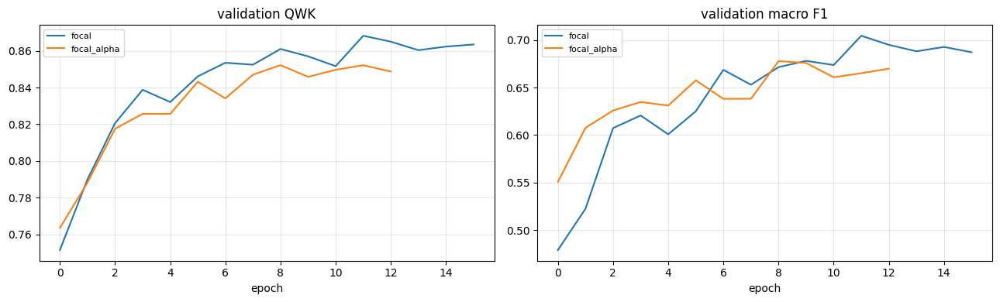

In [47]:
cfg4 = json.load(open(FINAL_DIR / 'final_manifest.json'))
print('5.4 config:', {k: v for k, v in cfg4.items() if k != 'alpha'})
h4 = json.load(open(FINAL_DIR / 'final_history.json'))

rows = []
for tag in cfg4['candidates']:
    p = np.load(FINAL_DIR / f'val_probs_{tag}.npy')
    yh = p.argmax(1)
    r = score(y_val, yh, tag)
    q = h4[tag]['val_qwk']
    r.update({'epochs run': len(q), 'best epoch': int(np.argmax(q)) + 1,
              'hit ceiling': len(q) == FINAL_MAX_EPOCHS})
    ref_t, ref_p = (y_val >= 2), (yh >= 2)
    tp, fn = int((ref_t & ref_p).sum()), int((ref_t & ~ref_p).sum())
    tn, fp = int((~ref_t & ~ref_p).sum()), int((~ref_t & ref_p).sum())
    r.update({'referable sens': tp / (tp + fn), 'referable spec': tn / (tn + fp), 'missed referrals': fn})
    rows.append(r)

fin = pd.DataFrame(rows).set_index('model')
print('\n5.4 final candidates (validation, %d images):' % len(y_val))
print(fin[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
           'referable sens', 'referable spec', 'missed referrals',
           'epochs run', 'best epoch', 'hit ceiling']].round(4).to_string())

for tag in cfg4['candidates']:
    yh = np.load(FINAL_DIR / f'val_probs_{tag}.npy').argmax(1)
    cm = pd.DataFrame(confusion_matrix(y_val, yh, labels=range(5)),
                      index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
    print(f'\nconfusion matrix - {tag}:'); print(cm.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for tag, hh in h4.items():
    axes[0].plot(hh['val_qwk'], label=tag); axes[1].plot(hh['val_macro_f1'], label=tag)
for ax, t in zip(axes, ['validation QWK', 'validation macro F1']):
    ax.set_title(t); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Plain focal loss is the final model.**

| Candidate | Accuracy | Macro F1 | QWK | Severe recall | Mild recall | Referable sensitivity | Missed referrals | Epochs | Best epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **focal** | **0.8499** | **0.7044** | **0.8682** | 0.556 | 0.330 | **0.877** | **99** | 16 | 12 |
| focal_alpha | 0.8192 | 0.6777 | 0.8522 | **0.611** | **0.421** | 0.824 | 142 | 13 | 9 |

Neither run reached the 30-epoch limit, so both stopped on their own.

**Adding class weights helped the rare grades but hurt overall.** `focal_alpha` found more Mild (37 of 88 against
29) and Severe (22 of 36 against 20), which is 10 more cases. But it lost 57 Moderate cases (464 of 640 against
521), and Moderate is 36% of the data.

**Referral settled the choice, and it agrees with QWK.** Referable means grades 2 to 4 (805 cases). Plain focal
misses **99**, and `focal_alpha` misses **142**, with almost the same specificity (0.931 against 0.938).
`focal_alpha` more often calls a Moderate eye Mild (60 against 30), and that sends a patient who needs referral
home. QWK, macro F1 and referral all point to plain focal.

**Macro F1 of 0.7044 is the highest so far** (section 4 ended at 0.6400).

## 5.5 Section 5: Decisions

| Decision | Setting | Reason |
|---|---|---|
| Learning-rate schedule | reduce-on-plateau (×0.3, patience 2), early stopping on validation QWK (patience 4), up to 30 epochs | QWK stalled at 0.836-0.843, then rose straight after the rate cut. The lead over fixed (0.003) is a tie, so the choice rests on this behaviour (5.1) |
| Cosine rejected | n/a | It plans for 20 epochs, but early stopping ended the run at 11, so it never reached its low-rate phase (5.1) |
| **Input size: 512 px** | 39 µm per pixel | QWK 0.8603 vs 0.8178 at 224, and Mild recall doubles (0.239 to 0.500). It costs 3.2× the time. 380 px is kept as the cheaper option (5.2) |
| **Loss: focal, gamma 2** | no class weights | QWK 0.8769 against 0.8603 for class weights, about twice the noise level (5.3) |
| Oversampling rejected | n/a | Same QWK as class weights, and it memorises the 167 repeated Severe images (train accuracy 0.918, validation 0.814) (5.3) |
| Focal with class weights rejected | `focal_alpha` | Missed 142 referable cases against 99, and lost 57 Moderate cases (5.4) |
| Report referral sensitivity | grades 2-4 counted as referable | A Mild case called Moderate still reaches a doctor, but a Moderate case called No_DR does not (5.4) |
| Kept from section 4 | EfficientNetV2-B0, top 50% unfrozen, lr 1e-4, `none` arm, batch 32 | Not re-tested |

**Final validation result (focal, best epoch):** accuracy 0.8499, macro F1 0.7044, **QWK 0.8682**, Severe
recall 0.5556 (20 of 36), Mild recall 0.3295 (29 of 88), referable sensitivity 0.877 (99 missed of 805),
specificity 0.931. Section 4 ended at QWK 0.8474 and macro F1 0.6400.

**What each step added (QWK):** plateau schedule +0.003 (a tie), 380 to 512 px +0.0125, and focal loss over
class weights +0.0166 in 5.3.

**Limitations to carry into the report**

1. **The same focal setup scored 0.8769 in 5.3 and 0.8682 in 5.4.** The 0.0087 gap is run-to-run noise (about
   0.008). We report 5.4's value, and gaps below 0.008 are read as ties.
2. **Severe and Mild recall are lower than in section 4** (Severe 0.722 to 0.556, Mild 0.364 to 0.330). The
   gains are in overall grading and referral, not in the rare grades. Both are small groups (36 and 88 images).
3. **Settings were tuned one step at a time** (schedule, then size, then loss), so combinations were not tested.
4. **Everything is a single run tuned on the validation set,** so the scores are slightly optimistic. The test
   set in section 6 gives the fair number.
5. **Only the `none` arm was tuned.** `clahe_lab` is tested again at the final setup in 6.2.

---
# 6. Model Evaluation and Performance Analysis

| Step | What we do | Why |
|---|---|---|
| 6.1 | Score the final model on the held-out test set, not just validation | Validation was used to pick the checkpoint, so its score alone is optimistic |
| 6.2 | Retrain the `clahe_lab` arm at the final settings, then test both arms on IDRiD (the outside dataset) | 4.5's `clahe_lab` run used the old settings (380px, 8 epochs). Comparing that to the new model would mix up several changes at once |
| 6.3 | Show Grad-CAM heatmaps, so we can see which part of the image the model is looking at | Checks the model is reading lesions, not a shortcut such as the DDR source difference |
| 6.4 | Pick a referral cut-off, and test scaling up rare grades before picking the top answer | The model ranks each grade well, but on raw probabilities a common grade often edges out a rare one for the top spot |
| 6.5 | Let the model abstain ("not sure") on hard cases, instead of forcing an answer | A screening tool can send an unsure case to a doctor rather than guess |
| 6.6 | Pull together the training curves, key numbers and figures for the report | One place with everything needed to write up the results |

loaded focal.weights.h5 | effnetv2b0 @50% 512px arm none


2026-09-15 09:39:20.271626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 09:39:20.445680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 09:39:21.556099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 09:39:21.751781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 09:39:22.999648: E external/local_xla/xla/stream_

predicted 1786 images in 41 s (44 img/s)

held-out performance vs the validation figure that selected the checkpoint:
                  accuracy  macro F1     QWK  Severe recall  Mild recall
model                                                                   
validation (5.4)    0.8499    0.7044  0.8682         0.5556       0.3295
internal test       0.8359    0.6690  0.8603         0.4848       0.3068
QWK change: -0.0079  | noise floor ~0.008

per-class report (internal test, 1786 images):
                  precision    recall  f1-score   support

           No_DR      0.891     0.936     0.913       893
            Mild      0.333     0.307     0.320        88
        Moderate      0.839     0.789     0.813       640
          Severe      0.444     0.485     0.464        33
Proliferative_DR      0.845     0.826     0.835       132

        accuracy                          0.836      1786
       macro avg      0.671     0.669     0.669      1786
    weighted avg      0.833     0.

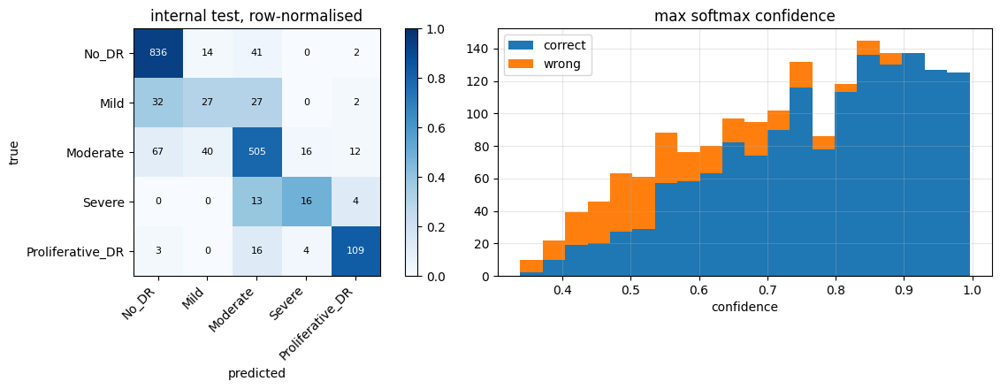

In [ ]:
# 6.1 Internal test evaluation

# get the final, honest score of the chosen model, on images it has never influenced in any way.

from sklearn.metrics import classification_report, roc_auc_score

TEST_DIR = CACHE / 'test'; TEST_DIR.mkdir(parents=True, exist_ok=True)
FINAL_TAG = 'focal'                      
FINAL_W   = FINAL_DIR / f'{FINAL_TAG}.weights.h5'
assert FINAL_W.exists(), f'{FINAL_W} missing - restore CACHE/final/ before running 6.0'

def load_final(img_size=S_PX, weights=FINAL_W):
    """Rebuild the 5.4 architecture and load its checkpoint. Nothing trains here."""
    keras.backend.clear_session()
    m, base = build_model(S_BACKBONE, img_size=img_size, trainable=False)
    base.trainable = True                
    m.load_weights(weights)
    return m

model = load_final()
print('loaded', FINAL_W.name, '|', S_BACKBONE, f'@{S_DEPTH:.0%}', f'{S_PX}px', 'arm', S_ARM)

test_ds, _ = make_ds(ddr_te, PROC / 'ddr', norm=S_ARM, img_size=S_PX)
y_test = ddr_te['diagnosis'].to_numpy('int32')
t0 = time.time()
p_test = model.predict(test_ds, verbose=0)
print('predicted %d images in %.0f s (%.0f img/s)'
      % (len(p_test), time.time() - t0, len(p_test) / (time.time() - t0)))
assert len(p_test) == len(y_test), 'prediction count does not match the test table'
yh_test = p_test.argmax(1)
np.save(TEST_DIR / f'test_probs_{FINAL_TAG}.npy', p_test)

row_test = score(y_test, yh_test, 'internal test')
row_val  = score(y_val, np.load(FINAL_DIR / f'val_probs_{FINAL_TAG}.npy').argmax(1), 'validation (5.4)')
cmp = pd.DataFrame([row_val, row_test]).set_index('model')
print('\nheld-out performance vs the validation figure that selected the checkpoint:')
print(cmp[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall']].round(4).to_string())
print('QWK change: %+.4f  | noise floor ~0.008' % (row_test['QWK'] - row_val['QWK']))

print('\nper-class report (internal test, %d images):' % len(y_test))
print(classification_report(y_test, yh_test, labels=range(5),
                            target_names=[LABELS[i] for i in range(5)],
                            digits=3, zero_division=0))

cm = pd.DataFrame(confusion_matrix(y_test, yh_test, labels=range(5)),
                  index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
print('confusion matrix (rows = true, columns = predicted):')
print(cm.to_string())
print('\nrow-normalised (%), i.e. per-class recall spread across predictions:')
print((cm.div(cm.sum(1), axis=0) * 100).round(1).to_string())

try:
    auc_ovr = {LABELS[c]: roc_auc_score((y_test == c).astype(int), p_test[:, c]) for c in range(5)}
    print('\none-vs-rest ROC AUC per grade:', {k: round(v, 4) for k, v in auc_ovr.items()})
    print('macro AUC: %.4f' % np.mean(list(auc_ovr.values())))
except ValueError as e:
    print('AUC skipped:', e)

ref_t, ref_p = (y_test >= 2), (yh_test >= 2)
tp, fn = int((ref_t & ref_p).sum()), int((ref_t & ~ref_p).sum())
tn, fp = int((~ref_t & ~ref_p).sum()), int((~ref_t & ref_p).sum())
print('\nreferable collapse (grades 2-4 vs 0-1), at the default argmax:')
print(pd.DataFrame([[tn, fp], [fn, tp]], index=['true non-referable', 'true referable'],
                   columns=['pred non-referable', 'pred referable']).to_string())
print('sensitivity %.4f | specificity %.4f | missed %d of %d referable | PPV %.4f'
      % (tp / (tp + fn), tn / (tn + fp), fn, tp + fn, tp / (tp + fp)))
p_ref = p_test[:, 2:].sum(1)
print('referable AUC (threshold-free): %.4f' % roc_auc_score(ref_t.astype(int), p_ref))
np.save(TEST_DIR / 'test_labels.npy', y_test)

off = yh_test - y_test
print('\nerror distance on the ICDR scale:')
print(pd.Series(off).value_counts().sort_index()
        .rename(lambda d: f'{d:+d} grade' if d else 'correct').to_string())
print('within one grade: %.1f%% | two or more: %.1f%%'
      % (100 * (np.abs(off) <= 1).mean(), 100 * (np.abs(off) >= 2).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].imshow(cm.div(cm.sum(1), axis=0), cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels([LABELS[i] for i in range(5)], rotation=45, ha='right')
axes[0].set_yticks(range(5)); axes[0].set_yticklabels([LABELS[i] for i in range(5)])
axes[0].set_title('internal test, row-normalised'); axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, cm.iloc[i, j], ha='center', va='center', fontsize=8,
                     color='white' if cm.iloc[i, j] / cm.iloc[i].sum() > 0.5 else 'black')
plt.colorbar(im, ax=axes[0], fraction=0.046)
conf = p_test.max(1)
axes[1].hist([conf[yh_test == y_test], conf[yh_test != y_test]], bins=20, stacked=True,
             label=['correct', 'wrong'])
axes[1].set_title('max softmax confidence'); axes[1].set_xlabel('confidence'); axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. The test score is close to validation, so the model transfers well.**

| Set | Accuracy | Macro F1 | QWK | Severe recall | Mild recall |
|---|---:|---:|---:|---:|---:|
| validation (picked the checkpoint) | 0.8499 | 0.7044 | 0.8682 | 0.556 | 0.330 |
| **internal test (held out)** | 0.8359 | 0.6690 | **0.8603** | 0.485 | 0.307 |

QWK drops by only 0.0079, inside the noise level (about 0.008). So the checkpoint was not overfit to
validation. Inference runs at 44 img/s, the same speed limit as training (input-bound).

**Per grade:**

| Grade | Precision | Recall | F1 | AUC | Images |
|---|---:|---:|---:|---:|---:|
| No_DR | 0.891 | 0.936 | 0.913 | 0.968 | 893 |
| Mild | 0.333 | 0.307 | 0.320 | 0.881 | 88 |
| Moderate | 0.839 | 0.789 | 0.813 | 0.941 | 640 |
| Severe | 0.444 | 0.485 | 0.464 | 0.961 | 33 |
| PDR | 0.845 | 0.826 | 0.835 | 0.991 | 132 |

Macro AUC 0.9485. **AUC is much higher than recall for Mild and Severe** (0.881 vs 0.307, 0.961 vs 0.485). So
the model ranks these grades well, but they are rarely its single top answer. Mild is confused evenly with
No_DR (36.4%) and Moderate (30.7%), and 39.4% of Severe images are called Moderate.

**Referral (grades 2-4 treated as one group):** sensitivity 0.863, specificity 0.927, PPV 0.906, referable AUC
0.964. **110 of 805 referable cases are missed.**

**92.0% of mistakes are within one grade.** Only 7 of 1,786 images (0.4%) are off by 3 or 4 grades. This is why
QWK (0.860) reads much better than macro F1 (0.669): QWK barely charges for near mistakes.

In [ ]:
# 6.2.0
ALT_ARM = 'clahe_lab'
alt_out = FINAL_DIR / f'{FINAL_TAG}_{ALT_ARM}.weights.h5'

if alt_out.exists():
    print('matched clahe_lab checkpoint already present:', alt_out.name)
else:
    alt_head = PILOT_DIR / f'head_{S_BACKBONE}_{ALT_ARM}.weights.h5'
    assert alt_head.exists(), f'{alt_head.name} missing - it was cached in 4.5'
    tr, _ = make_ds(ddr_tr, PROC / 'ddr', training=True, norm=ALT_ARM, img_size=S_PX)
    va, _ = make_ds(ddr_va, PROC / 'ddr', norm=ALT_ARM, img_size=S_PX)

    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    m_alt, base_alt = build_model(S_BACKBONE, img_size=S_PX, trainable=False)
    m_alt.load_weights(alt_head)
    cut = int(len(base_alt.layers) * (1 - S_DEPTH))
    base_alt.trainable = True
    for l in base_alt.layers[:cut]:
        l.trainable = False
    m_alt.compile(optimizer=keras.optimizers.Adam(S_LR), loss=sparse_focal(), metrics=['accuracy'])

    cbs = [QWKCheckpoint(va, y_val, alt_out),
           keras.callbacks.ReduceLROnPlateau(monitor='val_qwk', mode='max', factor=RLR_FACTOR,
                                             patience=RLR_PATIENCE, min_lr=1e-6, verbose=1),
           keras.callbacks.EarlyStopping(monitor='val_qwk', mode='max', patience=ES_PATIENCE,
                                         restore_best_weights=True, verbose=1)]
    print(f'=== {ALT_ARM} arm at the final configuration | {S_PX} px | focal | max {FINAL_MAX_EPOCHS} ===')
    t0 = time.time()
    h_alt = m_alt.fit(tr, validation_data=va, epochs=FINAL_MAX_EPOCHS, shuffle=False,
                      verbose=2, callbacks=cbs)
    m_alt.load_weights(alt_out)
    p_alt_val = m_alt.predict(va, verbose=0)
    np.save(FINAL_DIR / f'val_probs_{FINAL_TAG}_{ALT_ARM}.npy', p_alt_val)
    json.dump({k: [float(x) for x in v] for k, v in h_alt.history.items()},
              open(FINAL_DIR / f'history_{FINAL_TAG}_{ALT_ARM}.json', 'w'))
    r_alt_val = score(y_val, p_alt_val.argmax(1), f'{ALT_ARM} (validation)')
    r_none_val = score(y_val, np.load(FINAL_DIR / f'val_probs_{FINAL_TAG}.npy').argmax(1),
                       'none (validation, 5.4)')
    print('\nin-domain arm comparison at the final configuration:')
    print(pd.DataFrame([r_none_val, r_alt_val]).set_index('model')[
        ['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall']].round(4).to_string())
    print('epochs %d, best %d, %.1f min'
          % (len(h_alt.history['loss']), int(np.argmax(h_alt.history['val_qwk'])) + 1,
             (time.time() - t0) / 60))
    del m_alt

=== clahe_lab arm at the final configuration | 512 px | focal | max 30 ===
Epoch 1/30
      val QWK 0.7337 | macro F1 0.4543  <- saved
280/280 - 243s - 866ms/step - accuracy: 0.7133 - loss: 0.3695 - val_accuracy: 0.7623 - val_loss: 0.2952 - val_qwk: 0.7337 - val_macro_f1: 0.4543 - learning_rate: 1.0000e-04
Epoch 2/30
      val QWK 0.8237 | macro F1 0.5386  <- saved
280/280 - 236s - 842ms/step - accuracy: 0.7776 - loss: 0.2730 - val_accuracy: 0.8203 - val_loss: 0.2417 - val_qwk: 0.8237 - val_macro_f1: 0.5386 - learning_rate: 1.0000e-04
Epoch 3/30
      val QWK 0.8368 | macro F1 0.5921  <- saved
280/280 - 117s - 416ms/step - accuracy: 0.8024 - loss: 0.2450 - val_accuracy: 0.8225 - val_loss: 0.2288 - val_qwk: 0.8368 - val_macro_f1: 0.5921 - learning_rate: 1.0000e-04
Epoch 4/30
      val QWK 0.8349 | macro F1 0.6274
280/280 - 117s - 419ms/step - accuracy: 0.8140 - loss: 0.2243 - val_accuracy: 0.8276 - val_loss: 0.2265 - val_qwk: 0.8349 - val_macro_f1: 0.6274 - learning_rate: 1.0000e-04
Epo

IDRiD external test: 455 images | grade counts {'No_DR': 118, 'Mild': 23, 'Moderate': 164, 'Severe': 90, 'Proliferative_DR': 60}


2026-09-15 10:08:55.689791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 10:08:55.829741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 10:08:56.702715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 10:08:56.853142: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 10:08:57.772075: E external/local_xla/xla/stream_


internal vs external (the generalisation test):
                   accuracy  macro F1     QWK  Severe recall  Mild recall  referable sens  referable spec  referable AUC  within 1 grade
model                                                                                                                                   
DDR internal test    0.8359    0.6690  0.8603         0.4848       0.3068          0.8634          0.9266         0.9635          0.9199
IDRiD (none)         0.6418    0.5637  0.7698         0.4333       0.2174          0.9745          0.6312         0.9662          0.8879
IDRiD (clahe_lab)    0.6374    0.5317  0.7731         0.2222       0.2609          0.9745          0.7376         0.9793          0.8879

per-class report (IDRiD):
                  precision    recall  f1-score   support

           No_DR      0.938     0.636     0.758       118
            Mild      0.294     0.217     0.250        23
        Moderate      0.566     0.866     0.684       164
      

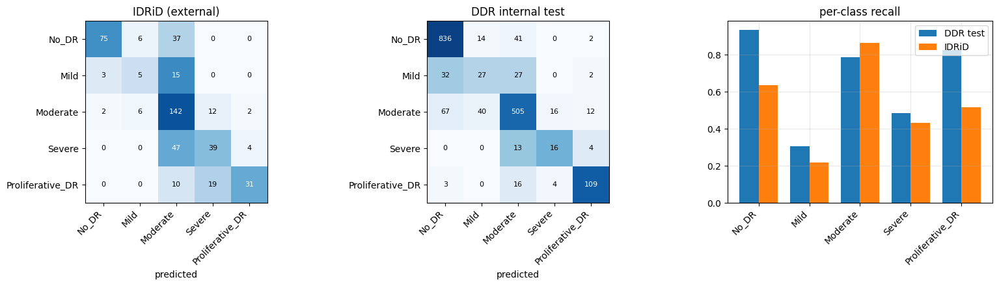

In [ ]:
# 6.2 External test: IDRiD
# how does the model do on images from a different hospital, camera and colour profile that it has never seen ?
XT_DIR = CACHE / 'external'; EXT_DIR.mkdir(parents=True, exist_ok=True)

def evaluate_set(m, ds, y_true, tag):
    p = m.predict(ds, verbose=0)
    assert len(p) == len(y_true), f'{tag}: prediction count does not match the table'
    yh = p.argmax(1)
    r = score(y_true, yh, tag)
    ref_t, ref_p = (y_true >= 2), (yh >= 2)
    tp, fn = int((ref_t & ref_p).sum()), int((ref_t & ~ref_p).sum())
    tn, fp = int((~ref_t & ~ref_p).sum()), int((~ref_t & ref_p).sum())
    r.update({'referable sens': tp / (tp + fn), 'referable spec': tn / (tn + fp), 'missed referrals': fn,
              'referable AUC': roc_auc_score(ref_t.astype(int), p[:, 2:].sum(1)),
              'within 1 grade': float((np.abs(yh - y_true) <= 1).mean())})
    return r, p, yh

ext_ds, _ = make_ds(iext, PROC / 'idrid', ext='.jpg', norm=S_ARM, img_size=S_PX)
y_ext = iext['diagnosis'].to_numpy('int32')
print('IDRiD external test: %d images | grade counts %s'
      % (len(y_ext), {LABELS[k]: int(v) for k, v in pd.Series(y_ext).value_counts().sort_index().items()}))

r_ext, p_ext, yh_ext = evaluate_set(model, ext_ds, y_ext, f'IDRiD ({S_ARM})')
np.save(EXT_DIR / f'ext_probs_{FINAL_TAG}_{S_ARM}.npy', p_ext)
np.save(EXT_DIR / 'ext_labels.npy', y_ext)

alt_w = FINAL_DIR / 'focal_clahe_lab.weights.h5'
rows_ext = [r_ext]
if alt_w.exists():
    alt_ds, _ = make_ds(iext, PROC / 'idrid', ext='.jpg', norm='clahe_lab', img_size=S_PX)
    alt_model = load_final(weights=alt_w)
    r_alt, p_alt, _ = evaluate_set(alt_model, alt_ds, y_ext, 'IDRiD (clahe_lab)')
    rows_ext.append(r_alt)
    np.save(EXT_DIR / f'ext_probs_{FINAL_TAG}_clahe_lab.npy', p_alt)
    del alt_model
else:
    print('\nclahe_lab arm skipped: no matched checkpoint at the final configuration')

y_test_l = np.load(TEST_DIR / 'test_labels.npy')
p_test_l = np.load(TEST_DIR / f'test_probs_{FINAL_TAG}.npy')
r_int, _, _ = evaluate_set.__wrapped__ if False else (None, None, None)
yh_int = p_test_l.argmax(1)
r_int = score(y_test_l, yh_int, 'DDR internal test')
ref_t, ref_p = (y_test_l >= 2), (yh_int >= 2)
tp, fn = int((ref_t & ref_p).sum()), int((ref_t & ~ref_p).sum())
tn, fp = int((~ref_t & ~ref_p).sum()), int((~ref_t & ref_p).sum())
r_int.update({'referable sens': tp / (tp + fn), 'referable spec': tn / (tn + fp), 'missed referrals': fn,
              'referable AUC': roc_auc_score(ref_t.astype(int), p_test_l[:, 2:].sum(1)),
              'within 1 grade': float((np.abs(yh_int - y_test_l) <= 1).mean())})

ext = pd.DataFrame([r_int] + rows_ext).set_index('model')
print('\ninternal vs external (the generalisation test):')
print(ext[['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall',
           'referable sens', 'referable spec', 'referable AUC', 'within 1 grade']].round(4).to_string())

print('\nper-class report (IDRiD):')
print(classification_report(y_ext, yh_ext, labels=range(5),
                            target_names=[LABELS[i] for i in range(5)], digits=3, zero_division=0))
cm_e = pd.DataFrame(confusion_matrix(y_ext, yh_ext, labels=range(5)),
                    index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)])
print('confusion matrix - IDRiD:'); print(cm_e.to_string())
print('\nrow-normalised (%):'); print((cm_e.div(cm_e.sum(1), axis=0) * 100).round(1).to_string())

rec = pd.DataFrame({
    'DDR test recall': [recall_score(y_test_l, yh_int, labels=[c], average='macro', zero_division=0) for c in range(5)],
    'IDRiD recall':    [recall_score(y_ext, yh_ext, labels=[c], average='macro', zero_division=0) for c in range(5)],
    'DDR n':   [int((y_test_l == c).sum()) for c in range(5)],
    'IDRiD n': [int((y_ext == c).sum()) for c in range(5)]}, index=[LABELS[i] for i in range(5)])
rec['recall change'] = (rec['IDRiD recall'] - rec['DDR test recall']).round(4)
print('\nper-class recall, internal vs external (recall is prevalence-independent; accuracy is not):')
print(rec.round(4).to_string())

auc_e = {}
for c in range(5):
    if (y_ext == c).sum() and (y_ext != c).sum():
        auc_e[LABELS[c]] = roc_auc_score((y_ext == c).astype(int), p_ext[:, c])
print('\none-vs-rest AUC - IDRiD:', {k: round(v, 4) for k, v in auc_e.items()})
print('macro AUC: IDRiD %.4f vs DDR test %.4f'
      % (np.mean(list(auc_e.values())),
         np.mean([roc_auc_score((y_test_l == c).astype(int), p_test_l[:, c]) for c in range(5)])))

print('\nmean max-softmax confidence: DDR test %.4f | IDRiD %.4f'
      % (p_test_l.max(1).mean(), p_ext.max(1).mean()))
print('mean confidence when wrong: DDR %.4f | IDRiD %.4f'
      % (p_test_l.max(1)[yh_int != y_test_l].mean(), p_ext.max(1)[yh_ext != y_ext].mean()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (cmx, ttl) in zip(axes[:2], [(cm_e, 'IDRiD (external)'),
    (pd.DataFrame(confusion_matrix(y_test_l, yh_int, labels=range(5)),
                  index=[LABELS[i] for i in range(5)], columns=[LABELS[i] for i in range(5)]),
     'DDR internal test')]):
    ax.imshow(cmx.div(cmx.sum(1), axis=0), cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(5)); ax.set_xticklabels([LABELS[i] for i in range(5)], rotation=45, ha='right')
    ax.set_yticks(range(5)); ax.set_yticklabels([LABELS[i] for i in range(5)])
    ax.set_title(ttl); ax.set_xlabel('predicted')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cmx.iloc[i, j], ha='center', va='center', fontsize=8,
                    color='white' if cmx.iloc[i, j] / max(cmx.iloc[i].sum(), 1) > 0.5 else 'black')
x = np.arange(5); w = 0.38
axes[2].bar(x - w/2, rec['DDR test recall'], w, label='DDR test')
axes[2].bar(x + w/2, rec['IDRiD recall'], w, label='IDRiD')
axes[2].set_xticks(x); axes[2].set_xticklabels([LABELS[i] for i in range(5)], rotation=45, ha='right')
axes[2].set_title('per-class recall'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. `none` is clearly better than `clahe_lab`, and IDRiD shows a real drop.**

**6.2.0: `clahe_lab` retrained fairly, at the same settings as `none`.**

| Arm | Accuracy | Macro F1 | QWK | Severe recall | Mild recall |
|---|---:|---:|---:|---:|---:|
| **none** | 0.8499 | **0.7044** | **0.8682** | **0.556** | **0.330** |
| clahe_lab | 0.8225 | 0.5921 | 0.8368 | 0.167 | 0.148 |

At the same settings, `clahe_lab` is worse, especially on the rare grades. In 4.5 the two arms looked tied,
but that was at 380 px with class weights. `none` is used for everything below.

**6.2: DDR test vs IDRiD, the real outside test.**

| Set | Accuracy | Macro F1 | QWK | Referable sensitivity | Referable specificity | Macro AUC |
|---|---:|---:|---:|---:|---:|---:|
| DDR internal test | 0.8359 | 0.6690 | **0.8603** | 0.863 | 0.927 | 0.9485 |
| **IDRiD (none)** | 0.6418 | 0.5637 | **0.7698** | **0.975** | 0.631 | 0.8825 |

Accuracy and QWK both fall on IDRiD, as expected from the colour, scale and disease-mix differences found in
sections 1 to 3.

**Referral sensitivity goes up, not down (0.863 to 0.975), but at a real cost.** The model over-refers on
IDRiD: specificity drops from 0.927 to 0.631, so many healthy eyes are wrongly flagged. It misses fewer
referable cases, but wastes more doctor time on false alarms.

**Recall drops hardest on No_DR and PDR** (No_DR 0.936 to 0.636, PDR 0.826 to 0.517), and Moderate is the only
grade that improves (0.789 to 0.866). The confusion matrix shows why: 31.4% of true No_DR images are called
Moderate, and 52.2% of true Severe images are called Moderate too. The model is pulled toward the middle
grade on unfamiliar images.

**Ranking quality also drops** (macro AUC 0.9485 to 0.8825), so this is not only a threshold problem.
Confidence drops too (mean top score 0.744 to 0.676), and wrong answers on IDRiD are made with more confidence
than wrong answers on DDR (0.629 against 0.576), so the model is less able to flag its own mistakes on new
data.

feature map: (None, 16, 16, 1280) -> each cell covers 32 px of input
CAM path verified against the full model

Correct cases, one per grade:
                   image              true              pred   No_DR    Mild  Moderate  Severe  Proliferative_DR  margin  inner    rim  outside  hot %
#                                                                                                                                                     
1  20170331092136468.jpg             No_DR             No_DR  0.9944  0.0020    0.0036  0.0000            0.0000  0.9908  0.950  0.026    0.024  5.154
2       007-2852-100.jpg              Mild              Mild  0.0181  0.7694    0.2053  0.0068            0.0003  0.5640  0.944  0.028    0.028  1.442
3       007-3368-200.jpg          Moderate          Moderate  0.0038  0.0010    0.9553  0.0122            0.0277  0.9276  0.836  0.055    0.108  3.389
4       007-6011-300.jpg            Severe            Severe  0.0000  0.0001    0.0213  0.9719          

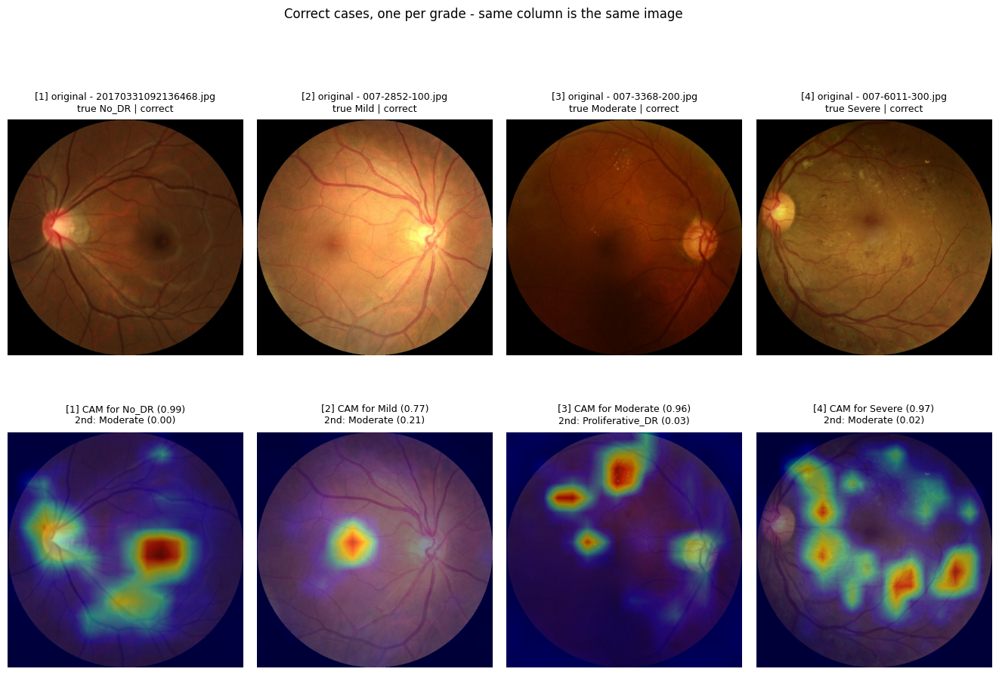

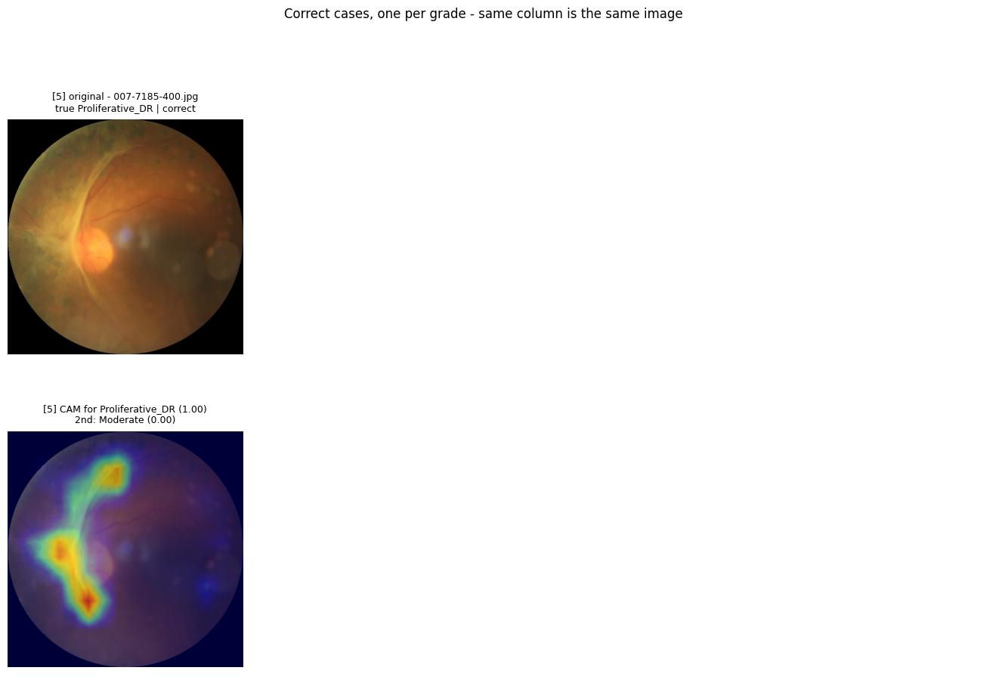


Failure cases:
                   image      true      pred   No_DR    Mild  Moderate  Severe  Proliferative_DR  margin  inner    rim  outside  hot %
#                                                                                                                                     
1       007-2015-100.jpg      Mild     No_DR  0.8848  0.0728    0.0424  0.0000            0.0000  0.8120  0.878  0.071    0.051  3.256
2  20170617214243173.jpg  Moderate     No_DR  0.8904  0.0223    0.0870  0.0002            0.0000  0.8034  0.925  0.041    0.035  5.634
3       007-4963-300.jpg    Severe  Moderate  0.0117  0.0062    0.8686  0.1048            0.0086  0.7638  0.826  0.047    0.127  5.505
4       007-2606-100.jpg     No_DR  Moderate  0.0980  0.0028    0.8483  0.0008            0.0502  0.7503  0.731  0.168    0.101  0.628


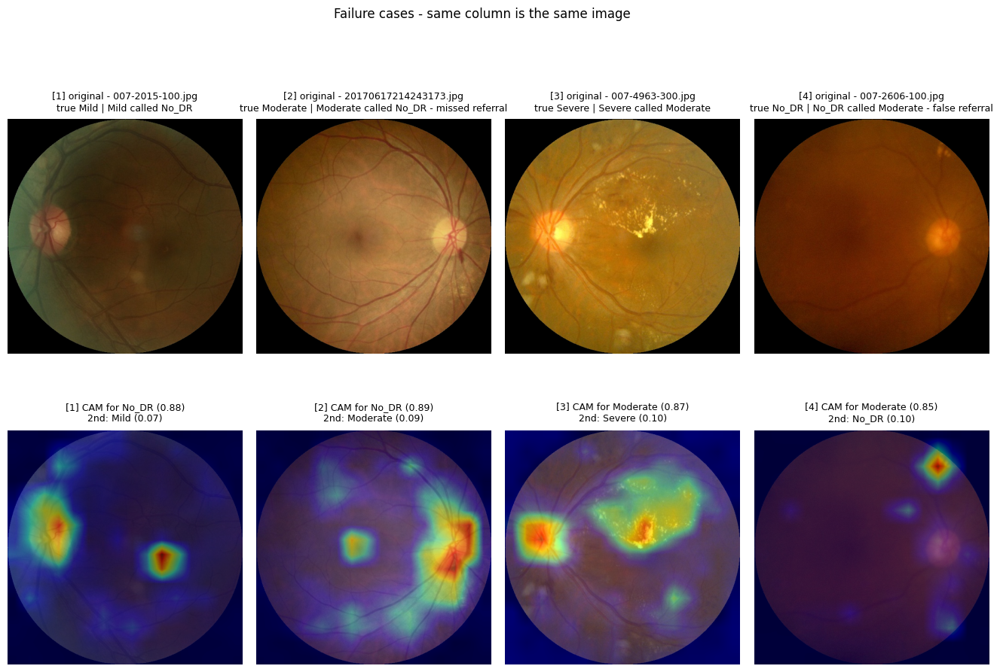


IDRiD external test:
           image      true      pred   No_DR    Mild  Moderate  Severe  Proliferative_DR  margin  inner    rim  outside  hot %
#                                                                                                                             
1      IDRiD_144     No_DR     No_DR  0.9645  0.0199    0.0155  0.0001            0.0001  0.9446  0.933  0.036    0.031  9.340
2      IDRiD_294  Moderate  Moderate  0.0130  0.0236    0.9345  0.0095            0.0195  0.9109  0.929  0.025    0.046  2.289
3      IDRiD_271    Severe    Severe  0.0000  0.0001    0.0457  0.9191            0.0350  0.8734  0.920  0.058    0.022  6.251
4  IDRiD_069test     No_DR  Moderate  0.0035  0.0219    0.9331  0.0312            0.0102  0.9019  0.828  0.079    0.094  1.293


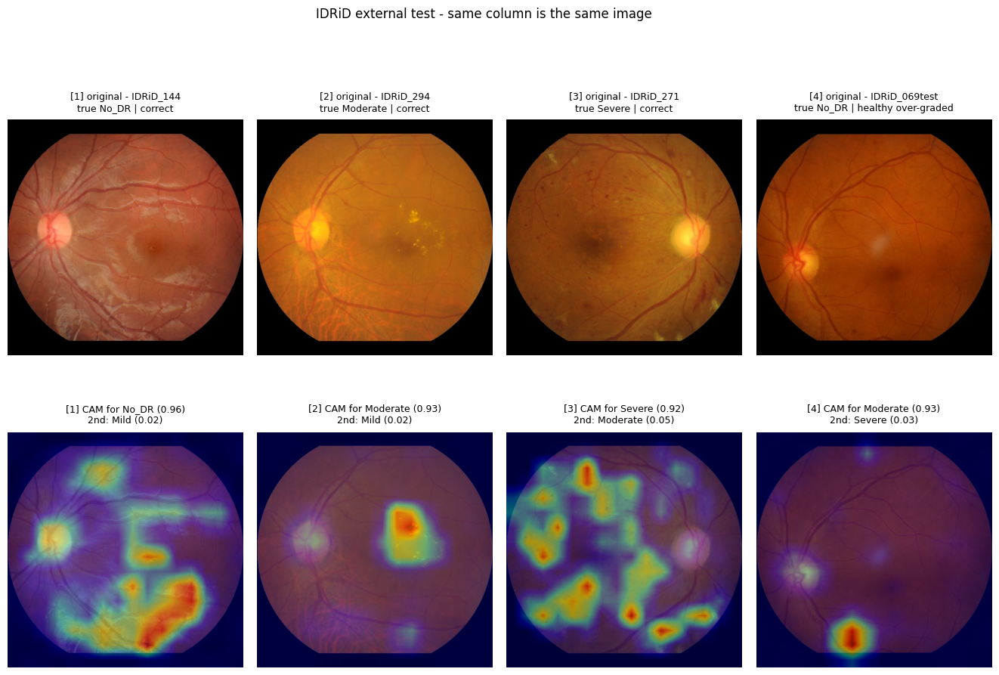


outside-mask mass should be ~0: the surround is pure black after 2.3 and carries no information.
a high rim share would mean the model keys on the mask boundary rather than on pathology.


In [ ]:
# 6.3 Grad-CAM: what the model is looking at

# check where in the image the model is looking, not just what grade it predicts.
CAM_DIR = CACHE / 'gradcam'; CAM_DIR.mkdir(parents=True, exist_ok=True)
CAM_ALPHA = 0.45

_names = [l.name for l in model.layers]
_base  = model.get_layer(S_BACKBONE if S_BACKBONE in _names else
                         [n for n in _names if 'efficientnet' in n or 'resnet' in n][0])
feat_model = keras.Model(_base.input, _base.output, name='features')
gap_layer  = [l for l in model.layers if 'GlobalAverage' in type(l).__name__][0]
head_layer = model.layers[-1]
prep_layer = model.get_layer('preprocess') if 'preprocess' in _names else None
print('feature map:', _base.output_shape, '-> each cell covers %d px of input'
      % (S_PX // _base.output_shape[1]))

def gradcam(x, cls=None):
    """Weight each feature channel by how much raising it would raise the class score,
    sum, keep the positive part. `cls=None` explains the predicted grade; any other class
    explains what the model weighed toward that grade instead."""
    xt = tf.constant(x, tf.float32)
    with tf.GradientTape() as tape:
        z = prep_layer(xt) if prep_layer is not None else xt
        conv = feat_model(z, training=False)
        tape.watch(conv)
        preds = head_layer(gap_layer(conv))
        c = tf.argmax(preds, axis=1) if cls is None else tf.fill([tf.shape(preds)[0]], cls)
        score = tf.gather(preds, c, axis=1, batch_dims=1)
    g = tape.gradient(score, conv)
    w = tf.reduce_mean(g, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(w * conv, -1))
    cam = cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)
    return cam.numpy(), preds.numpy()

_probe = np.stack([evaluate_path(cv2.imread(str(PROC / 'ddr' / n)), img_size=S_PX, norm=S_ARM)[:, :, ::-1]
                   for n in ddr_te['id_code'].head(4)]).astype('float32')
_cam, _pr = gradcam(_probe)
assert np.allclose(_pr, model.predict(_probe, verbose=0), atol=1e-4), 'CAM head path diverges from the model'
print('CAM path verified against the full model')

def cam_stats(cam_small, img):
    cam = cv2.resize(cam_small, (S_PX, S_PX), interpolation=cv2.INTER_LINEAR)
    m   = circ_mask(img)
    inner = cv2.erode(m.astype(np.uint8), np.ones((31, 31), np.uint8)) == 1
    rim   = m & ~inner
    tot   = cam.sum() + 1e-8
    return {'inner': float(cam[~m | True][inner].sum() / tot) if False else float(cam[inner].sum() / tot),
            'rim': float(cam[rim].sum() / tot),
            'outside': float(cam[~m].sum() / tot),
            'hot %': float(100 * (cam > 0.5).mean())}

def run_cases(cases, folder, ext, title, shown=4):
    """cases: list of (image_id, true_class, label_for_the_panel). Plots `shown` per figure."""
    rows, panel = [], []
    for k, (name, t, why) in enumerate(cases, 1):
        img = evaluate_path(cv2.imread(str(folder / f'{name}{ext}')), img_size=S_PX, norm=S_ARM)
        cam, pr = gradcam(img[:, :, ::-1][None].astype('float32'))
        pr = pr[0]; st = cam_stats(cam[0], img); top2 = np.argsort(-pr)[:2]
        rows.append({'#': k, 'image': name, 'true': LABELS[t], 'pred': LABELS[int(top2[0])],
                     **{LABELS[c]: round(float(pr[c]), 4) for c in range(5)},
                     'margin': round(float(pr[top2[0]] - pr[top2[1]]), 4),
                     **{kk: round(v, 3) for kk, v in st.items()}, 'case': why})
        panel.append((k, name, img, cam[0], pr, t, why))

    print(f'\n{title}:')
    print(pd.DataFrame(rows).set_index('#')[
        ['image', 'true', 'pred', 'No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative_DR',
         'margin', 'inner', 'rim', 'outside', 'hot %']].to_string())

    for start in range(0, len(panel), shown):
        chunk = panel[start:start + shown]
        fig, axes = plt.subplots(2, shown, figsize=(4.2 * shown, 9.2))
        for col in range(shown):
            if col < len(chunk):
                k, name, img, cam, pr, t, why = chunk[col]
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                big = cv2.resize(cam, (S_PX, S_PX), interpolation=cv2.INTER_LINEAR)
                top2 = np.argsort(-pr)[:2]
                axes[0, col].imshow(rgb)
                axes[0, col].set_title(f'[{k}] original - {name}\ntrue {LABELS[t]} | {why}',
                                       fontsize=9, pad=8)
                axes[1, col].imshow(rgb); axes[1, col].imshow(big, cmap='jet', alpha=CAM_ALPHA)
                axes[1, col].set_title(f'[{k}] CAM for {LABELS[int(top2[0])]} ({pr[top2[0]]:.2f})\n'
                                       f'2nd: {LABELS[int(top2[1])]} ({pr[top2[1]]:.2f})',
                                       fontsize=9, pad=8)
            axes[0, col].axis('off'); axes[1, col].axis('off')
        fig.suptitle(f'{title} - same column is the same image', fontsize=12, y=0.99)
        plt.subplots_adjust(hspace=0.18, wspace=0.06, top=0.85, bottom=0.02)
        plt.show()
    return rows

y_t  = np.load(TEST_DIR / 'test_labels.npy')
p_t  = np.load(TEST_DIR / f'test_probs_{FINAL_TAG}.npy')
yh_t = p_t.argmax(1); conf_t = p_t.max(1); ids = ddr_te['id_code'].to_numpy()

cases_a = []
for c in range(5):
    sel = np.where((y_t == c) & (yh_t == c))[0]
    if len(sel):
        cases_a.append((ids[sel[np.argmax(conf_t[sel])]], c, 'correct'))
rows_a = run_cases(cases_a, PROC / 'ddr', '', 'Correct cases, one per grade')

cases_b = []
for true_c, pred_c, why in [(1, 0, 'Mild called No_DR'),
                            (2, 0, 'Moderate called No_DR - missed referral'),
                            (3, 2, 'Severe called Moderate'),
                            (0, 2, 'No_DR called Moderate - false referral')]:
    sel = np.where((y_t == true_c) & (yh_t == pred_c))[0]
    if len(sel):
        cases_b.append((ids[sel[np.argmax(conf_t[sel])]], true_c, why))
rows_b = run_cases(cases_b, PROC / 'ddr', '', 'Failure cases')

y_e  = np.load(EXT_DIR / 'ext_labels.npy')
p_e  = np.load(EXT_DIR / f'ext_probs_{FINAL_TAG}_{S_ARM}.npy')
yh_e = p_e.argmax(1); eids = iext['id_code'].to_numpy()
cases_c = []
for c, why in [(0, 'correct'), (2, 'correct'), (3, 'correct')]:
    sel = np.where((y_e == c) & (yh_e == c))[0]
    if len(sel):
        cases_c.append((eids[sel[np.argmax(p_e.max(1)[sel])]], c, why))
sel = np.where((y_e == 0) & (yh_e == 2))[0]
if len(sel):
    cases_c.append((eids[sel[np.argmax(p_e.max(1)[sel])]], 0, 'healthy over-graded'))
rows_c = run_cases(cases_c, PROC / 'idrid', '.jpg', 'IDRiD external test')

print('\noutside-mask mass should be ~0: the surround is pure black after 2.3 and carries no information.')
print('a high rim share would mean the model keys on the mask boundary rather than on pathology.')

**Result. The model looks inside the retina, on both DDR and IDRiD.**

| Group | inner (avg) | rim (avg) | outside (avg) |
|---|---:|---:|---:|
| Correct, DDR (5 cases) | 0.936 | 0.026 | 0.034 |
| Failures, DDR (4 cases) | 0.840 | 0.082 | 0.079 |
| IDRiD (4 cases) | 0.903 | 0.050 | 0.048 |

Across all 13 cases, at least 82.6% of the heatmap sits inside the retina, and outside the mask (pure black)
never exceeds 12.7%. So the model is not keying on the mask edge or the background, which is what a shortcut
would look like.

**Correct cases are confident and focused.** All 5 have a margin above 0.56 between the top two grades, and
inner attention of 0.836 to 0.990.

**Failures are less focused, not looking outside.** The two missed referrals (Mild and Moderate called No_DR)
have high confidence in the wrong answer (0.88 and 0.89) but still put 88-93% of attention inside the retina.
So these are not shortcut failures. The model looked at the right place and still misjudged the grade. The
false alarm (No_DR called Moderate) is the least focused case (73% inner, only 0.628% "hot" area), suggesting
a weak, spread-out signal rather than a clear wrong lesion.

**The same pattern holds on IDRiD.** The one wrong case (No_DR called Moderate, 82.8% inner) looks like the DDR
false alarm: low hot-area share (1.3%) and a smaller margin (0.90 against 0.91-0.94 for the correct cases).

referral threshold sweep on VALIDATION (1792 images, 805 referable):
           sensitivity  specificity     PPV     NPV  missed  false referrals  referred (%)
threshold                                                                                 
0.05            0.9963       0.2715  0.5273  0.9889       3              719       84.8772
0.10            0.9901       0.5117  0.6231  0.9844       8              482       71.3728
0.15            0.9739       0.6727  0.7082  0.9693      21              323       61.7746
0.20            0.9640       0.7508  0.7593  0.9623      29              246       57.0312
0.25            0.9516       0.8156  0.8080  0.9538      39              182       52.9018
0.30            0.9354       0.8652  0.8499  0.9426      52              133       49.4420
0.35            0.9168       0.8936  0.8754  0.9294      67              105       47.0424
0.40            0.8981       0.9220  0.9038  0.9173      82               77       44.6429
0.45            0.882

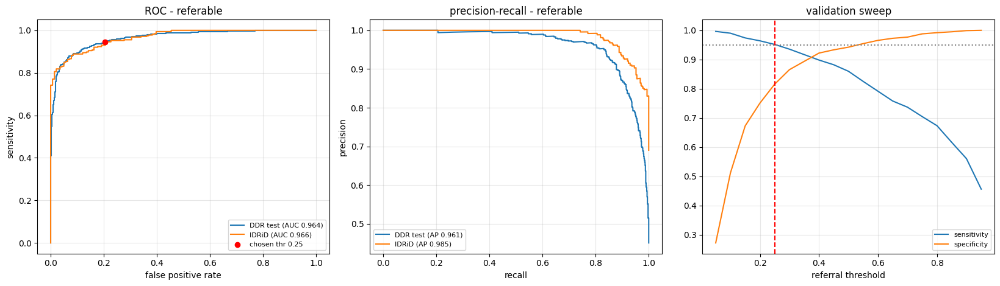


macro F1 objective: start 0.7044
  weights [0.632 1.    1.    1.    0.632] -> 0.7062 (round 2)

QWK objective: start 0.8682
  weights [0.795 0.795 1.    1.26  0.502] -> 0.8735 (round 2)

Mild boost in isolation (validation):
      1x  Mild recall 0.3295  Mild precision 0.4203  macro F1 0.7044  QWK 0.8682  acc 0.8499
      3x  Mild recall 0.7273  Mild precision 0.2078  macro F1 0.6773  QWK 0.8496  acc 0.7762
      5x  Mild recall 0.8068  Mild precision 0.1476  macro F1 0.6428  QWK 0.8289  acc 0.7003
     10x  Mild recall 0.9318  Mild precision 0.1120  macro F1 0.5933  QWK 0.7831  acc 0.5820
     20x  Mild recall 0.9773  Mild precision 0.0859  macro F1 0.5303  QWK 0.7211  acc 0.4487
     35x  Mild recall 1.0000  Mild precision 0.0759  macro F1 0.4859  QWK 0.6702  acc 0.3689
     50x  Mild recall 1.0000  Mild precision 0.0702  macro F1 0.4530  QWK 0.6355  acc 0.3225

per-class weighting, fitted on validation and applied unchanged:
                        accuracy  macro F1     QWK  Sever

In [ ]:
# 6.4 Operating points: turning probabilities into decisions
# a referral threshold, instead of top-1
# separate weights for each grade
from sklearn.metrics import (roc_curve, precision_recall_curve, average_precision_score,
                             precision_score)

THR_DIR = CACHE / 'thresholds'; THR_DIR.mkdir(parents=True, exist_ok=True)

p_v = np.load(FINAL_DIR / f'val_probs_{FINAL_TAG}.npy')
y_v = y_val
p_ref_v, p_ref_t, p_ref_e = p_v[:, 2:].sum(1), p_t[:, 2:].sum(1), p_e[:, 2:].sum(1)
ref_v, ref_t_, ref_e = (y_v >= 2), (y_t >= 2), (y_e >= 2)

def ref_metrics(p_ref, truth, thr):
    pred = p_ref >= thr
    tp, fn = int((truth & pred).sum()), int((truth & ~pred).sum())
    tn, fp = int((~truth & ~pred).sum()), int((~truth & pred).sum())
    return {'threshold': thr, 'sensitivity': tp / (tp + fn), 'specificity': tn / (tn + fp),
            'PPV': tp / (tp + fp) if tp + fp else float('nan'),
            'NPV': tn / (tn + fn) if tn + fn else float('nan'),
            'missed': fn, 'false referrals': fp, 'referred (%)': 100 * pred.mean()}

grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
sweep = pd.DataFrame([ref_metrics(p_ref_v, ref_v, t) for t in grid]).set_index('threshold')
print('referral threshold sweep on VALIDATION (%d images, %d referable):' % (len(y_v), int(ref_v.sum())))
print(sweep.round(4).to_string())

SENS_FLOOR = 0.95
ok = sweep[sweep['sensitivity'] >= SENS_FLOOR]
THR_REF = float(ok.index.max()) if len(ok) else float(sweep['sensitivity'].idxmax())
print(f'\noperating point: highest threshold clearing sensitivity >= {SENS_FLOOR:.2f} -> {THR_REF}')

applied = pd.DataFrame([
    {'set': 'validation (chose thr)', **ref_metrics(p_ref_v, ref_v, THR_REF)},
    {'set': 'DDR internal test',      **ref_metrics(p_ref_t, ref_t_, THR_REF)},
    {'set': 'IDRiD external',         **ref_metrics(p_ref_e, ref_e, THR_REF)},
    {'set': 'DDR test @ argmax',      **ref_metrics(p_ref_t, ref_t_, 0.5)},
    {'set': 'IDRiD @ argmax',         **ref_metrics(p_ref_e, ref_e, 0.5)},
]).set_index('set')
print('\nthreshold %.2f applied unchanged, against the default 0.5:' % THR_REF)
print(applied.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
for lbl, pr_, tr_ in [('DDR test', p_ref_t, ref_t_), ('IDRiD', p_ref_e, ref_e)]:
    fpr, tpr, _ = roc_curve(tr_.astype(int), pr_)
    axes[0].plot(fpr, tpr, label=f'{lbl} (AUC {roc_auc_score(tr_.astype(int), pr_):.3f})')
    prec, rec, _ = precision_recall_curve(tr_.astype(int), pr_)
    axes[1].plot(rec, prec, label=f'{lbl} (AP {average_precision_score(tr_.astype(int), pr_):.3f})')
m_t = ref_metrics(p_ref_t, ref_t_, THR_REF)
axes[0].scatter([1 - m_t['specificity']], [m_t['sensitivity']], c='red', zorder=5,
                label=f'chosen thr {THR_REF}')
axes[0].set_xlabel('false positive rate'); axes[0].set_ylabel('sensitivity')
axes[0].set_title('ROC - referable'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('precision-recall - referable'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[2].plot(sweep.index, sweep['sensitivity'], label='sensitivity')
axes[2].plot(sweep.index, sweep['specificity'], label='specificity')
axes[2].axvline(THR_REF, ls='--', c='red'); axes[2].axhline(SENS_FLOOR, ls=':', c='grey')
axes[2].set_xlabel('referral threshold'); axes[2].set_title('validation sweep')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

def tuned_predict(p, w):
    return (p * np.asarray(w)).argmax(1)

MULTS = np.round(np.exp(np.linspace(np.log(0.2), np.log(50), 25)), 3)
f1_obj  = lambda y, yh: f1_score(y, yh, average='macro', zero_division=0)
qwk_obj = lambda y, yh: cohen_kappa_score(y, yh, weights='quadratic')

def search(objective, name):
    w, best = np.ones(5), objective(y_v, p_v.argmax(1))
    print(f'\n{name}: start {best:.4f}')
    for it in range(6):
        improved = False
        for c in range(5):
            for m in MULTS:
                cand = w.copy(); cand[c] = m
                v = objective(y_v, tuned_predict(p_v, cand))
                if v > best + 1e-6:
                    best, w, improved = v, cand, True
        if not improved:
            break
    print(f'  weights {np.round(w, 3)} -> {best:.4f} (round {it + 1})')
    return w, best

w_f1, _  = search(f1_obj,  'macro F1 objective')
w_qwk, _ = search(qwk_obj, 'QWK objective')

print('\nMild boost in isolation (validation):')
for m in [1, 3, 5, 10, 20, 35, 50]:
    w = np.ones(5); w[1] = m
    yh = tuned_predict(p_v, w)
    print('  %5.0fx  Mild recall %.4f  Mild precision %.4f  macro F1 %.4f  QWK %.4f  acc %.4f'
          % (m, recall_score(y_v, yh, labels=[1], average='macro', zero_division=0),
             precision_score(y_v, yh, labels=[1], average='macro', zero_division=0),
             f1_obj(y_v, yh), qwk_obj(y_v, yh), (yh == y_v).mean()))

rows_w = [score(y_v, p_v.argmax(1), 'validation @ argmax')]
for tag, w in [('F1-tuned', w_f1), ('QWK-tuned', w_qwk)]:
    rows_w.append(score(y_v, tuned_predict(p_v, w), f'validation @ {tag}'))
rows_w.append(score(y_t, yh_t, 'DDR test @ argmax'))
for tag, w in [('F1-tuned', w_f1), ('QWK-tuned', w_qwk)]:
    rows_w.append(score(y_t, tuned_predict(p_t, w), f'DDR test @ {tag}'))
rows_w.append(score(y_e, yh_e, 'IDRiD @ argmax'))
for tag, w in [('F1-tuned', w_f1), ('QWK-tuned', w_qwk)]:
    rows_w.append(score(y_e, tuned_predict(p_e, w), f'IDRiD @ {tag}'))
print('\nper-class weighting, fitted on validation and applied unchanged:')
print(pd.DataFrame(rows_w).set_index('model')[
    ['accuracy', 'macro F1', 'QWK', 'Severe recall', 'Mild recall']].round(4).to_string())

json.dump({'referral_threshold': THR_REF, 'sensitivity_floor': SENS_FLOOR,
           'class_weights_f1': [float(x) for x in w_f1],
           'class_weights_qwk': [float(x) for x in w_qwk],
           'adopted': 'referral threshold only; per-class weighting rejected as inside the noise floor'},
          open(THR_DIR / 'operating_points.json', 'w'), indent=1)
print('\nsaved ->', THR_DIR / 'operating_points.json')

**Result. The referral threshold works well on DDR, but breaks down on IDRiD. Per-class weighting is not
worth using.**

**Part 1: referral threshold.**

| Set | Rule | Sensitivity | Specificity | Missed | False referrals | Referred |
|---|---|---:|---:|---:|---:|---:|
| DDR test | argmax (0.50) | 0.840 | 0.955 | 129 | 44 | 40.3% |
| **DDR test** | **threshold 0.25** | **0.944** | 0.796 | **45** | 200 | 53.8% |
| IDRiD | argmax (0.50) | 0.968 | 0.681 | 10 | 45 | 76.7% |
| **IDRiD** | **threshold 0.25** | **0.997** | **0.546** | **1** | 64 | **82.9%** |

The 0.25 threshold was chosen on validation to keep sensitivity at 0.95 while giving the best specificity.

**On DDR, it works as intended.** Missed cases drop from 129 to 45, at the cost of more false referrals (44 to
200). This is the trade a screening tool should make.

**On IDRiD, it goes too far.** Sensitivity is already 0.968 at the default, so the threshold barely helps
(10 missed cases to 1), but it drops specificity from 0.681 to 0.546. Over 8 in 10 IDRiD images end up
referred (82.9%), so the threshold chosen on DDR is too aggressive for IDRiD's different disease mix.

**Part 2: per-class weighting.**

| Set | Rule | Accuracy | Macro F1 | QWK | Severe recall | Mild recall |
|---|---|---:|---:|---:|---:|---:|
| DDR test | argmax | 0.8359 | 0.6690 | **0.8603** | 0.485 | 0.307 |
| DDR test | F1-tuned | 0.8208 | 0.6664 | 0.8530 | 0.485 | 0.352 |
| DDR test | QWK-tuned | 0.8348 | 0.6636 | 0.8664 | 0.545 | 0.261 |

Both tuned versions score worse than argmax on DDR test, even though they improved on the validation set they
were fitted on. **Weighting only moves recall between grades**, it does not create real information. Boosting
Mild in isolation shows the trade directly: at 3x, Mild recall triples (0.330 to 0.727), but Mild precision
falls from 0.420 to 0.208 and QWK drops from 0.868 to 0.850. **Per-class weighting is not adopted.**

**Saved for later sections**

| File | What it is |
|---|---|
| `operating_points.json` | the chosen referral threshold (0.25), the sensitivity floor (0.95), both sets of tuned class weights, and a note that only the threshold was adopted |

does confidence separate correct from incorrect? (AUC, 0.5 = no information)
             validation  DDR test   IDRiD
measure                                  
max softmax      0.8160    0.8344  0.6371
margin           0.8149    0.8369  0.6297
neg entropy      0.7975    0.8011  0.6329

calibration - expected calibration error (0 = confidence matches accuracy):
  validation   ECE 0.1069   mean conf 0.7444   accuracy 0.8499
  DDR test     ECE 0.0946   mean conf 0.7441   accuracy 0.8359
  IDRiD        ECE 0.0674   mean conf 0.6760   accuracy 0.6418

reliability table, DDR test (gap > 0 = under-confident, < 0 = over-confident):
    bin   n  mean conf  accuracy     gap
0.3-0.4  28     0.3764    0.3929  0.0164
0.4-0.5 148     0.4561    0.4392 -0.0169
0.5-0.6 226     0.5526    0.6372  0.0846
0.6-0.7 275     0.6529    0.8036  0.1507
0.7-0.8 326     0.7488    0.8896  0.1408
0.8-0.9 405     0.8516    0.9481  0.0966
0.9-1.0 378     0.9460    1.0000  0.0540

validation coverage curve (max softmax

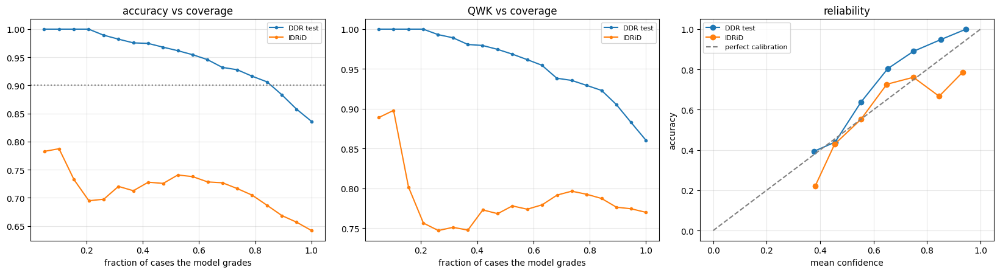


saved -> /kaggle/working/cv_cw/abstention/abstention.json


In [ ]:
# 6.5 Confidence-based abstention

# let the model say "not sure" on hard cases, instead of forcing an answer, and check whether that would actually help in practice.

ABS_DIR = CACHE / 'abstention'; ABS_DIR.mkdir(parents=True, exist_ok=True)

def conf_measures(p):
    srt = np.sort(p, 1)
    return {'max softmax': p.max(1),
            'margin': srt[:, -1] - srt[:, -2],                      
            'neg entropy': (p * np.log(np.clip(p, 1e-12, 1))).sum(1)}  

def coverage_curve(p, y, measure, points=19):
    c = conf_measures(p)[measure]; yh = p.argmax(1)
    order = np.argsort(-c)                                            
    out = []
    for cov in np.linspace(0.05, 1.0, points):
        k = max(2, int(round(cov * len(y))))
        idx = order[:k]
        out.append({'coverage': round(k / len(y), 3), 'n kept': k,
                    'accuracy': (yh[idx] == y[idx]).mean(),
                    'QWK': cohen_kappa_score(y[idx], yh[idx], weights='quadratic')
                            if len(set(y[idx].tolist())) > 1 else np.nan,
                    'conf cut': float(c[order[k - 1]])})
    return pd.DataFrame(out)

print('does confidence separate correct from incorrect? (AUC, 0.5 = no information)')
rows_m = []
for name in ('max softmax', 'margin', 'neg entropy'):
    r = {'measure': name}
    for tag, p_, y_ in [('validation', p_v, y_v), ('DDR test', p_t, y_t), ('IDRiD', p_e, y_e)]:
        c = conf_measures(p_)[name]; correct = (p_.argmax(1) == y_).astype(int)
        r[tag] = roc_auc_score(correct, c)
    rows_m.append(r)
print(pd.DataFrame(rows_m).set_index('measure').round(4).to_string())

MEASURE = 'max softmax'

def ece(p, y, bins=10):
    conf, pred = p.max(1), p.argmax(1); acc = (pred == y).astype(float)
    edges = np.linspace(0, 1, bins + 1); e, rows = 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
            rows.append({'bin': f'{lo:.1f}-{hi:.1f}', 'n': int(m.sum()),
                         'mean conf': conf[m].mean(), 'accuracy': acc[m].mean(),
                         'gap': acc[m].mean() - conf[m].mean()})
    return e, pd.DataFrame(rows)

print('\ncalibration - expected calibration error (0 = confidence matches accuracy):')
for tag, p_, y_ in [('validation', p_v, y_v), ('DDR test', p_t, y_t), ('IDRiD', p_e, y_e)]:
    e, tbl = ece(p_, y_)
    print(f'  {tag:12s} ECE {e:.4f}   mean conf {p_.max(1).mean():.4f}   accuracy {(p_.argmax(1) == y_).mean():.4f}')
_, rel_t = ece(p_t, y_t)
print('\nreliability table, DDR test (gap > 0 = under-confident, < 0 = over-confident):')
print(rel_t.round(4).to_string(index=False))

cc_v = coverage_curve(p_v, y_v, MEASURE)
print('\nvalidation coverage curve (%s):' % MEASURE)
print(cc_v.round(4).to_string(index=False))

TARGET_ACC = 0.90
elig = cc_v[cc_v['accuracy'] >= TARGET_ACC]
ABS_THR = float(elig.iloc[-1]['conf cut']) if len(elig) else float(cc_v.iloc[0]['conf cut'])
print(f'\nabstention threshold: lowest confidence still holding accuracy >= {TARGET_ACC:.2f} '
      f'on validation -> {ABS_THR:.4f}')

def abstain_report(p, y, tag, thr=ABS_THR):
    c = conf_measures(p)[MEASURE]; yh = p.argmax(1); keep = c >= thr
    ref_true, ref_pred = (y >= 2), (p[:, 2:].sum(1) >= THR_REF)
    auto_missed = int((ref_true & ~ref_pred & keep).sum())
    all_missed  = int((ref_true & ~ref_pred).sum())
    return {'set': tag, 'coverage': keep.mean(), 'abstained': int((~keep).sum()),
            'accuracy kept': (yh[keep] == y[keep]).mean() if keep.sum() else np.nan,
            'accuracy abstained': (yh[~keep] == y[~keep]).mean() if (~keep).sum() else np.nan,
            'QWK kept': cohen_kappa_score(y[keep], yh[keep], weights='quadratic') if keep.sum() else np.nan,
            'referable among abstained (%)': 100 * ref_true[~keep].mean() if (~keep).sum() else np.nan,
            'missed refs (auto only)': auto_missed, 'missed refs (all)': all_missed}

print('\nabstention at %.4f, applied unchanged:' % ABS_THR)
print(pd.DataFrame([abstain_report(p_v, y_v, 'validation'),
                    abstain_report(p_t, y_t, 'DDR test'),
                    abstain_report(p_e, y_e, 'IDRiD')]).set_index('set').round(4).to_string())

keep_t = conf_measures(p_t)[MEASURE] >= ABS_THR
per_grade = pd.DataFrame({
    'n': [int((y_t == c).sum()) for c in range(5)],
    'abstained (%)': [100 * (~keep_t)[y_t == c].mean() for c in range(5)],
    'accuracy kept': [(p_t.argmax(1)[keep_t & (y_t == c)] == c).mean()
                      if (keep_t & (y_t == c)).sum() else np.nan for c in range(5)],
    'accuracy abstained': [(p_t.argmax(1)[~keep_t & (y_t == c)] == c).mean()
                           if (~keep_t & (y_t == c)).sum() else np.nan for c in range(5)],
}, index=[LABELS[i] for i in range(5)])
print('\nDDR test, per grade:'); print(per_grade.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
for tag, p_, y_ in [('DDR test', p_t, y_t), ('IDRiD', p_e, y_e)]:
    cc = coverage_curve(p_, y_, MEASURE)
    axes[0].plot(cc['coverage'], cc['accuracy'], marker='.', label=tag)
    axes[1].plot(cc['coverage'], cc['QWK'], marker='.', label=tag)
axes[0].axhline(TARGET_ACC, ls=':', c='grey'); axes[0].set_title('accuracy vs coverage')
axes[1].set_title('QWK vs coverage')
for ax in axes[:2]:
    ax.set_xlabel('fraction of cases the model grades'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
for tag, p_, y_ in [('DDR test', p_t, y_t), ('IDRiD', p_e, y_e)]:
    _, tbl = ece(p_, y_)
    axes[2].plot(tbl['mean conf'], tbl['accuracy'], marker='o', label=tag)
axes[2].plot([0, 1], [0, 1], ls='--', c='grey', label='perfect calibration')
axes[2].set_xlabel('mean confidence'); axes[2].set_ylabel('accuracy')
axes[2].set_title('reliability'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

json.dump({'measure': MEASURE, 'threshold': ABS_THR, 'target_accuracy': TARGET_ACC},
          open(ABS_DIR / 'abstention.json', 'w'), indent=1)
print('\nsaved ->', ABS_DIR / 'abstention.json')

**Result. Abstaining on the least confident 15-24% of cases raises accuracy and clears almost all missed
referrals, on both datasets.**

**Confidence is a useful signal on DDR, much weaker on IDRiD.** Max softmax best separates correct from wrong
answers (AUC 0.834 on DDR test, against 0.5 for no information at all). On IDRiD it drops to 0.637, so
confidence is a weaker guide for deciding what to send to a human there.

**The model is under-confident when right and over-confident when unsure.** Expected calibration error is
0.095 (DDR test) and 0.067 (IDRiD). On DDR test, in the 0.6-0.7 confidence band the model is actually right
80.4% of the time, 15 points more than its own confidence suggests. The 0.3-0.5 range is the opposite, and
close to correct.

**Threshold chosen on validation: 0.55**, the lowest confidence that keeps accuracy at 0.90 or above among
the cases still graded.

| Set | Coverage | Accuracy (kept) | QWK (kept) | Missed referrals (auto) | Missed referrals (before) |
|---|---:|---:|---:|---:|---:|
| validation | 84.2% | 0.904 | 0.918 | 32 | 39 |
| DDR test | 84.7% | 0.904 | 0.921 | **37** | 45 |
| IDRiD | 76.3% | 0.706 | 0.793 | **0** | 1 |

Applying the same threshold to DDR test lifts accuracy from 0.836 to 0.904 on the 84.7% of cases still graded,
and cuts missed referrals from 45 to 37, since the other 8 are now sent to a human instead of guessed wrong.
On IDRiD, the single missed referral becomes 0, but at a much lower accuracy among the cases kept (0.706), so
IDRiD needs a stricter threshold of its own.

**Abstained cases are far more likely to be referable.** 51.4% of DDR abstentions are truly referable, against
44.9% of all cases, so the model is picking out real hard cases, not random ones.

**Mild is where the model is least sure.** 51.1% of true Mild cases are abstained on, against 10.8% for No_DR.
Even so, kept Mild cases are only 41.9% accurate, so uncertainty on Mild is not fully solved by abstaining.

**Saved for later sections**

| File | What it is |
|---|---|
| `abstention.json` | the chosen confidence measure (max softmax), the abstention threshold (0.55), and the target accuracy used to pick it (0.90) |

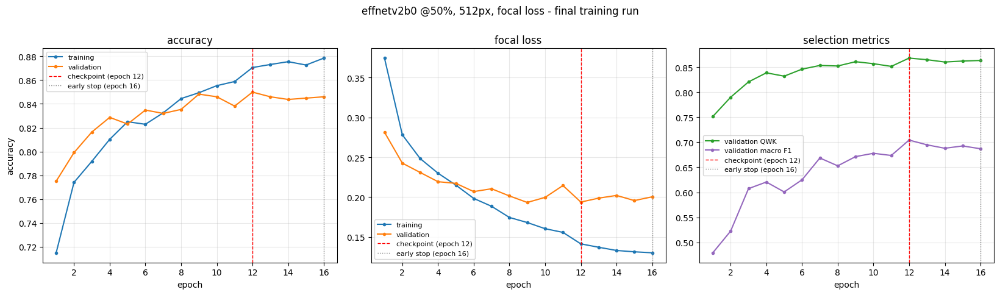

train-validation accuracy gap: -0.0601 at epoch 1, 0.0206 at the checkpoint, 0.0325 at the end
validation loss: min 0.1934 at epoch 9, 0.2004 at the end


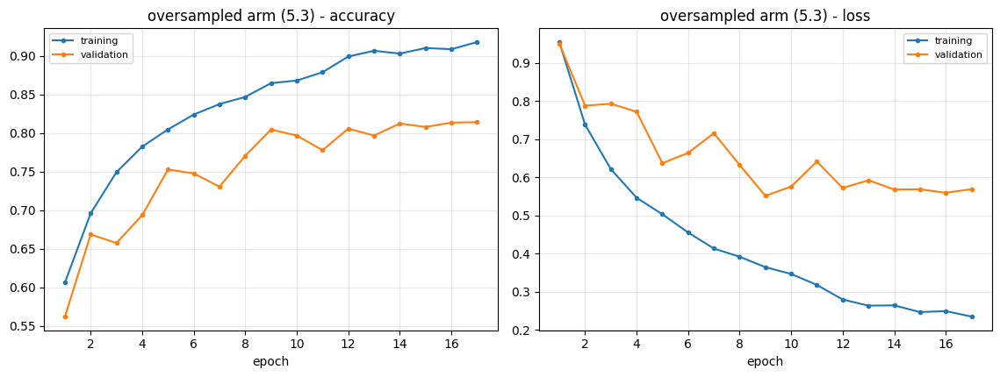

oversampled arm gap: 0.1040 at the end, against 0.0325 for the final model

error distance on the ICDR scale (internal test, 1786 images):
-4 grade     3
-2 grade    83
-1 grade    89
+1 grade    61
+2 grade    53
+3 grade     2
+4 grade     2
total errors 293 (16.4%) | adjacent 51.2% of errors | 2+ grades 48.8% of errors
over-graded 118 | under-graded 175

sight-threatening cases (grades 3-4, n=165): under-graded 36, of which to No_DR/Mild 3

accuracy by grade and capture cohort (the 1.4 confound):
                   mean             size          
source           hyphen timestamp hyphen timestamp
No_DR             0.846     0.974  267.0     626.0
Mild              0.301     0.400   83.0       5.0
Moderate          0.833     0.628  503.0     137.0
Severe            0.481     0.500   27.0       6.0
Proliferative_DR  0.826       NaN  132.0       NaN

overall: hyphen 0.7826 (n=1012) | timestamp 0.9057 (n=774)

the final system, one layer at a time (internal test):
                      

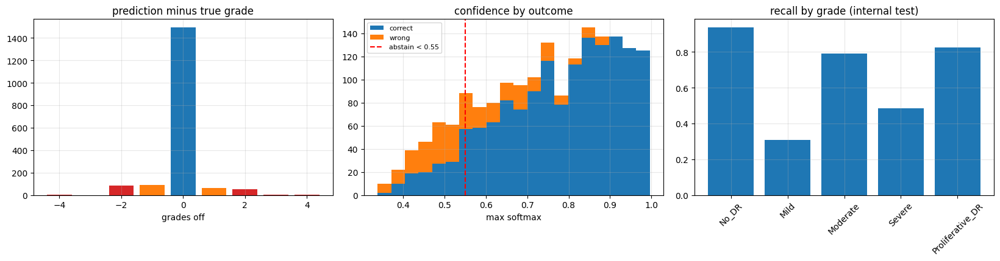

In [ ]:
# 6.6 Error analysis and training behaviour

h_fin = json.load(open(FINAL_DIR / 'final_history.json'))
hf = h_fin[FINAL_TAG]
best_ep = int(np.argmax(hf['val_qwk'])) + 1
n_ep    = len(hf['loss'])

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
ep = range(1, n_ep + 1)
axes[0].plot(ep, hf['accuracy'], marker='.', label='training')
axes[0].plot(ep, hf['val_accuracy'], marker='.', label='validation')
axes[0].set_title('accuracy'); axes[0].set_ylabel('accuracy')
axes[1].plot(ep, hf['loss'], marker='.', label='training')
axes[1].plot(ep, hf['val_loss'], marker='.', label='validation')
axes[1].set_title('focal loss')
axes[2].plot(ep, hf['val_qwk'], marker='.', c='tab:green', label='validation QWK')
axes[2].plot(ep, hf['val_macro_f1'], marker='.', c='tab:purple', label='validation macro F1')
axes[2].set_title('selection metrics')
for ax in axes:
    ax.axvline(best_ep, ls='--', c='red', lw=1, label=f'checkpoint (epoch {best_ep})')
    ax.axvline(n_ep, ls=':', c='grey', lw=1, label=f'early stop (epoch {n_ep})')
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f'{S_BACKBONE} @{S_DEPTH:.0%}, {S_PX}px, focal loss - final training run', y=1.00)
plt.tight_layout(); plt.show()

gap = np.array(hf['accuracy']) - np.array(hf['val_accuracy'])
print('train-validation accuracy gap: %.4f at epoch 1, %.4f at the checkpoint, %.4f at the end'
      % (gap[0], gap[best_ep - 1], gap[-1]))
print('validation loss: min %.4f at epoch %d, %.4f at the end'
      % (min(hf['val_loss']), int(np.argmin(hf['val_loss'])) + 1, hf['val_loss'][-1]))

bal_hist_path = CACHE / 'balancing' / 'balancing_history.json'
if bal_hist_path.exists():
    hb = json.load(open(bal_hist_path)).get('oversampled')
    if hb:
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
        for ax, (k, vk, ttl) in zip(axes, [('accuracy', 'val_accuracy', 'accuracy'),
                                           ('loss', 'val_loss', 'loss')]):
            ax.plot(range(1, len(hb[k]) + 1), hb[k], marker='.', label='training')
            ax.plot(range(1, len(hb[vk]) + 1), hb[vk], marker='.', label='validation')
            ax.set_title(f'oversampled arm (5.3) - {ttl}'); ax.set_xlabel('epoch')
            ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()
        g2 = np.array(hb['accuracy']) - np.array(hb['val_accuracy'])
        print('oversampled arm gap: %.4f at the end, against %.4f for the final model'
              % (g2[-1], gap[-1]))

err = yh_t != y_t
dist = yh_t - y_t
print('\nerror distance on the ICDR scale (internal test, %d images):' % len(y_t))
print(pd.Series(dist[err]).value_counts().sort_index()
        .rename(lambda d: f'{d:+d} grade').to_string())
print('total errors %d (%.1f%%) | adjacent %.1f%% of errors | 2+ grades %.1f%% of errors'
      % (err.sum(), 100 * err.mean(),
         100 * (np.abs(dist[err]) == 1).mean(), 100 * (np.abs(dist[err]) >= 2).mean()))
print('over-graded %d | under-graded %d' % (int((dist > 0).sum()), int((dist < 0).sum())))

sight_threatening = y_t >= 3
print('\nsight-threatening cases (grades 3-4, n=%d): under-graded %d, of which to No_DR/Mild %d'
      % (int(sight_threatening.sum()), int((sight_threatening & (dist < 0)).sum()),
         int((sight_threatening & (yh_t <= 1)).sum())))

te = ddr_te.reset_index(drop=True).copy()
te['correct'] = (yh_t == y_t); te['conf'] = conf_t
coh = te.groupby(['diagnosis', 'source'])['correct'].agg(['mean', 'size']).unstack()
coh.index = [LABELS[i] for i in coh.index]
print('\naccuracy by grade and capture cohort (the 1.4 confound):')
print(coh.round(3).to_string())
print('\noverall: hyphen %.4f (n=%d) | timestamp %.4f (n=%d)'
      % (te[te['source'] == 'hyphen']['correct'].mean(), (te['source'] == 'hyphen').sum(),
         te[te['source'] == 'timestamp']['correct'].mean(), (te['source'] == 'timestamp').sum()))

p_ref_test = p_t[:, 2:].sum(1)
layers = []
for name, kept, refer in [
    ('argmax only',                 np.ones(len(y_t), bool), p_ref_test >= 0.5),
    ('+ referral threshold 0.25',   np.ones(len(y_t), bool), p_ref_test >= THR_REF),
    ('+ abstention 0.55',           conf_t >= ABS_THR,       p_ref_test >= THR_REF)]:
    ref_true = y_t >= 2
    auto_missed = int((ref_true & ~refer & kept).sum())
    layers.append({'configuration': name, 'graded (%)': 100 * kept.mean(),
                   'grading accuracy': (yh_t[kept] == y_t[kept]).mean(),
                   'QWK': cohen_kappa_score(y_t[kept], yh_t[kept], weights='quadratic'),
                   'referral sens': (ref_true & refer).sum() / ref_true.sum(),
                   'referral spec': (~ref_true & ~refer).sum() / (~ref_true).sum(),
                   'silently missed refs': auto_missed})
print('\nthe final system, one layer at a time (internal test):')
print(pd.DataFrame(layers).set_index('configuration').round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
d_counts = pd.Series(dist).value_counts().sort_index()
axes[0].bar(d_counts.index, d_counts.values,
            color=['tab:red' if abs(i) >= 2 else 'tab:orange' if i else 'tab:blue' for i in d_counts.index])
axes[0].set_title('prediction minus true grade'); axes[0].set_xlabel('grades off'); axes[0].grid(alpha=0.3)
axes[1].hist([conf_t[~err], conf_t[err]], bins=20, stacked=True, label=['correct', 'wrong'])
axes[1].axvline(ABS_THR, ls='--', c='red', label=f'abstain < {ABS_THR:.2f}')
axes[1].set_title('confidence by outcome'); axes[1].set_xlabel('max softmax')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
acc_by_grade = [(yh_t[y_t == c] == c).mean() for c in range(5)]
axes[2].bar([LABELS[i] for i in range(5)], acc_by_grade)
axes[2].set_title('recall by grade (internal test)'); axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result. Training was stable, and the final system cuts missed referrals from 129 to 37.**

**Training was healthy, not overfit.** The train-validation accuracy gap is only 0.021 at the checkpoint and
0.033 at the end. The oversampled arm from 5.3, by comparison, ends with a gap of 0.104, three times larger,
which is what memorising the repeated Severe images looks like.

**Most mistakes are close, but under-grading dominates.** Of 1,786 test images, 293 (16.4%) are wrong. 51.2%
of those are only 1 grade off, and 48.8% are 2 or more grades off. The model under-grades (says better than
reality) in 175 cases, against 118 over-graded. Of the 165 sight-threatening cases (Severe or PDR), 36 are
under-graded, but only 3 fall all the way to No_DR or Mild. So the dangerous failure (a serious case looking
completely healthy) is rare.

**Accuracy differs between the two DDR image sources.** Overall, hyphen images score 0.783 and timestamp
images score 0.906. The gap is largest on Moderate (0.833 vs 0.628, in the opposite direction to No_DR).
This does not confirm the model learned the source as a shortcut, since Grad-CAM in 6.3 found no evidence of
that, but it is a real difference and is reported as a limitation.

**The three decision layers, added one at a time (internal test):**

| Layer | Graded | Accuracy | QWK | Referral sensitivity | Missed referrals |
|---|---:|---:|---:|---:|---:|
| argmax only | 100.0% | 0.836 | 0.860 | 0.840 | 129 |
| + referral threshold 0.25 | 100.0% | 0.836 | 0.860 | 0.944 | 45 |
| + abstention 0.55 | 84.7% | 0.904 | 0.921 | 0.944 | 37 |

Each layer is free in the sense that it reuses the same trained model and only changes how its output is
read. Together they take missed referrals from 129 down to 37, while raising accuracy on the cases the model
still grades on its own.

## 6.7 Section 6: Decisions and Conclusion

| Decision | Setting | Reason |
|---|---|---|
| Report the held-out test score, not validation | internal test QWK 0.8603 | Validation was used to pick the checkpoint, so its own score is optimistic (6.1) |
| Retrain `clahe_lab` at the final settings before comparing | QWK 0.8368 vs 0.8682 for `none` | The earlier comparison (4.5) used different settings, so it mixed several changes at once (6.2.0) |
| **Use `none`, not `clahe_lab`** | n/a | Clearly worse at the final settings, especially on rare grades (6.2.0) |
| Report the IDRiD drop honestly | QWK 0.8603 to 0.7698 | Expected from the colour, scale and disease-mix differences found in sections 1-3 (6.2) |
| Check Grad-CAM before trusting the model | inner attention 82.6-99.0% across all cases checked | Confirms the model reads the retina, not the mask edge or background (6.3) |
| **Referral threshold: 0.25**, not the default 0.5 | fitted on validation, 0.95 sensitivity floor | Missed referrals fall from 129 to 45 on test, for more false referrals (44 to 200) (6.4) |
| **Per-class probability weighting rejected** | n/a | Small gains on validation (0.002-0.005 QWK) did not hold on the test set or IDRiD (6.4) |
| **Abstention threshold: 0.55** (max softmax) | fitted on validation, 0.90 accuracy floor | Cuts missed referrals from 45 to 37 on 84.7% of test images, with accuracy 0.904 on the rest (6.5) |

**Final system performance**

| | DDR internal test | IDRiD external |
|---|---|---|
| Grading QWK | 0.860 (0.921 on graded cases) | 0.770 |
| Grading accuracy | 0.836 (0.904 on graded cases) | 0.642 |
| Macro AUC | 0.949 | 0.883 |
| Referral sensitivity @ 0.25 | 0.944 | 0.997 |
| Referral specificity @ 0.25 | 0.796 | 0.546 |
| Silently missed referrals | 37 of 805 | 0 of 313 |

**Training was healthy, not overfit.** The train-validation gap is 0.033 at the end, against 0.104 for the
oversampled arm from 5.3, which had memorised the repeated Severe images.

**The section 1.4 shortcut risk did not become a real shortcut.** Checked three ways: per-grade accuracy is
about equal between the two DDR sources on Severe (0.481 vs 0.500), Grad-CAM attention stays inside the
retina, and the IDRiD drop matches what was predicted from real dataset differences, not from a hidden cue.

**Limitations to carry into the report**

1. **IDRiD needs its own threshold.** The 0.25 referral threshold, fitted on DDR, over-refers on IDRiD
   (specificity 0.546, most images referred). The 0.55 abstention threshold has the same problem: accuracy on
   graded IDRiD cases is only 0.706, well under the 0.90 target it was fitted to.
2. **Accuracy still differs between the two DDR sources** (0.783 vs 0.906 overall), even though it is not a
   confirmed shortcut. Moderate and No_DR move in opposite directions between sources.
3. **Mild remains the hardest grade.** 51% of true Mild cases are abstained on, and even the kept ones are
   only 41.9% accurate. Its errors are genuine overlap with neighbouring grades, not a fixable threshold.
4. **All operating points (0.25, 0.55) were fitted once on a single validation set**, not cross-validated.